# TextBlob Polarity Algorithm — From-Scratch Implementation
## CMU-MOSI Transcript Sentiment Analyser with Word-Level Colour Highlighting

> **Goal:** Re-implement the complete TextBlob polarity/subjectivity scoring
> algorithm from first principles — XML lexicon loading, whitespace-preserving
> tokenisation, modifier detection (negators + intensifiers), per-token adjusted
> scoring, and mean-aggregation — then apply it to **five real CMU-MOSI film-review
> transcripts**, displaying the entire text with every sentiment-bearing word
> colour-highlighted by its contribution.

**Notebook layout:**
- Every *markdown cell* states the **mathematical foundation** (Axioms, Definitions,
  Lemmas, Theorems) that the immediately following *code cell* implements precisely.
- Colour key: 🟢 greens = positive polarity · 🔴 reds = negative polarity ·
  opacity ∝ subjectivity strength · hover any highlighted word for exact scores.


---
# Part A — Multimodal Feature Extraction and Analysis
## Audio · Video · Image · Text Features for Positive/Negative Sentiment Classification

> **Goal of Part A:** Given 3 positive and 3 negative CMU-MOSI video review samples,
> extract an explicit, comprehensive set of audio, video/image, and text features,
> apply feature selection and visualization techniques documented in the attached TeX files,
> produce quantitative metrics and visualisations, and use an open-source LLM (running locally
> or in Colab with no API key) to explain feature importance.

### Dataset Setup

| Sample ID | File | Class Label |
|:--|:--|:--|
| P1 | `6Egk_28TtTM` | Positive (Mars Needs Moms — enthusiastic child reviewer) |
| P2 | `ZUXBRvtny7o` | Positive (I Am Number Four — enjoyed, 3/5 stars) |
| P3 | `2iD-tVS8NPw` (embedded) | Positive (Green Lantern — had fun) |
| N1 | `etzxEpPuc6I` | Negative (GI Joe — terrible acting/plot) |
| N2 | `d6hH302o4v8` | Negative (review with negative content) |
| N3 | `1DmNV9C1hbY` (embedded) | Negative (Chipmunks 2 — bored, flat) |

> **Assumption:** When full dataset is available, all samples are in a folder `./data/`
> with sub-folders `audio/`, `frames/`, `text/`. The code below reads the provided
> 6 samples and is structured to scale to any number of files.

### Folder layout (all samples in one directory)\n\nPlace files under `DATA_DIR` (default `./data` or set env `MULTIMODAL_DATA_DIR`):\n
- **Flat layout:** `DATA_DIR/<clip_id>.wav`, `.mp4`, `.textonly`
- **Structured:** `DATA_DIR/audio/`, `DATA_DIR/video/`, `DATA_DIR/text/` with the same `<clip_id>` stems
- **Labels (required for auto-discovered clips):** `samples_manifest.csv` with columns `sample_id,label,film` or `labels.json` mapping clip id to `0`/`1`.\n

---
## § A.1  Setup, Imports, and Dataset Paths

### Axiom A.1 (Dataset Structure)
Let $\mathcal{D} = \{(x_i^{(a)}, x_i^{(v)}, x_i^{(t)}, y_i)\}_{i=1}^{N}$ where
$x_i^{(a)} \in \mathbb{R}^{T_a}$ is the raw audio waveform, $x_i^{(v)}$ is the video/frames,
$x_i^{(t)}$ is the transcript, and $y_i \in \{0,1\}$ is the binary sentiment label
(0 = negative, 1 = positive). Here $N=6$ (3 positive + 3 negative).

### Definition A.1 (Feature Extraction Function)
A feature extractor $\Phi: \mathcal{D} \to \mathbb{R}^d$ maps each sample to a
$d$-dimensional numeric descriptor. We define separate extractors:
$$\Phi^{(a)}: \mathbb{R}^{T_a} \to \mathbb{R}^{d_a}, \quad
\Phi^{(v)}: \text{Frames} \to \mathbb{R}^{d_v}, \quad
\Phi^{(t)}: \Sigma^* \to \mathbb{R}^{d_t}$$

The full feature vector is $\Phi = [\Phi^{(a)} \| \Phi^{(v)} \| \Phi^{(t)}] \in \mathbb{R}^{d_a+d_v+d_t}$.

In the following code cell, we install required packages and define all paths.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════
#  PART A — CELL A1: Setup, Imports, Dataset Paths
#  Implements: Axiom A.1, Definition A.1
# ═══════════════════════════════════════════════════════════════════════
import subprocess, sys, warnings, os, re, math, glob, json as _json
warnings.filterwarnings('ignore')

# Install / upgrade packages (Google Colab / Kaggle compatible)
_pkgs = ['librosa', 'pywavelets', 'textblob', 'nltk',
         'seaborn', 'scikit-learn', 'scipy', 'Pillow',
         'matplotlib', 'numpy', 'pandas', 'opencv-python-headless']
for _p in _pkgs:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', _p],
                   capture_output=True)

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import defaultdict, OrderedDict
import soundfile as sf
import librosa
import librosa.display
import pywt
from scipy import signal, stats
from scipy.stats import skew, kurtosis
import xml.etree.ElementTree as ET
from IPython.display import display, HTML, Image
import base64, io, cv2
from PIL import Image as PILImage
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.feature_selection import (
    mutual_info_classif, f_classif, chi2, SelectKBest, VarianceThreshold
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression, Lasso
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline

# ── Dataset root (folder containing samples or sub-folders audio/, video/, text/) ──
DATA_DIR = os.environ.get('MULTIMODAL_DATA_DIR', os.path.join(os.getcwd(), 'data'))
DATA_DIR = os.path.abspath(DATA_DIR)

def _resolve_modal_dirs(root):
    """If ./audio, ./video, ./text exist under root, use them; else flat layout in root."""
    root = os.path.abspath(root)
    a, v, t = os.path.join(root, 'audio'), os.path.join(root, 'video'), os.path.join(root, 'text')
    if os.path.isdir(a) and os.path.isdir(v) and os.path.isdir(t):
        return a, v, t, os.path.join(root, 'frames')
    return root, root, root, os.path.join(root, 'frames')

AUDIO_DIR, VIDEO_DIR, TEXT_DIR, FRAMES_DIR = _resolve_modal_dirs(DATA_DIR)
os.makedirs(FRAMES_DIR, exist_ok=True)

# Known labels for the CMU-MOSI-style clip IDs used in this notebook (fallback when no manifest)
DEFAULT_LABELS_BY_ID = {
    '6Egk_28TtTM': 1, 'ZUXBRvtny7o': 1, '2iD-tVS8NPw': 1,
    'etzxEpPuc6I': 0, 'd6hH302o4v8': 0, '1DmNV9C1hbY': 0,
}

# Embedded texts for samples without .textonly files
EMBEDDED_TEXTS = {
    '2iD-tVS8NPw': (
        "hey welcome to stuffwelikecom video review of the Green Lantern "
        "I enjoyed this movie I enjoyed it for what it was you know its a huge sort of spectacle movie "
        "that is great for this summer time it looks really good and I just had fun watching this movie "
        "its very much a light hearted so its perfect for kids its perfect for teenagers too "
        "the thing about this movie is that the entire movie is about building up towards this ultimate "
        "battle and it does look good and I think I want to see the sequel I enjoyed it"
    ),
    '1DmNV9C1hbY': (
        "hey everyone welcome to Toppers movie review so I went and saw Alvin and the chipmunks 2 "
        "I loved the very first Alvin and the chipmunks movie but for this one I just didnt care "
        "I saw no reason why they needed to bring back the villain from the first one "
        "while the trailer made the film look real nice and cute it was just flat "
        "I was just a little bored there were cute moments but otherwise I didnt even care for it "
    ),
}

def _load_labels_json(root):
    for name in ('labels.json', 'sample_labels.json'):
        p = os.path.join(root, name)
        if os.path.isfile(p):
            with open(p) as f:
                d = _json.load(f)
            out = {}
            for k, v in d.items():
                if isinstance(v, bool):
                    out[k] = int(v)
                elif isinstance(v, str) and v.lower() in ('pos', 'positive', '1'):
                    out[k] = 1
                elif isinstance(v, str) and v.lower() in ('neg', 'negative', '0'):
                    out[k] = 0
                else:
                    out[k] = int(v)
            return out
    return {}

def _discover_sample_ids(root):
    """Union of clip IDs found from .wav, .mp4, .textonly in audio/video/text dirs."""
    ad, vd, td, _ = _resolve_modal_dirs(root)
    ids = set()
    for folder, pat in ((ad, '*.wav'), (vd, '*.mp4'), (td, '*.textonly')):
        for p in glob.glob(os.path.join(folder, pat)):
            ids.add(os.path.splitext(os.path.basename(p))[0])
    ids |= set(EMBEDDED_TEXTS.keys())
    return sorted(ids)

def build_sample_registry(root):
    """
    Priority:
      1) samples_manifest.csv in DATA_DIR with columns: sample_id,label,film (film optional)
      2) Auto-scan + labels.json / DEFAULT_LABELS_BY_ID
      3) Hard-coded 6-sample registry (original notebook) if folder is empty
    """
    manifest = os.path.join(root, 'samples_manifest.csv')
    if os.path.isfile(manifest):
        df = pd.read_csv(manifest)
        if 'sample_id' not in df.columns or 'label' not in df.columns:
            raise ValueError('samples_manifest.csv must include columns: sample_id, label (and optional film)')
        reg = OrderedDict()
        for _, row in df.iterrows():
            sid = str(row['sample_id']).strip()
            lab = row['label']
            if isinstance(lab, str):
                lab = 1 if lab.strip().lower() in ('1', 'pos', 'positive') else 0
            else:
                lab = int(lab)
            film = str(row['film']).strip() if 'film' in df.columns and pd.notna(row.get('film')) else sid
            key = sid
            reg[key] = {'id': sid, 'label': lab, 'film': film}
        return reg

    ids = _discover_sample_ids(root)
    labels_file = _load_labels_json(root)
    if ids:
        reg = OrderedDict()
        for sid in ids:
            lab = labels_file.get(sid, DEFAULT_LABELS_BY_ID.get(sid, None))
            if lab is None:
                lab = 1
                print(f"  [warn] No label for '{sid}' in labels.json — defaulting to POSITIVE (1). "
                      f"Add samples_manifest.csv or labels.json to set 0/1.")
            reg[sid] = {'id': sid, 'label': int(lab), 'film': sid}
        return reg

    # Fallback: original fixed registry (6 clips)
    return OrderedDict([
        ('P1', {'id': '6Egk_28TtTM',  'label': 1, 'film': 'Mars Needs Moms'}),
        ('P2', {'id': 'ZUXBRvtny7o',  'label': 1, 'film': 'I Am Number Four'}),
        ('P3', {'id': '2iD-tVS8NPw',  'label': 1, 'film': 'Green Lantern'}),
        ('N1', {'id': 'etzxEpPuc6I',  'label': 0, 'film': 'GI Joe'}),
        ('N2', {'id': 'd6hH302o4v8',  'label': 0, 'film': 'Unknown (negative)'}),
        ('N3', {'id': '1DmNV9C1hbY',  'label': 0, 'film': 'Alvin & Chipmunks 2'}),
    ])

SAMPLES = build_sample_registry(DATA_DIR)

def path_wav(sample_key):
    info = SAMPLES[sample_key]
    cid = info['id']
    p = os.path.join(AUDIO_DIR, f'{cid}.wav')
    return p if os.path.isfile(p) else os.path.join(DATA_DIR, f'{cid}.wav')

def path_mp4(sample_key):
    info = SAMPLES[sample_key]
    cid = info['id']
    p = os.path.join(VIDEO_DIR, f'{cid}.mp4')
    return p if os.path.isfile(p) else os.path.join(DATA_DIR, f'{cid}.mp4')

def path_textonly(sample_key):
    info = SAMPLES[sample_key]
    cid = info['id']
    p = os.path.join(TEXT_DIR, f'{cid}.textonly')
    return p if os.path.isfile(p) else os.path.join(DATA_DIR, f'{cid}.textonly')

print(f"DATA_DIR={DATA_DIR}")
print(f"  audio:  {AUDIO_DIR}\n  video:  {VIDEO_DIR}\n  text:   {TEXT_DIR}")
print("Sample registry:")
for sid, info in SAMPLES.items():
    wav_path, mp4_path, tx_path = path_wav(sid), path_mp4(sid), path_textonly(sid)
    has_wav  = os.path.isfile(wav_path)
    has_mp4  = os.path.isfile(mp4_path)
    has_text = os.path.isfile(tx_path) or info['id'] in EMBEDDED_TEXTS
    label_str = 'POS' if info['label'] == 1 else 'NEG'
    print(f"  {sid} ({label_str}) | {info['id']:20s} | {str(info['film'])[:30]:30s} | "
          f"wav={'Y' if has_wav else 'N'} mp4={'Y' if has_mp4 else 'N'} txt={'Y' if has_text else 'N'}")

n_pos = sum(v['label'] == 1 for v in SAMPLES.values())
n_neg = sum(v['label'] == 0 for v in SAMPLES.values())
print(f"\nSetup complete. {n_pos} positive, {n_neg} negative samples (N={len(SAMPLES)}).")


---
## § A.2  Audio Feature Extraction

### Mathematical Foundations

Let $x[n] \in \mathbb{R},\; n=0,\ldots,N-1$ be the discrete audio waveform at sampling rate $f_s$.

#### A.2.1 Time-Domain Features

**Definition A.2.1 (Zero Crossing Rate, Rabiner & Schafer 1978):**
$$\mathrm{ZCR}(x) = \frac{1}{N-1}\sum_{n=1}^{N-1}\mathbf{1}(x[n]\cdot x[n-1] < 0)$$

**Definition A.2.2 (Root Mean Square Energy):**
$$\mathrm{RMS}(x) = \sqrt{\frac{1}{N}\sum_{n=0}^{N-1} x[n]^2}$$

**Definition A.2.3 (Statistical Moments, Pearson 1895):**
$$\mu = \frac{1}{N}\sum x[n], \quad \sigma^2 = \frac{1}{N}\sum(x[n]-\mu)^2,$$
$$\mathrm{Skew} = \frac{\mathbb{E}[(x-\mu)^3]}{\sigma^3}, \quad \mathrm{Kurt} = \frac{\mathbb{E}[(x-\mu)^4]}{\sigma^4}$$

#### A.2.2 Frequency-Domain Features

**Definition A.2.4 (Discrete Fourier Transform, Cooley & Tukey 1965):**
$$X[k] = \sum_{n=0}^{N-1} x[n]\, e^{-j2\pi kn/N}, \quad P[k] = |X[k]|^2$$

**Definition A.2.5 (Spectral Centroid, Peeters 2004):**
$$C = \frac{\sum_k f_k P[k]}{\sum_k P[k]}, \quad f_k = \frac{k f_s}{N}$$

**Definition A.2.6 (Spectral Bandwidth):**
$$B = \sqrt{\frac{\sum_k (f_k - C)^2 P[k]}{\sum_k P[k]}}$$

**Definition A.2.7 (Spectral Rolloff, Tzanetakis & Cook 2002):** $f_{\mathrm{roll}}$ s.t.
$$\sum_{k: f_k \le f_{\mathrm{roll}}} P[k] \ge \alpha \sum_k P[k], \quad \alpha = 0.85$$

**Definition A.2.8 (Spectral Flatness / Wiener Entropy):**
$$\mathrm{SF} = \frac{\exp\!\left(\frac{1}{N}\sum_k \ln P[k]\right)}{\frac{1}{N}\sum_k P[k]}$$

#### A.2.3 Cepstral Features

**Definition A.2.9 (MFCC Pipeline, Davis & Mermelstein 1980):**
Let $H_m[k]$ be triangular mel filterbank responses, $M$ filters. Then:
$$E_m = \sum_k P[k]H_m[k], \quad L_m = \log(E_m+\epsilon),$$
$$c_n = \sum_{m=0}^{M-1} L_m \cos\!\left(\frac{\pi n}{M}\left(m+\tfrac{1}{2}\right)\right), \quad n=0,\ldots,L-1$$

Delta: $\Delta c_n[t] = c_n[t] - c_n[t-1]$; Delta-Delta: $\Delta^2 c_n[t] = \Delta c_n[t] - \Delta c_n[t-1]$.

#### A.2.4 Entropy & Complexity Features

**Definition A.2.10 (Approximate Entropy, Pincus 1991):**
Embed $x[n]$ into $m$-vectors $\mathbf{u}_i$, let $C_i^m(r) = \frac{|\{j:\|\mathbf{u}_i-\mathbf{u}_j\|_\infty \le r\}|}{N-m+1}$,
$\phi^m(r) = \frac{1}{N-m+1}\sum_i \ln C_i^m(r)$. Then
$$\mathrm{ApEn}(m,r) = \phi^m(r) - \phi^{m+1}(r)$$

**Definition A.2.11 (Shannon Information Entropy, Shannon 1948):**
$$H = -\sum_k p_k \log_2 p_k \quad \text{(over empirical symbol probabilities)}$$

**Definition A.2.12 (Wavelet Multi-scale Features, Daubechies 1988):**
Apply DWT (db3, level 5); for each band $b$: compute mean, std, power, skew, kurtosis, ApEn.

#### A.2.5 Pitch & Voice Quality

**Definition A.2.13 (Pitch via Autocorrelation, Rabiner 1977):**
$$R(\tau) = \frac{1}{N-\tau}\sum_{n=0}^{N-1-\tau}x[n]x[n+\tau], \quad F_0 = f_s/\tau_0$$

**Lemma A.2.1 (Feature Discriminability):**
For sentiment classification, prosodic features (pitch, RMS energy, speech rate)
are most discriminative between positive/negative affect
because emotional valence correlates strongly with vocal effort and pitch variation.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════
#  PART A — CELL A2: Audio Feature Extraction
#  Implements: Definitions A.2.1 through A.2.13, Lemma A.2.1
# ═══════════════════════════════════════════════════════════════════════

def approx_entropy(x, m=2, r_frac=0.2):
    """Approximate Entropy (Pincus 1991) — Definition A.2.10"""
    N = len(x)
    if N < m + 2:
        return 0.0
    r = r_frac * np.std(x, ddof=0) + 1e-9
    def _phi(m_):
        templates = np.array([x[i:i+m_] for i in range(N-m_+1)])
        count = np.sum(
            np.max(np.abs(templates[:,None,:] - templates[None,:,:]), axis=2) <= r,
            axis=1)
        count = np.maximum(count, 1)
        return np.mean(np.log(count / (N - m_ + 1)))
    return _phi(m) - _phi(m+1)

def info_entropy(x, match=4):
    """Shannon Information Entropy over symbolic differences — Def A.2.11"""
    if len(x) < 2:
        return 0.0
    z = (x - x.mean()) / (x.std() + 1e-9)
    dz = np.diff(z)
    sd = dz.std() + 1e-9
    # Quantize differences into 4 symbols
    sym = np.where(dz > sd, 3, np.where(dz > 0, 2, np.where(dz > -sd, 1, 0)))
    patterns = defaultdict(int)
    for i in range(len(sym)-match+1):
        patterns[tuple(sym[i:i+match])] += 1
    total = sum(patterns.values())
    if total == 0:
        return 0.0
    probs = np.array(list(patterns.values())) / total
    return -np.sum(probs * np.log2(probs + 1e-9))

def stat_features(arr, prefix=''):
    """14-D statistical feature vector (Definition A.2.3 + notebook convention)"""
    if len(arr) < 2:
        return {f'{prefix}me':0, f'{prefix}std':0, f'{prefix}sk':0, f'{prefix}ku':0,
                f'{prefix}rms':0, f'{prefix}me1df':0, f'{prefix}me2df':0, f'{prefix}energy':0,
                f'{prefix}entropy':0, f'{prefix}maxval':0, f'{prefix}minval':0,
                f'{prefix}apen':0, f'{prefix}inen':0, f'{prefix}zcr':0}
    d1 = np.diff(arr)
    d2 = np.diff(d1) if len(d1) > 1 else np.array([0])
    hist, _ = np.histogram(arr, bins=min(50, len(arr)//2+1), density=True)
    hist = hist + 1e-12
    hist /= hist.sum()
    feat = {
        f'{prefix}me':    float(np.mean(arr)),
        f'{prefix}std':   float(np.std(arr, ddof=0)),
        f'{prefix}sk':    float(skew(arr)),
        f'{prefix}ku':    float(kurtosis(arr)),
        f'{prefix}rms':   float(np.sqrt(np.mean(arr**2))),
        f'{prefix}me1df': float(np.mean(np.abs(d1))),
        f'{prefix}me2df': float(np.mean(np.abs(d2))),
        f'{prefix}energy':float(np.sum(arr**2)),
        f'{prefix}entropy': float(-np.sum(hist * np.log2(hist + 1e-9))),
        f'{prefix}maxval': float(np.max(arr)),
        f'{prefix}minval': float(np.min(arr)),
        f'{prefix}apen':  float(approx_entropy(arr[:500])),
        f'{prefix}inen':  float(info_entropy(arr[:500])),
        f'{prefix}zcr':   float(np.mean(np.diff(np.sign(arr)) != 0)),
    }
    return feat

def extract_audio_features(wav_path, sr_target=11025, max_dur=60.0):
    """
    Extracts all audio features from the TeX files:
    - Time-domain statistics (Defs A.2.1, A.2.2, A.2.3)
    - Frequency-domain (Defs A.2.4–A.2.8)
    - MFCC + delta + delta-delta (Def A.2.9)
    - Entropy features (Defs A.2.10–A.2.11)
    - Wavelet multi-scale (Def A.2.12)
    - Pitch / F0 (Def A.2.13)
    Returns dict of feature_name -> scalar value
    """
    y, sr = sf.read(wav_path, always_2d=True)
    y = y.mean(axis=1)  # mono
    max_samp = int(max_dur * sr)
    y = y[:max_samp]
    # Resample if needed
    if sr != sr_target:
        n_new = int(len(y) * sr_target / sr)
        y = signal.resample(y, n_new)
        sr = sr_target

    feats = {}

    # ── Time-domain stats (Def A.2.1–A.2.3) ──
    feats.update(stat_features(y, 'td_'))

    # ZCR per-frame (Def A.2.1)
    frame_len = 2048
    hop = 512
    zcr_frames = librosa.feature.zero_crossing_rate(y, frame_length=frame_len, hop_length=hop)[0]
    feats['zcr_mean']  = float(np.mean(zcr_frames))
    feats['zcr_std']   = float(np.std(zcr_frames))

    # RMS energy per-frame (Def A.2.2)
    rms_frames = librosa.feature.rms(y=y, frame_length=frame_len, hop_length=hop)[0]
    feats['rms_mean']  = float(np.mean(rms_frames))
    feats['rms_std']   = float(np.std(rms_frames))
    feats['rms_max']   = float(np.max(rms_frames))
    feats['rms_dyn']   = float(np.max(rms_frames) - np.min(rms_frames))  # dynamic range

    # ── Frequency domain (Def A.2.4–A.2.8) ──
    D = np.abs(librosa.stft(y, n_fft=2048, hop_length=hop))
    freqs = librosa.fft_frequencies(sr=sr, n_fft=2048)

    # Spectral centroid (Def A.2.5)
    sc = librosa.feature.spectral_centroid(S=D, sr=sr)[0]
    feats['spec_centroid_mean'] = float(np.mean(sc))
    feats['spec_centroid_std']  = float(np.std(sc))

    # Spectral bandwidth (Def A.2.6)
    sb = librosa.feature.spectral_bandwidth(S=D, sr=sr)[0]
    feats['spec_bw_mean'] = float(np.mean(sb))
    feats['spec_bw_std']  = float(np.std(sb))

    # Spectral rolloff (Def A.2.7)
    sr_ = librosa.feature.spectral_rolloff(S=D, sr=sr, roll_percent=0.85)[0]
    feats['spec_rolloff_mean'] = float(np.mean(sr_))
    feats['spec_rolloff_std']  = float(np.std(sr_))

    # Spectral flatness (Def A.2.8)
    sf_ = librosa.feature.spectral_flatness(S=D)[0]
    feats['spec_flatness_mean'] = float(np.mean(sf_))
    feats['spec_flatness_std']  = float(np.std(sf_))

    # Spectral contrast
    sc2 = librosa.feature.spectral_contrast(S=D, sr=sr)
    for b in range(sc2.shape[0]):
        feats[f'spec_contrast_band{b}'] = float(np.mean(sc2[b]))

    # ── MFCC (Def A.2.9) ──
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    d_mfcc  = librosa.feature.delta(mfcc)
    dd_mfcc = librosa.feature.delta(mfcc, order=2)
    for k in range(13):
        feats[f'mfcc{k}_mean'] = float(np.mean(mfcc[k]))
        feats[f'mfcc{k}_std']  = float(np.std(mfcc[k]))
        feats[f'dmfcc{k}_mean']= float(np.mean(d_mfcc[k]))
        feats[f'ddmfcc{k}_mean']=float(np.mean(dd_mfcc[k]))

    # ── Chroma (Harte et al. 2005) ──
    chroma = librosa.feature.chroma_stft(S=D**2, sr=sr, n_fft=2048)
    for k in range(12):
        feats[f'chroma{k}_mean'] = float(np.mean(chroma[k]))

    # ── Tonnetz ──
    try:
        tonnetz = librosa.feature.tonnetz(y=librosa.effects.harmonic(y), sr=sr)
        for k in range(tonnetz.shape[0]):
            feats[f'tonnetz{k}_mean'] = float(np.mean(tonnetz[k]))
    except:
        for k in range(6):
            feats[f'tonnetz{k}_mean'] = 0.0

    # ── Mel spectrogram statistics ──
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=40)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    feats['mel_mean'] = float(np.mean(mel_db))
    feats['mel_std']  = float(np.std(mel_db))
    feats['mel_skew'] = float(skew(mel_db.ravel()))
    feats['mel_kurt'] = float(kurtosis(mel_db.ravel()))

    # ── Wavelet multi-scale (Def A.2.12) ──
    try:
        coeffs = pywt.wavedec(y[:8192], 'db3', level=5)
        band_names = ['approx'] + [f'det{i}' for i in range(1, 6)]
        for bname, coeff in zip(band_names, coeffs):
            feats[f'dwt_{bname}_mean'] = float(np.mean(np.abs(coeff)))
            feats[f'dwt_{bname}_std']  = float(np.std(coeff))
            feats[f'dwt_{bname}_pwr']  = float(np.mean(coeff**2))
            feats[f'dwt_{bname}_sk']   = float(skew(coeff))
            feats[f'dwt_{bname}_ku']   = float(kurtosis(coeff))
            feats[f'dwt_{bname}_apen'] = float(approx_entropy(coeff[:200]))
            feats[f'dwt_{bname}_inen'] = float(info_entropy(coeff[:200]))
    except:
        pass

    # ── Approximate entropy + Info entropy (Defs A.2.10–A.2.11) ──
    feats['apen_raw']  = float(approx_entropy(y[:1000]))
    feats['inen_raw']  = float(info_entropy(y[:1000]))

    # ── Pitch / F0 (Def A.2.13) ──
    try:
        f0, voiced_flag, _ = librosa.pyin(y, fmin=50, fmax=500,
                                           frame_length=2048, hop_length=hop)
        voiced_f0 = f0[voiced_flag] if voiced_flag.any() else np.array([0.0])
        feats['f0_mean']   = float(np.nanmean(voiced_f0)) if len(voiced_f0) > 0 else 0.0
        feats['f0_std']    = float(np.nanstd(voiced_f0))  if len(voiced_f0) > 0 else 0.0
        feats['f0_range']  = float(np.nanmax(voiced_f0) - np.nanmin(voiced_f0)) if len(voiced_f0) > 0 else 0.0
        feats['voiced_frac'] = float(np.mean(voiced_flag.astype(float)))
    except:
        feats['f0_mean'] = feats['f0_std'] = feats['f0_range'] = feats['voiced_frac'] = 0.0

    # ── HNR proxy (energy ratio voiced vs unvoiced) ──
    feats['hnr_proxy'] = feats['f0_mean'] / (feats['rms_mean'] * 1e3 + 1e-6)

    # ── Speech rate proxy: ZCR-based ──
    feats['speech_rate_proxy'] = feats['zcr_mean'] * sr / 2.0

    return feats

# ── Extract audio features for all samples ────────────────────────────
print("Extracting audio features...")
audio_features = {}
for sid, info in SAMPLES.items():
    wav_path = path_wav(sid)
    if os.path.exists(wav_path):
        try:
            feats = extract_audio_features(wav_path)
            audio_features[sid] = feats
            print(f"  {sid} ({str(info['film'])[:20]}) — {len(feats)} audio features extracted OK")
        except Exception as e:
            print(f"  {sid} — ERROR: {e}")
    else:
        print(f"  {sid} — No .wav file found (will use zeros)")
        audio_features[sid] = {}

# ── Explicit ordered list of AUDIO feature names (schema from a short synthetic clip) ──
import tempfile
def _explicit_audio_feature_names():
    sr = 11025
    n = int(sr * 0.6)
    t = np.linspace(0, 0.6, n, endpoint=False)
    y = 0.03 * np.sin(2 * np.pi * 180 * t) + 0.01 * np.random.randn(n)
    fd, tmp = tempfile.mkstemp(suffix='.wav')
    os.close(fd)
    try:
        sf.write(tmp, y, sr)
        return sorted(extract_audio_features(tmp).keys())
    finally:
        if os.path.isfile(tmp):
            os.remove(tmp)

AUDIO_FEATURE_NAMES = _explicit_audio_feature_names()
print(f"\nExplicit AUDIO feature count: {len(AUDIO_FEATURE_NAMES)} (see AUDIO_FEATURE_NAMES)")

# Consolidate into a DataFrame
all_audio_keys = sorted(set(k for f in audio_features.values() for k in f.keys()))
audio_df = pd.DataFrame(
    {sid: [audio_features[sid].get(k, 0.0) for k in all_audio_keys]
     for sid in SAMPLES.keys()},
    index=all_audio_keys
).T
audio_df['label'] = [SAMPLES[s]['label'] for s in audio_df.index]
audio_df['film']  = [SAMPLES[s]['film']  for s in audio_df.index]

print(f"\nAudio feature matrix: {audio_df.shape[0]} samples × {audio_df.shape[1]-2} features")
print(audio_df[['film','label']].to_string())


---
## § A.3  Text Feature Extraction

### Mathematical Foundations

Let $D = (w_1, w_2, \ldots, w_N)$ be a document (transcript) with vocabulary $V$.

#### A.3.1 Lexical Features (Salton 1970s, Spärck Jones 1972)

**Definition A.3.1 (TF-IDF):**
$$\mathrm{TF}(t,D) = \sum_i \mathbf{1}[w_i=t], \quad \mathrm{IDF}(t) = \log\frac{M}{1+\mathrm{DF}(t)}$$
$$\mathrm{TFIDF}(t,D) = \mathrm{TF}(t,D) \cdot \mathrm{IDF}(t)$$

**Definition A.3.2 (Type-Token Ratio, TTR):**
$$\mathrm{TTR}(D) = \frac{|V(D)|}{N}, \quad C(D) = \frac{\log|V(D)|}{\log N} \text{ (Herdan's C)}$$

**Definition A.3.3 (Yule's K):**
$$K(D) = 10^4 \cdot \frac{\sum_m m^2 V_m - N}{N^2}$$
where $V_m$ = number of words occurring exactly $m$ times.

#### A.3.2 TextBlob Sentiment Features (Theorem 3.1 from original notebook)

$$\tilde{p}(w_i) = \mu(i) \cdot (-1)^{\delta(i)} \cdot \bar{p}(w_i'), \quad
\tilde{s}(w_i) = \bar{s}(w_i')$$
$$P(D) = \frac{1}{|\mathcal{S}|}\sum_{i\in\mathcal{S}}\tilde{p}(w_i), \quad
Q(D) = \frac{1}{|\mathcal{S}|}\sum_{i\in\mathcal{S}}\tilde{s}(w_i)$$

#### A.3.3 Structural & Syntactic Features

**Definition A.3.4 (Average Sentence Length):**
$$\mathrm{AvgSentLen}(D) = \frac{1}{n_s}\sum_{j=1}^{n_s}|S_j|$$

**Definition A.3.5 (Readability — Flesch RE, Flesch 1948):**
$$\mathrm{FRE}(D) = 206.835 - 1.015 \cdot \frac{N}{n_s} - 84.6 \cdot \frac{\mathrm{Syllables}(D)}{N}$$

#### A.3.4 Entropy of Text

**Definition A.3.6 (Token Distribution Entropy):**
$$H_{\mathrm{text}}(D) = -\sum_{w\in V(D)} p(w)\log_2 p(w), \quad p(w) = \mathrm{TF}(w,D)/N$$

**Lemma A.3.1 (Discriminability of Sentiment Features):**
Polarity $P(D)$ and subjectivity $Q(D)$ are the most discriminative text features
for binary sentiment classification when combined with negation and intensifier detection
(Theorem 3.1 from the original notebook), because:
1. Positive reviews tend to $P(D) > 0$ and high $Q(D)$;
2. Negative reviews tend to $P(D) \leq 0$ with high negativity words.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════
#  PART A — CELL A3: Text Feature Extraction
#  Implements: Definitions A.3.1 through A.3.6, Lemma A.3.1
#  Re-uses the from-scratch TextBlob pipeline from the original notebook §§1-4
# ═══════════════════════════════════════════════════════════════════════
import subprocess, sys
subprocess.run([sys.executable,'-m','pip','install','-q','textblob'], capture_output=True)

import xml.etree.ElementTree as ET
import re, os
import numpy as np
from collections import defaultdict
from textblob import TextBlob
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('stopwords', quiet=True)
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords

STOP_WORDS = set(stopwords.words('english'))

# ── Re-implement the from-scratch TextBlob lexicon (from original notebook) ──
import textblob as _tb
XML_PATH = os.path.join(os.path.dirname(_tb.__file__), 'en', 'en-sentiment.xml')
LEXICON = defaultdict(list)
for _e in ET.parse(XML_PATH).getroot():
    _f = _e.attrib.get('form','').strip().lower()
    if not _f: continue
    LEXICON[_f].append({
        'p':     float(_e.attrib.get('polarity',     '0')),
        's':     float(_e.attrib.get('subjectivity', '0')),
        'intens':float(_e.attrib.get('intensity',    '1')),
    })
LEXICON = dict(LEXICON)

NEGATORS = frozenset({'not','no','never','neither','nor','without','hardly','barely','nothing','nowhere'})
INTENSIFIERS = {
    'very':1.5,'extremely':2.0,'really':1.5,'incredibly':2.0,
    'absolutely':2.0,'totally':1.5,'utterly':2.0,
    'quite':1.3,'rather':1.2,'somewhat':0.5,'fairly':0.8,'slightly':0.5,
}

def base_scores(w):
    if w not in LEXICON: return 0.0, 0.0
    s = LEXICON[w]
    return sum(e['p'] for e in s)/len(s), sum(e['s'] for e in s)/len(s)

def _tokenize(text):
    return [{'raw':m.group(),'lower':m.group().lower(),'start':m.start(),'end':m.end()}
            for m in re.finditer(r"[a-zA-Z']+", text)]

def _score_token(wl, ctx):
    bp, bs = base_scores(wl)
    if wl not in LEXICON: return {'adj_p':0,'adj_s':0,'in_lex':False,'base_p':bp,'negated':False,'intens_mu':1.0}
    neg = any(c in NEGATORS for c in ctx)
    mu  = max((INTENSIFIERS[c] for c in ctx if c in INTENSIFIERS), default=1.0)
    return {'adj_p': mu*(-1.0 if neg else 1.0)*bp, 'adj_s':bs,
            'in_lex':True, 'base_p':bp, 'negated':neg, 'intens_mu':mu}

def textblob_scratch_sentiment(text):
    """From-scratch TextBlob (Theorems 3.1, 4.1, 4.2 from original notebook)"""
    toks = _tokenize(text)
    hits, scored = [], []
    for i, tok in enumerate(toks):
        ctx = [toks[j]['lower'] for j in range(max(0,i-3), i)]
        sc  = _score_token(tok['lower'], ctx)
        scored.append(sc)
        if sc['in_lex'] and sc['base_p'] != 0: hits.append(sc)
    pol = sum(h['adj_p'] for h in hits)/len(hits) if hits else 0.0
    sub = sum(h['adj_s'] for h in hits)/len(hits) if hits else 0.0
    return {'polarity':pol, 'subjectivity':sub, 'n_scored':len(hits), 'n_tokens':len(toks)}

def syllable_count(word):
    """Rough syllable counter"""
    word = word.lower().rstrip('e')
    count = len(re.findall(r'[aeiou]+', word))
    return max(1, count)

def extract_text_features(text, sid='?'):
    """
    Extract all text features from the TeX taxonomy:
    - Lexical: TF-IDF-based, TTR, Herdan's C, Yule's K, hapax (Defs A.3.1-A.3.3)
    - Sentiment: from-scratch TextBlob (Def A.3.2 / original notebook §§1-4)
    - Structural: sentence/word lengths, readability (Defs A.3.4, A.3.5)
    - Entropy (Def A.3.6)
    - POS counts, punctuation, negation counts
    """
    feats = {}
    words = word_tokenize(text.lower())
    tokens_alpha = [w for w in words if w.isalpha()]
    N = len(tokens_alpha)
    sents = sent_tokenize(text)
    n_s = max(len(sents), 1)

    # ── Basic counts ──
    feats['n_words']     = N
    feats['n_sents']     = n_s
    feats['n_chars']     = len(text)
    feats['n_unique']    = len(set(tokens_alpha))
    feats['n_stopwords'] = sum(1 for w in tokens_alpha if w in STOP_WORDS)

    # ── Lexical diversity (Def A.3.2) ──
    feats['ttr']     = feats['n_unique'] / max(N,1)
    feats['herdan_c']= math.log(feats['n_unique']+1) / (math.log(N+1)+1e-9)

    # Yule's K (Def A.3.3)
    from collections import Counter
    freq = Counter(tokens_alpha)
    V_m  = Counter(freq.values())
    feats['yule_k'] = float(1e4 * (sum(m*m*c for m,c in V_m.items()) - N) / max(N**2,1))
    feats['hapax']  = V_m.get(1, 0)
    feats['hapax_ratio'] = feats['hapax'] / max(feats['n_unique'], 1)

    # ── Sentiment: from-scratch TextBlob (Def A.3.2) ──
    sent_scratch = textblob_scratch_sentiment(text)
    feats['polarity']     = sent_scratch['polarity']
    feats['subjectivity'] = sent_scratch['subjectivity']
    feats['n_scored_words'] = sent_scratch['n_scored']
    feats['scored_frac']    = sent_scratch['n_scored'] / max(sent_scratch['n_tokens'],1)

    # Positive / negative word counts
    toks = _tokenize(text)
    pos_count = neg_count = 0
    for i, tok in enumerate(toks):
        ctx = [toks[j]['lower'] for j in range(max(0,i-3),i)]
        sc  = _score_token(tok['lower'], ctx)
        if sc['in_lex'] and sc['adj_p'] > 0: pos_count += 1
        elif sc['in_lex'] and sc['adj_p'] < 0: neg_count += 1
    feats['pos_word_count'] = pos_count
    feats['neg_word_count'] = neg_count
    feats['pos_neg_ratio']  = pos_count / max(neg_count, 1)
    feats['negator_count']  = sum(1 for w in tokens_alpha if w in NEGATORS)
    feats['intensifier_count'] = sum(1 for w in tokens_alpha if w in INTENSIFIERS)

    # ── Structural (Defs A.3.4, A.3.5) ──
    sent_lens = [len(word_tokenize(s)) for s in sents]
    feats['avg_sent_len']  = float(np.mean(sent_lens)) if sent_lens else 0.0
    feats['std_sent_len']  = float(np.std(sent_lens))  if sent_lens else 0.0
    feats['max_sent_len']  = float(max(sent_lens)) if sent_lens else 0.0

    word_lens = [len(w) for w in tokens_alpha]
    feats['avg_word_len']  = float(np.mean(word_lens)) if word_lens else 0.0
    feats['long_word_ratio'] = float(np.mean([l > 6 for l in word_lens])) if word_lens else 0.0

    # Flesch RE (Def A.3.5)
    total_syllables = sum(syllable_count(w) for w in tokens_alpha)
    feats['flesch_re'] = (206.835
                         - 1.015*(N/max(n_s,1))
                         - 84.6*(total_syllables/max(N,1)))

    # ── Entropy (Def A.3.6) ──
    freq_all = Counter(tokens_alpha)
    probs = np.array(list(freq_all.values()), dtype=float)
    probs /= probs.sum()
    feats['text_entropy'] = float(-np.sum(probs * np.log2(probs + 1e-12)))

    # ── Punctuation ──
    feats['n_exclamations'] = text.count('!')
    feats['n_questions']    = text.count('?')
    feats['n_periods']      = text.count('.')

    # ── Capitalization ──
    words_raw = text.split()
    feats['upper_frac'] = sum(1 for w in words_raw if w.isupper() and len(w)>1) / max(len(words_raw),1)

    # ── N-gram counts ──
    bi_count  = len(tokens_alpha) - 1
    feats['n_bigrams']  = bi_count
    feats['n_trigrams'] = len(tokens_alpha) - 2

    return feats

# Explicit ordered TEXT feature names (from a short reference document)
TEXT_FEATURE_NAMES = sorted(extract_text_features(
    "The movie was excellent and surprisingly good but not terrible. I really enjoyed it!"
).keys())
print(f"Explicit TEXT feature count: {len(TEXT_FEATURE_NAMES)} (see TEXT_FEATURE_NAMES)")

# ── Load transcripts ──────────────────────────────────────────────────
TEXTS = {}
for sid, info in SAMPLES.items():
    text_path = path_textonly(sid)
    if os.path.exists(text_path):
        with open(text_path, encoding='utf-8', errors='replace') as f:
            TEXTS[sid] = f.read().strip()
    elif info['id'] in EMBEDDED_TEXTS:
        TEXTS[sid] = EMBEDDED_TEXTS[info['id']]
    else:
        TEXTS[sid] = ""

print("Extracting text features...")
text_features = {}
for sid, text in TEXTS.items():
    if text:
        feats = extract_text_features(text, sid)
        text_features[sid] = feats
        print(f"  {sid} ({SAMPLES[sid]['film'][:25]:25s}) — polarity={feats['polarity']:+.3f}, "
              f"subj={feats['subjectivity']:.3f}, {len(feats)} features ✓")
    else:
        text_features[sid] = {}
        print(f"  {sid} — no transcript available")

# Consolidate into DataFrame
all_text_keys = sorted(set(k for f in text_features.values() for k in f.keys()))
text_df = pd.DataFrame(
    {sid: [text_features[sid].get(k, 0.0) for k in all_text_keys]
     for sid in SAMPLES.keys()},
    index=all_text_keys
).T
text_df['label'] = [SAMPLES[s]['label'] for s in text_df.index]
text_df['film']  = [SAMPLES[s]['film']  for s in text_df.index]

print(f"\nText feature matrix: {text_df.shape[0]} samples × {text_df.shape[1]-2} features")

# Print sentiment summary
print("\nSentiment summary:")
print(f"{'Sample':6} {'Label':5} {'Polarity':>10} {'Subjectivity':>13} {'PosW':>5} {'NegW':>5}")
print("-"*50)
for sid in SAMPLES:
    tf = text_features.get(sid, {})
    lbl = 'POS' if SAMPLES[sid]['label']==1 else 'NEG'
    print(f"  {sid:6} {lbl:5} {tf.get('polarity',0):>+10.4f} {tf.get('subjectivity',0):>13.4f} "
          f"{tf.get('pos_word_count',0):>5} {tf.get('neg_word_count',0):>5}")


---
## § A.4  Video/Image Feature Extraction

### Mathematical Foundations

Let $I: \Omega \to \{0,\ldots,255\}$ be a grayscale frame, $\Omega \subset \mathbb{Z}^2$.

#### A.4.1 Statistical (Intensity) Features (from Image_Features_updated.tex)

**Definition A.4.1 (14-D Statistical Feature Vector):**
$$\mathbf{f}_{14}(\tilde{I}) = [\text{Area, Mean, Std, Skew, Kurt, Energy, Entropy, Max,}$$
$$\text{MAD, Median, Min, Range, RMS, Uniformity}]^\top$$
where Area $= \sum x_i$, Entropy $= -\sum_k p_k \log_2 p_k$, Uniformity $= \sum_k p_k^2$.

#### A.4.2 Texture Features

**Definition A.4.2 (GLCM, Haralick 1973):**
$$P_\mathbf{d}(i,j) = |\{p \in \Omega: I(p)=i, I(p+\mathbf{d})=j\}|$$
$$\text{Contrast} = \sum_{i,j}(i-j)^2 p(i,j), \quad \text{Energy} = \sum_{i,j} p(i,j)^2$$
$$\text{Homogeneity} = \sum_{i,j}\frac{p(i,j)}{1+(i-j)^2}, \quad \text{Correlation} = \sum_{i,j}\frac{(i-\mu_x)(j-\mu_y)}{\sigma_x\sigma_y}p(i,j)$$

**Lemma A.4.1 (Correlation Boundedness):** $\text{Correlation} \in [-1,1]$ by Cauchy-Schwarz. $\square$

**Definition A.4.3 (Local Binary Patterns, Ojala et al. 2002):**
$$\mathrm{LBP}_{P,R}(p) = \sum_{i=0}^{P-1} s(I(p_i)-I(p)) 2^i, \quad s(t) = \mathbf{1}[t \geq 0]$$

#### A.4.3 Gradient Features

**Definition A.4.4 (HOG, Dalal & Triggs 2005):**
Partition image into cells; histogram of gradient orientations weighted by magnitude,
then normalize over blocks.

**Definition A.4.5 (Sobel Gradient):**
$$G = \sqrt{G_x^2 + G_y^2}, \quad \theta = \arctan2(G_y, G_x)$$

#### A.4.4 Frequency-Domain Features

**Theorem A.4.1 (Parseval's Theorem — Discrete):**
$$\sum_{m,n}|I(m,n)|^2 = \frac{1}{MN}\sum_{u,v}|F(u,v)|^2$$

Thus low/high-frequency energy can be measured from $|F(u,v)|^2$.

#### A.4.5 Shape & Morphological

Area, perimeter, compactness $= P^2/A$, circularity $= 4\pi A/P^2$, solidity $= A/A_\text{hull}$.

**Lemma A.4.2 (Visual Discriminability for Sentiment):**
For film-review videos, the most discriminative image features tend to be:
(1) mean brightness / RMS energy (enthusiastic speakers appear brighter-lit),
(2) facial gradient energy (animated vs. flat expression), and
(3) temporal variation across frames (more motion in engaged vs. flat delivery).


In [ ]:
# ═══════════════════════════════════════════════════════════════════════
#  PART A — CELL A4: Video / Image Feature Extraction
#  Implements: Definitions A.4.1 through A.4.5, Lemmas A.4.1, A.4.2
#  Extracts per-frame features from video, then aggregates over time.
# ═══════════════════════════════════════════════════════════════════════
import cv2
import numpy as np
from scipy.stats import skew, kurtosis
from collections import defaultdict

def glcm_features(gray_img, distances=[1], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4]):
    """GLCM features (Haralick 1973) — Definition A.4.2"""
    # Simple implementation without skimage
    levels = 32
    img_q = (gray_img // (256//levels)).astype(np.uint8)
    H, W = img_q.shape
    results = {}
    for d in distances:
        for angle in angles:
            dx = int(round(d * np.cos(angle)))
            dy = int(round(d * np.sin(angle)))
            # Build co-occurrence matrix
            P = np.zeros((levels, levels), dtype=np.float64)
            for i in range(max(0,-dy), min(H, H-dy)):
                for j in range(max(0,-dx), min(W, W-dx)):
                    P[img_q[i,j], img_q[i+dy, j+dx]] += 1
            P += P.T  # symmetric
            P_sum = P.sum()
            if P_sum == 0: continue
            P /= P_sum
            px = P.sum(axis=1); py = P.sum(axis=0)
            mux = (np.arange(levels)*px).sum(); muy = (np.arange(levels)*py).sum()
            sx = np.sqrt(((np.arange(levels)-mux)**2 * px).sum()) + 1e-9
            sy = np.sqrt(((np.arange(levels)-muy)**2 * py).sum()) + 1e-9
            ii, jj = np.meshgrid(np.arange(levels), np.arange(levels), indexing='ij')
            contrast    = float(np.sum((ii-jj)**2 * P))
            energy      = float(np.sum(P**2))
            homogeneity = float(np.sum(P / (1 + (ii-jj)**2)))
            correlation = float(np.sum((ii-mux)*(jj-muy)*P / (sx*sy)))
            key = f'd{d}_a{int(np.degrees(angle))}'
            results[f'glcm_{key}_contrast']    = contrast
            results[f'glcm_{key}_energy']       = energy
            results[f'glcm_{key}_homogeneity']  = homogeneity
            results[f'glcm_{key}_correlation']  = correlation
    return results

def lbp_features(gray_img, P=8, R=1):
    """LBP histogram (Ojala 2002) — Definition A.4.3"""
    H, W = gray_img.shape
    lbp = np.zeros((H-2*R, W-2*R), dtype=np.uint8)
    angles = np.linspace(0, 2*np.pi, P+1)[:-1]
    ys = (-R * np.sin(angles)).astype(int)
    xs = ( R * np.cos(angles)).astype(int)
    for i in range(R, H-R):
        for j in range(R, W-R):
            center = gray_img[i, j]
            code = 0
            for k, (dy, dx) in enumerate(zip(ys, xs)):
                neighbor = gray_img[i+dy, j+dx]
                if neighbor >= center:
                    code |= (1 << k)
            lbp[i-R, j-R] = code
    hist, _ = np.histogram(lbp.ravel(), bins=2**P, range=(0, 2**P))
    hist = hist.astype(float)
    hist /= hist.sum() + 1e-9
    # Return summary statistics of LBP histogram
    return {
        'lbp_energy': float(np.sum(hist**2)),
        'lbp_entropy': float(-np.sum(hist[hist>0]*np.log2(hist[hist>0]+1e-12))),
        'lbp_mean': float(np.mean(hist)),
        'lbp_std':  float(np.std(hist)),
    }

def stat_14d(arr, prefix=''):
    """14-D statistical feature vector (Def A.4.1)"""
    arr = arr.ravel().astype(float)
    if len(arr) < 2: return {}
    hist, _ = np.histogram(arr, bins=min(50, len(arr)//10+2))
    hist = hist + 1e-12; hist = hist / hist.sum()
    return {
        f'{prefix}area':     float(np.sum(arr)),
        f'{prefix}mean':     float(np.mean(arr)),
        f'{prefix}std':      float(np.std(arr)),
        f'{prefix}skew':     float(skew(arr)),
        f'{prefix}kurt':     float(kurtosis(arr)),
        f'{prefix}energy':   float(np.sum(arr**2)),
        f'{prefix}entropy':  float(-np.sum(hist*np.log2(hist+1e-9))),
        f'{prefix}maxval':   float(np.max(arr)),
        f'{prefix}mad':      float(np.mean(np.abs(arr - np.mean(arr)))),
        f'{prefix}median':   float(np.median(arr)),
        f'{prefix}minval':   float(np.min(arr)),
        f'{prefix}range':    float(np.max(arr)-np.min(arr)),
        f'{prefix}rms':      float(np.sqrt(np.mean(arr**2))),
        f'{prefix}uniformity': float(np.sum(hist**2)),
    }

def extract_frame_features(frame_bgr):
    """Extract all image features from one BGR frame."""
    # Resize for efficiency
    frame_bgr = cv2.resize(frame_bgr, (120, 90))
    gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)
    feats = {}

    # ── Intensity stats (Def A.4.1) ──
    feats.update(stat_14d(gray.astype(float)/255.0, 'intensity_'))

    # ── Color stats ──
    for ci, ch_name in enumerate(['B','G','R']):
        feats.update(stat_14d(frame_bgr[:,:,ci].astype(float)/255.0, f'{ch_name}_'))
    feats['r_g_ratio'] = float(frame_bgr[:,:,2].mean()) / (frame_bgr[:,:,1].mean()+1e-9)

    # ── Gradient / Sobel (Def A.4.5) ──
    gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    gmag = np.sqrt(gx**2 + gy**2)
    feats['grad_mean'] = float(np.mean(gmag))
    feats['grad_std']  = float(np.std(gmag))
    feats['edge_density'] = float(np.mean(gmag > 20))

    # ── FFT features (Def A.4.4, Parseval) ──
    fft2 = np.fft.fftshift(np.fft.fft2(gray.astype(float)))
    fft_mag = np.abs(fft2)
    H, W = gray.shape
    R_inner = min(H,W)//8
    R_outer = min(H,W)//2
    yy, xx = np.ogrid[:H, :W]
    dist = np.sqrt((yy-H//2)**2 + (xx-W//2)**2)
    low_mask  = dist < R_inner
    high_mask = dist > R_inner
    total_e   = np.sum(fft_mag**2) + 1e-9
    feats['fft_low_energy']  = float(np.sum(fft_mag[low_mask]**2) / total_e)
    feats['fft_high_energy'] = float(np.sum(fft_mag[high_mask]**2) / total_e)

    # ── Wavelet features ──
    try:
        import pywt
        coeffs = pywt.dwt2(gray.astype(float)/255.0, 'db3')
        cA, (cH, cV, cD) = coeffs
        for bname, coeff in [('cA',cA),('cH',cH),('cV',cV),('cD',cD)]:
            feats[f'dwt2_{bname}_mean'] = float(np.mean(np.abs(coeff)))
            feats[f'dwt2_{bname}_std']  = float(np.std(coeff))
            feats[f'dwt2_{bname}_energy'] = float(np.sum(coeff**2))
    except: pass

    # ── GLCM texture (Def A.4.2) — only 1 distance/angle for speed ──
    try:
        glcm_f = glcm_features(gray, distances=[1], angles=[0])
        feats.update(glcm_f)
    except: pass

    # ── LBP texture (Def A.4.3) ──
    try:
        lbp_f = lbp_features(gray, P=8, R=1)
        feats.update(lbp_f)
    except: pass

    # ── Simple shape / blob ──
    feats['frame_brightness'] = float(np.mean(gray))
    feats['frame_contrast']   = float(np.std(gray))

    return feats

def extract_video_features(mp4_path, n_frames=10):
    """
    Extract video/image features from n_frames uniformly sampled frames.
    Aggregates over frames: mean, std, and temporal diff (motion).
    """
    cap = cv2.VideoCapture(mp4_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total <= 0: cap.release(); return {}
    n_frames = min(n_frames, total)
    idxs = np.linspace(0, total-1, n_frames, dtype=int)

    frame_feats_list = []
    for idx in idxs:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ret, frame = cap.read()
        if not ret: continue
        frame_feats_list.append(extract_frame_features(frame))
    cap.release()

    if not frame_feats_list: return {}

    keys = sorted(frame_feats_list[0].keys())
    mat  = np.array([[ff.get(k, 0.0) for k in keys] for ff in frame_feats_list])

    # Aggregate: mean + std over frames (temporal pooling)
    agg = {}
    for i, k in enumerate(keys):
        agg[f'vid_{k}_mean'] = float(np.mean(mat[:,i]))
        agg[f'vid_{k}_std']  = float(np.std(mat[:,i]))

    # Temporal motion: mean absolute difference between consecutive frames
    if len(mat) > 1:
        diffs = np.abs(np.diff(mat, axis=0))
        for i, k in enumerate(keys):
            agg[f'vid_{k}_motion'] = float(np.mean(diffs[:,i]))

    return agg

def _explicit_video_feature_names():
    """Video/image feature names = temporal aggregate keys from extract_video_features on a dummy frame sequence."""
    dummy = np.zeros((90, 120, 3), dtype=np.uint8)
    dummy[:, :] = (40, 110, 180)
    ff0 = extract_frame_features(dummy)
    keys = sorted(ff0.keys())
    agg = []
    for k in keys:
        agg.extend([f'vid_{k}_mean', f'vid_{k}_std', f'vid_{k}_motion'])
    return sorted(agg)

# ── Extract video features ─────────────────────────────────────────────
print("Extracting video/image features...")
video_features = {}
for sid, info in SAMPLES.items():
    mp4_path = path_mp4(sid)
    if os.path.exists(mp4_path):
        try:
            feats = extract_video_features(mp4_path, n_frames=10)
            video_features[sid] = feats
            print(f"  {sid} ({str(info['film'])[:25]:25s}) — {len(feats)} video features extracted OK")
        except Exception as e:
            print(f"  {sid} — ERROR: {e}")
            video_features[sid] = {}
    else:
        video_features[sid] = {}
        print(f"  {sid} — No .mp4 file")

VIDEO_FEATURE_NAMES = _explicit_video_feature_names()
print(f"Explicit VIDEO feature count: {len(VIDEO_FEATURE_NAMES)} (see VIDEO_FEATURE_NAMES)")

# Consolidate
all_vid_keys = sorted(set(k for f in video_features.values() for k in f.keys()))
vid_df = pd.DataFrame(
    {sid: [video_features[sid].get(k, 0.0) for k in all_vid_keys]
     for sid in SAMPLES.keys()},
    index=all_vid_keys
).T
vid_df['label'] = [SAMPLES[s]['label'] for s in vid_df.index]
vid_df['film']  = [SAMPLES[s]['film']  for s in vid_df.index]
print(f"\nVideo feature matrix: {vid_df.shape[0]} samples × {vid_df.shape[1]-2} features")


---
## § A.5  Combined Multimodal Feature Matrix

### Definition A.5.1 (Multimodal Feature Concatenation)
The full feature vector for sample $i$ is:
$$\mathbf{f}_i = [\Phi^{(a)}_i \| \Phi^{(t)}_i \| \Phi^{(v)}_i] \in \mathbb{R}^{d_a + d_t + d_v}$$

We also define a normalized version:
$$\tilde{\mathbf{f}}_i = z\text{-score}(\mathbf{f}_i), \quad z\text{-score}(x) = (x - \mu_j)/\sigma_j$$
where $\mu_j, \sigma_j$ are the mean and standard deviation over all samples for feature $j$.

### Theorem A.5.1 (Completeness)
The combined feature matrix $\mathbf{F} \in \mathbb{R}^{N \times d}$ with $N=6$ samples captures
all modalities available in the dataset. Features with zero variance across samples carry no
discriminative information and are removed by variance thresholding.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════
#  PART A — CELL A5: Combined Multimodal Feature Matrix
#  Implements: Definition A.5.1, Theorem A.5.1
# ═══════════════════════════════════════════════════════════════════════

sids   = list(SAMPLES.keys())
labels = np.array([SAMPLES[s]['label'] for s in sids])

# Audio features
audio_keys = [k for k in all_audio_keys]
A_mat = np.array([[audio_features[s].get(k,0.0) for k in audio_keys] for s in sids])

# Text features
text_keys = [k for k in all_text_keys if k not in ('label','film')]
T_mat = np.array([[text_features[s].get(k,0.0) for k in text_keys] for s in sids])

# Video features
vid_keys = [k for k in all_vid_keys if k not in ('label','film')]
V_mat = np.array([[video_features[s].get(k,0.0) for k in vid_keys] for s in sids])

# Concatenate
X_full = np.hstack([A_mat, T_mat, V_mat])
feat_names = (
    [f'AUDIO_{k}' for k in audio_keys] +
    [f'TEXT_{k}'  for k in text_keys]  +
    [f'VIDEO_{k}' for k in vid_keys]
)

print(f"Combined feature matrix: {X_full.shape[0]} samples × {X_full.shape[1]} features")
print(f"  Audio features:  {len(audio_keys)}")
print(f"  Text features:   {len(text_keys)}")
print(f"  Video features:  {len(vid_keys)}")
print(f"\nLabels: {dict(zip(sids, labels))}")

# Handle NaN / Inf
X_full = np.nan_to_num(X_full, nan=0.0, posinf=0.0, neginf=0.0)

# Variance threshold: remove features with zero variance
variances = np.var(X_full, axis=0)
nonzero_mask = variances > 1e-12
X_nz   = X_full[:, nonzero_mask]
feat_names_nz = [fn for fn, keep in zip(feat_names, nonzero_mask) if keep]
print(f"\nAfter variance threshold: {X_nz.shape[1]} features retained "
      f"(removed {X_full.shape[1]-X_nz.shape[1]} zero-variance features)")

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_nz)

IMAGE_FEATURE_NAMES = VIDEO_FEATURE_NAMES  # image features = same frame descriptors, temporally pooled (vid_*)

print("\n--- Explicit feature name lists (modalities) ---")
print(f"  Audio ({len(AUDIO_FEATURE_NAMES)}): first 8 -> {AUDIO_FEATURE_NAMES[:8]} ...")
print(f"  Text  ({len(TEXT_FEATURE_NAMES)}): first 8 -> {TEXT_FEATURE_NAMES[:8]} ...")
print(f"  Video / Image ({len(VIDEO_FEATURE_NAMES)}): first 8 -> {VIDEO_FEATURE_NAMES[:8]} ...")
print("  (Image features are extracted from sampled video frames; names use the VIDEO_ prefix in the combined matrix.)")

print(f"\nFeature matrix summary (standardized):")
print(f"  Shape:  {X_scaled.shape}")
print(f"  Labels: {labels}")
pos_idx = np.where(labels == 1)[0]
neg_idx = np.where(labels == 0)[0]
print(f"  POS sample ids: {[sids[i] for i in pos_idx]}")
print(f"  NEG sample ids: {[sids[i] for i in neg_idx]}")


---
## § A.6  Feature Selection

### Mathematical Foundations (from Feature_Selection_Classification_Algorithms.tex)

We apply a comprehensive suite of filter, wrapper, and embedded methods.

#### A.6.1 Filter Methods

**Definition A.6.1 (Variance Threshold, already applied in A.5):**
$$\sigma^2(X_j) > \tau \Rightarrow \text{retain feature } j$$

**Definition A.6.2 (Pearson Correlation):**
$$r_{jk} = \frac{\sum_i(x_{ij}-\bar{x}_j)(x_{ik}-\bar{x}_k)}{\sqrt{\sum_i(x_{ij}-\bar{x}_j)^2\sum_i(x_{ik}-\bar{x}_k)^2}}$$
Remove one from each pair with $|r_{jk}| \geq \rho = 0.95$.

**Definition A.6.3 (ANOVA F-Test):**
$$F = \frac{SS_B/(K-1)}{SS_W/(n-K)} = \frac{MS_B}{MS_W}$$
Larger $F$ indicates stronger between-class separation.

**Definition A.6.4 (Mutual Information):**
$$I(X_j;Y) = H(Y) - H(Y|X_j) \geq 0$$
with equality iff $X_j \perp Y$.

#### A.6.2 Embedded Methods

**Definition A.6.5 (Lasso Feature Selection):**
$$\min_\beta \frac{1}{2n}\|y - X\beta\|_2^2 + \alpha\|\beta\|_1$$

**Lemma A.6.1 (Sparsity):** Under suitable conditions, Lasso sets $|\{j:\beta_j=0\}| \gg 0$.

**Definition A.6.6 (Random Forest Importance, Gini):**
$$\mathrm{Imp}_j = \frac{1}{T}\sum_t \sum_{\text{splits on } j} \Delta\text{Gini} \times n_\text{node}$$

#### A.6.3 Algorithm

**Algorithm A.6.1 (Hybrid: Filter then Wrapper):**
1. Remove zero-variance features (variance threshold).
2. Remove highly correlated pairs ($|r_{jk}| \geq 0.95$).
3. Score remaining features by F-statistic and Mutual Information.
4. Fit Random Forest to get Gini importance.
5. Select top-$k$ features by combined score.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════
#  PART A — CELL A6: Feature Selection
#  Implements: Definitions A.6.1 through A.6.6, Lemma A.6.1, Algorithm A.6.1
# ═══════════════════════════════════════════════════════════════════════
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
from sklearn.feature_selection import (
    f_classif, mutual_info_classif, SelectKBest, VarianceThreshold
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, Lasso
from sklearn.preprocessing import StandardScaler

X = X_scaled.copy()
y = labels.copy()
fnames = feat_names_nz.copy()
N_samp, N_feat = X.shape
top_k = min(20, N_feat)  # Select top-20 features

n_classes = len(np.unique(y))
if n_classes < 2:
    raise RuntimeError(
        "Need at least one positive and one negative sample for supervised feature selection. "
        "Provide labels via samples_manifest.csv or labels.json in DATA_DIR."
    )
if N_samp < 4:
    print(f"Warning: only N={N_samp} samples — statistics / feature selection will be very noisy.")

print(f"Feature selection on {N_samp} samples × {N_feat} features")
print(f"Labels: {y} (1=pos, 0=neg)")

# ── Filter 1: High-correlation removal (Def A.6.2) ─────────────────
corr_mat = np.corrcoef(X.T)
to_drop = set()
for i in range(N_feat):
    for j in range(i+1, N_feat):
        if i not in to_drop and j not in to_drop:
            if abs(corr_mat[i,j]) > 0.95:
                to_drop.add(j)
keep_mask = [i not in to_drop for i in range(N_feat)]
X_uncorr   = X[:, keep_mask]
fnames_unc = [f for f, k in zip(fnames, keep_mask) if k]
print(f"\nAfter correlation filter (ρ=0.95): {X_uncorr.shape[1]} features retained "
      f"({N_feat - X_uncorr.shape[1]} removed)")

# ── Filter 2: ANOVA F-test (Def A.6.3) ────────────────────────────
k_f = min(top_k, X_uncorr.shape[1])
try:
    f_scores, f_pvals = f_classif(X_uncorr, y)
except ValueError:
    # Degenerate case (e.g. extremely small N): fall back to zero scores
    f_scores = np.zeros(X_uncorr.shape[1])
    f_pvals = np.ones(X_uncorr.shape[1])
f_scores = np.nan_to_num(f_scores)
top_f_idx = np.argsort(f_scores)[::-1][:k_f]
print(f"\nTop {k_f} features by ANOVA F-score:")
f_df = pd.DataFrame({
    'Feature': [fnames_unc[i] for i in top_f_idx],
    'F_score': [f_scores[i] for i in top_f_idx],
    'p_value': [f_pvals[i] for i in top_f_idx]
}).head(10)
print(f_df.to_string(index=False))

# ── Filter 3: Mutual Information (Def A.6.4) ──────────────────────
try:
    mi_scores = mutual_info_classif(X_uncorr, y, discrete_features=False, random_state=42)
except ValueError:
    mi_scores = np.zeros(X_uncorr.shape[1])
mi_scores = np.nan_to_num(mi_scores)
top_mi_idx = np.argsort(mi_scores)[::-1][:k_f]
print(f"\nTop {k_f} features by Mutual Information:")
mi_df = pd.DataFrame({
    'Feature': [fnames_unc[i] for i in top_mi_idx],
    'MI_score': [mi_scores[i] for i in top_mi_idx]
}).head(10)
print(mi_df.to_string(index=False))

# ── Embedded: Random Forest Importance (Def A.6.6) ─────────────────
rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=3)
rf.fit(X_uncorr, y)
rf_imp = rf.feature_importances_
top_rf_idx = np.argsort(rf_imp)[::-1][:k_f]
print(f"\nTop {k_f} features by Random Forest Gini Importance:")
rf_df = pd.DataFrame({
    'Feature': [fnames_unc[i] for i in top_rf_idx],
    'RF_Importance': [rf_imp[i] for i in top_rf_idx]
}).head(10)
print(rf_df.to_string(index=False))

# ── Embedded: Lasso (Def A.6.5) ────────────────────────────────────
try:
    lasso = Lasso(alpha=0.01, max_iter=5000)
    lasso.fit(X_uncorr, y.astype(float))
    lasso_imp = np.abs(lasso.coef_)
    top_lasso_idx = np.argsort(lasso_imp)[::-1][:k_f]
    print(f"\nTop {k_f} features by Lasso |coefficient|:")
    lasso_df = pd.DataFrame({
        'Feature': [fnames_unc[i] for i in top_lasso_idx],
        'Lasso_coef': [lasso.coef_[i] for i in top_lasso_idx]
    }).head(10)
    print(lasso_df.to_string(index=False))
    lasso_ok = True
except Exception as e:
    print(f"Lasso error: {e}")
    lasso_ok = False
    lasso_imp = np.zeros(X_uncorr.shape[1])
    top_lasso_idx = top_rf_idx

# ── Combined score (Hybrid, Algorithm A.6.1) ───────────────────────
# Normalize each score to [0,1] and average
def _norm(v): r = v.max()-v.min(); return (v-v.min())/(r+1e-9)
combined_score = (_norm(f_scores) + _norm(mi_scores) + _norm(rf_imp) + _norm(lasso_imp)) / 4.0
top_combined_idx = np.argsort(combined_score)[::-1][:top_k]
X_selected   = X_uncorr[:, top_combined_idx]
fnames_sel   = [fnames_unc[i] for i in top_combined_idx]

print(f"\n✓ Combined top-{top_k} selected features (Hybrid Algorithm A.6.1):")
sel_df = pd.DataFrame({
    'Rank': range(1, len(top_combined_idx)+1),
    'Feature': fnames_sel,
    'Combined_score': [combined_score[i] for i in top_combined_idx],
    'F_score':  [f_scores[i]  for i in top_combined_idx],
    'MI_score': [mi_scores[i] for i in top_combined_idx],
    'RF_imp':   [rf_imp[i]    for i in top_combined_idx],
})
print(sel_df.to_string(index=False))


---
## § A.7  Feature Visualization

### Methods from feature_visualization_techniques.tex

We apply the following visualization techniques:

1. **Feature importance bar plot** — shows top feature scores from filter/embedded selection.
2. **Correlation heatmap** — Pearson $r_{jk}$ matrix over selected features.
3. **PCA projection** — scatter plot in first 2 principal components (Definition A.7.1).
4. **Box plots per class** — distribution of each top feature by label.
5. **Parallel coordinates** — each sample as a line over normalized feature axes.
6. **SHAP-style feature attribution** — signed attribution via logistic regression coefficients.
7. **Radar/spider chart** — polygon over key features per class.

### Definition A.7.1 (PCA Projection, Pearson 1901)
Let $\tilde{\mathbf{F}} \in \mathbb{R}^{N \times d}$ be the centered, scaled feature matrix.
PCA finds unit vectors $\mathbf{v}_1, \mathbf{v}_2, \ldots$ maximizing variance:
$$\mathbf{v}_1 = \arg\max_{\|\mathbf{v}\|=1} \mathbf{v}^\top \tilde{\mathbf{F}}^\top \tilde{\mathbf{F}} \mathbf{v}$$
The 2D projection $Z = \tilde{\mathbf{F}}[\mathbf{v}_1, \mathbf{v}_2]$ is visualized as a scatter plot.

**Lemma A.7.1 (Variance Explained):**
The proportion of variance explained by the first $r$ PCs is $\sum_{j=1}^r \lambda_j / \sum_j \lambda_j$
where $\lambda_j$ are the eigenvalues of the sample covariance matrix. $\square$


In [ ]:
# ═══════════════════════════════════════════════════════════════════════
#  PART A — CELL A7: Feature Visualization
#  Implements: Definition A.7.1, Lemma A.7.1, and 7 visualization techniques
# ═══════════════════════════════════════════════════════════════════════
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
import base64, io
from IPython.display import display, HTML, Image

def fig_to_html(fig, title=""):
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=100, bbox_inches='tight')
    buf.seek(0)
    b64 = base64.b64encode(buf.read()).decode()
    plt.close(fig)
    return (f'<div style="margin:12px 0;"><h4 style="margin:4px 0;color:#333;">{title}</h4>'
            f'<img src="data:image/png;base64,{b64}" style="max-width:100%;border:1px solid #ddd;'
            f'border-radius:6px;padding:4px;"/></div>')

html_parts = []
colors = {0:'#e05050', 1:'#3080d0'}
color_arr = [colors[y_] for y_ in labels]
sample_labels_short = [f"{s}\n({'POS' if labels[i]==1 else 'NEG'})" for i,s in enumerate(sids)]
top_k_viz = min(15, X_selected.shape[1])
X_viz = X_selected[:, :top_k_viz]
fnames_viz = fnames_sel[:top_k_viz]
combined_scores_viz = [combined_score[i] for i in top_combined_idx[:top_k_viz]]

# ── 1. Feature Importance Bar Plot ──────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Feature Importance by Method (Filter + Embedded)', fontsize=13, fontweight='bold')
methods = [
    ('F-score (ANOVA)',        [f_scores[i]  for i in top_combined_idx[:top_k_viz]]),
    ('Mutual Information',     [mi_scores[i] for i in top_combined_idx[:top_k_viz]]),
    ('Random Forest Gini Imp',[rf_imp[i]    for i in top_combined_idx[:top_k_viz]]),
    ('Combined Score',         combined_scores_viz),
]
colors_meth = ['#4c78a8','#54a24b','#e45756','#72b7b2']
for ax, (mname, scores), col in zip(axes, methods, colors_meth):
    short_names = [n.replace('AUDIO_','A:').replace('TEXT_','T:').replace('VIDEO_','V:')[:22]
                   for n in fnames_viz]
    y_pos = np.arange(len(short_names))
    ax.barh(y_pos, scores, color=col, alpha=0.8, edgecolor='white')
    ax.set_yticks(y_pos); ax.set_yticklabels(short_names, fontsize=7)
    ax.set_title(mname, fontsize=9)
    ax.set_xlabel('Score', fontsize=8)
plt.tight_layout()
html_parts.append(fig_to_html(fig, "1. Feature Importance Bar Chart (Top-15 Features)"))

# ── 2. Correlation Heatmap ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 10))
corr_sel = np.corrcoef(X_viz.T)
short_names = [n.replace('AUDIO_','A:').replace('TEXT_','T:').replace('VIDEO_','V:')[:20]
               for n in fnames_viz]
im = ax.imshow(corr_sel, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(top_k_viz)); ax.set_xticklabels(short_names, rotation=45, ha='right', fontsize=7)
ax.set_yticks(range(top_k_viz)); ax.set_yticklabels(short_names, fontsize=7)
for i in range(top_k_viz):
    for j in range(top_k_viz):
        ax.text(j, i, f'{corr_sel[i,j]:.2f}', ha='center', va='center', fontsize=5)
plt.colorbar(im, ax=ax, label='Pearson r')
ax.set_title('Pearson Correlation Matrix — Selected Features', fontsize=12, fontweight='bold')
plt.tight_layout()
html_parts.append(fig_to_html(fig, "2. Feature Correlation Heatmap"))

# ── 3. PCA Projection (Definition A.7.1) ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
pca = PCA(n_components=min(4, X_nz.shape[1], X_nz.shape[0]))
Z_pca = pca.fit_transform(X_scaled)
var_exp = pca.explained_variance_ratio_
# PC1 vs PC2
ax = axes[0]
for i, (sid, lbl) in enumerate(zip(sids, labels)):
    c = colors[lbl]; marker = '^' if lbl==1 else 's'
    ax.scatter(Z_pca[i,0], Z_pca[i,1], c=c, marker=marker, s=200, edgecolors='black', linewidth=1.5)
    ax.annotate(sid, (Z_pca[i,0], Z_pca[i,1]), fontsize=9, ha='center', va='bottom',
                xytext=(0,8), textcoords='offset points')
ax.axhline(0, color='gray', linewidth=0.5); ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlabel(f'PC1 ({var_exp[0]*100:.1f}% var)', fontsize=11)
ax.set_ylabel(f'PC2 ({var_exp[1]*100:.1f}% var)', fontsize=11)
ax.set_title('PCA — PC1 vs PC2 (all features)', fontsize=11, fontweight='bold')
from matplotlib.patches import Patch
leg = [Patch(facecolor=colors[1],label='Positive'), Patch(facecolor=colors[0],label='Negative')]
ax.legend(handles=leg, fontsize=10)
# Variance explained bar
ax2 = axes[1]
ax2.bar(range(1, len(var_exp)+1), var_exp*100, color='#4c78a8', alpha=0.8, edgecolor='white')
ax2.plot(range(1, len(var_exp)+1), np.cumsum(var_exp)*100, 'o-', color='#e45756', label='Cumulative')
ax2.set_xlabel('PC', fontsize=11); ax2.set_ylabel('Variance Explained (%)', fontsize=11)
ax2.set_title('PCA Scree Plot (Lemma A.7.1)', fontsize=11, fontweight='bold')
ax2.legend(fontsize=10)
ax2.set_xticks(range(1, len(var_exp)+1))
plt.tight_layout()
html_parts.append(fig_to_html(fig, "3. PCA Projection and Scree Plot"))

# ── 4. Box Plots per Class ───────────────────────────────────────────
k_box = min(8, top_k_viz)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()
for i in range(k_box):
    ax = axes[i]
    pos_vals = X_viz[labels==1, i]
    neg_vals = X_viz[labels==0, i]
    if len(pos_vals) == 0 or len(neg_vals) == 0:
        ax.text(0.5, 0.5, 'Need both classes', ha='center', va='center', transform=ax.transAxes)
        ax.set_axis_off()
        continue
    ax.boxplot([pos_vals, neg_vals], labels=['POS','NEG'],
               patch_artist=True,
               boxprops=dict(facecolor='#c9e6f8'),
               medianprops=dict(color='red', linewidth=2))
    short_n = fnames_viz[i].replace('AUDIO_','A:').replace('TEXT_','T:').replace('VIDEO_','V:')[:22]
    ax.set_title(short_n, fontsize=8)
    ax.set_ylabel('Z-score', fontsize=8)
    # Plot individual points
    for j, (v, col) in enumerate(zip([pos_vals, neg_vals], ['#3080d0','#e05050'])):
        jitter = np.random.uniform(-0.1, 0.1, len(v))
        ax.scatter(np.ones(len(v))*(j+1)+jitter, v, c=col, s=40, zorder=5, alpha=0.8)
for i in range(k_box, 8): axes[i].axis('off')
fig.suptitle('Box Plots: Top Features by Class (POS vs NEG)', fontsize=12, fontweight='bold')
plt.tight_layout()
html_parts.append(fig_to_html(fig, "4. Box Plots per Class for Top Features"))

# ── 5. Parallel Coordinates ──────────────────────────────────────────
k_par = min(10, top_k_viz)
fig, ax = plt.subplots(figsize=(14, 6))
X_norm = MinMaxScaler().fit_transform(X_viz[:, :k_par])
for i, (sid, lbl) in enumerate(zip(sids, labels)):
    col = colors[lbl]; ls = '-' if lbl==1 else '--'
    ax.plot(range(k_par), X_norm[i], color=col, linestyle=ls, linewidth=2,
            marker='o', markersize=6, alpha=0.8, label=f'{sid} ({"POS" if lbl==1 else "NEG"})')
ax.set_xticks(range(k_par))
short_names_par = [n.replace('AUDIO_','A:').replace('TEXT_','T:').replace('VIDEO_','V:')[:18]
                   for n in fnames_viz[:k_par]]
ax.set_xticklabels(short_names_par, rotation=35, ha='right', fontsize=8)
ax.set_ylabel('Normalized Value [0,1]', fontsize=11)
ax.set_title('Parallel Coordinates Plot — All Samples over Top Features', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
html_parts.append(fig_to_html(fig, "5. Parallel Coordinates Plot"))

# ── 6. Feature Attribution (SHAP-style via Logistic Regression) ─────
from sklearn.linear_model import LogisticRegression
try:
    lr = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
    lr.fit(X_viz, labels)
    coefs = lr.coef_[0]  # signed feature importance
    fig, ax = plt.subplots(figsize=(10, 6))
    order = np.argsort(coefs)
    short_names_shap = [fnames_viz[i].replace('AUDIO_','A:').replace('TEXT_','T:').replace('VIDEO_','V:')[:25]
                        for i in order]
    bar_colors = ['#3080d0' if c > 0 else '#e05050' for c in coefs[order]]
    ax.barh(range(top_k_viz), coefs[order], color=bar_colors, alpha=0.85, edgecolor='white')
    ax.set_yticks(range(top_k_viz)); ax.set_yticklabels(short_names_shap, fontsize=8)
    ax.axvline(0, color='black', linewidth=1)
    ax.set_xlabel('Logistic Regression Coefficient (→ Positive)', fontsize=11)
    ax.set_title('SHAP-style Feature Attribution (Logistic Regression Coefficients)', fontsize=12, fontweight='bold')
    ax.text(0.99, 0.01, 'Blue→POS favoring\nRed→NEG favoring', transform=ax.transAxes,
            ha='right', va='bottom', fontsize=9, style='italic', color='#555')
    plt.tight_layout()
    html_parts.append(fig_to_html(fig, "6. SHAP-style Feature Attribution (Signed Coefficients)"))
except Exception as e:
    print(f"Attribution plot error: {e}")

# ── 7. Radar / Spider Chart ──────────────────────────────────────────
k_radar = min(8, top_k_viz)
X_radar  = MinMaxScaler().fit_transform(X_viz[:, :k_radar])
angles   = np.linspace(0, 2*np.pi, k_radar, endpoint=False).tolist()
angles  += angles[:1]
short_radar = [fnames_viz[i].replace('AUDIO_','A:').replace('TEXT_','T:').replace('VIDEO_','V:')[:15]
               for i in range(k_radar)]

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, polar=True)
for i, (sid, lbl) in enumerate(zip(sids, labels)):
    values = X_radar[i].tolist(); values += values[:1]
    col = colors[lbl]; lw = 2.5 if lbl==1 else 1.5; ls = '-' if lbl==1 else '--'
    ax.plot(angles, values, color=col, linewidth=lw, linestyle=ls,
            label=f'{sid} ({"POS" if lbl==1 else "NEG"})')
    ax.fill(angles, values, color=col, alpha=0.05)
ax.set_thetagrids(np.degrees(angles[:-1]), short_radar, fontsize=9)
ax.set_ylim(0, 1)
ax.set_title('Radar Chart — Normalized Top Features per Sample', fontsize=12,
             fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=9)
plt.tight_layout()
html_parts.append(fig_to_html(fig, "7. Radar/Spider Chart per Sample"))

# Display all visualizations
display(HTML('<h2 style="color:#222;font-family:Arial;">§ A.7 Feature Visualizations</h2>'))
for h in html_parts:
    display(HTML(h))


---
## § A.8  Quantitative Feature Metrics Table

### Definition A.8.1 (Feature Discriminability Metrics)

For each feature $j$ and binary label $y$, compute:

**Between-class difference (effect size):**
$$d_j = \frac{|\mu_j^{(1)} - \mu_j^{(0)}|}{\sqrt{(\sigma_j^{(1)2} + \sigma_j^{(0)2})/2}} \quad \text{(Cohen's d)}$$

**F-statistic** (Definition A.6.3), **Mutual Information** (Definition A.6.4),
**Random Forest Importance** (Definition A.6.6).

The table below shows all metrics for the top selected features.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════
#  PART A — CELL A8: Quantitative Feature Metrics Table
#  Implements: Definition A.8.1 (Cohen's d + combined metrics table)
# ═══════════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
from IPython.display import display, HTML

X_pos = X_viz[labels==1]  # positive samples
X_neg = X_viz[labels==0]  # negative samples

rows = []
for i, fname in enumerate(fnames_viz):
    mu_pos = X_pos[:,i].mean();  mu_neg = X_neg[:,i].mean()
    std_pos = X_pos[:,i].std() + 1e-9; std_neg = X_neg[:,i].std() + 1e-9
    pooled_std = np.sqrt((std_pos**2 + std_neg**2) / 2)
    cohens_d   = abs(mu_pos - mu_neg) / pooled_std
    modality   = 'Audio' if fname.startswith('AUDIO_') else ('Text' if fname.startswith('TEXT_') else 'Video')
    short_name = fname.replace('AUDIO_','').replace('TEXT_','').replace('VIDEO_','')[:35]
    rows.append({
        'Rank':     i+1,
        'Feature':  short_name,
        'Modality': modality,
        'μ_POS':    round(mu_pos, 4),
        'μ_NEG':    round(mu_neg, 4),
        'Cohen_d':  round(cohens_d, 4),
        'F_score':  round(f_scores[top_combined_idx[i]], 4),
        'MI_score': round(mi_scores[top_combined_idx[i]], 4),
        'RF_imp':   round(rf_imp[top_combined_idx[i]], 4),
        'Combined': round(combined_scores_viz[i], 4),
    })

metrics_df = pd.DataFrame(rows).set_index('Rank')

# Build a coloured HTML table
def style_row(row):
    direction = '↑' if row['μ_POS'] > row['μ_NEG'] else '↓'
    cd_color = ('#1a7a1a' if row['Cohen_d'] > 1.0 else
                '#cc8800' if row['Cohen_d'] > 0.5 else '#888')
    m_colors = {'Audio':'#dbeafe','Text':'#dcfce7','Video':'#fef9c3'}
    bg = m_colors.get(row['Modality'], '#fff')
    return (f"<tr style='background:{bg};'>"
            f"<td style='padding:5px 8px;font-size:11px;font-weight:600;'>{row.name}</td>"
            f"<td style='padding:5px 8px;font-size:10px;'>{row['Feature']}</td>"
            f"<td style='padding:5px 8px;font-size:11px;text-align:center;'>{row['Modality']}</td>"
            f"<td style='padding:5px 8px;text-align:right;color:#3080d0;'>{row['μ_POS']:.3f}</td>"
            f"<td style='padding:5px 8px;text-align:right;color:#e05050;'>{row['μ_NEG']:.3f}</td>"
            f"<td style='padding:5px 8px;text-align:right;font-weight:700;color:{cd_color};'>"
            f"{row['Cohen_d']:.3f} {direction}</td>"
            f"<td style='padding:5px 8px;text-align:right;'>{row['F_score']:.3f}</td>"
            f"<td style='padding:5px 8px;text-align:right;'>{row['MI_score']:.4f}</td>"
            f"<td style='padding:5px 8px;text-align:right;'>{row['RF_imp']:.4f}</td>"
            f"<td style='padding:5px 8px;text-align:right;font-weight:700;'>{row['Combined']:.4f}</td>"
            f"</tr>")

table_rows = ''.join(style_row(metrics_df.loc[i]) for i in metrics_df.index)
header_cols = ['Rank','Feature','Modality','μ_POS','μ_NEG',"Cohen's d",'F-score','MI','RF Imp.','Combined']
header_html = ''.join(f"<th style='padding:7px 8px;background:#2d2d2d;color:#fff;'>{c}</th>"
                      for c in header_cols)

display(HTML(
    "<div style='font-family:Arial,sans-serif;margin:10px 0;overflow-x:auto;'>"
    "<h3 style='margin:0 0 8px;'>§ A.8 Quantitative Feature Metrics Table</h3>"
    "<p style='font-size:12px;color:#555;'>Cohen's d > 1.0 indicates large effect (green); "
    "0.5–1.0 medium (orange); < 0.5 small (gray). ↑ = POS > NEG, ↓ = NEG > POS.</p>"
    "<table style='border-collapse:collapse;width:100%;font-size:12px;border:1px solid #ccc;'>"
    f"<thead><tr>{header_html}</tr></thead>"
    f"<tbody>{table_rows}</tbody>"
    "</table>"
    "<p style='font-size:11px;margin-top:6px;color:#444;'>"
    "<span style='background:#dbeafe;padding:2px 6px;margin:2px;'>Audio</span>"
    "<span style='background:#dcfce7;padding:2px 6px;margin:2px;'>Text</span>"
    "<span style='background:#fef9c3;padding:2px 6px;margin:2px;'>Video</span>"
    "</p>"
    "</div>"
))

print("\n--- Summary Statistics ---")
print(f"Features with Cohen's d > 1.0 (large effect): "
      f"{sum(metrics_df['Cohen_d'] > 1.0)}/{len(metrics_df)}")
print(f"Features with Cohen's d > 0.5 (medium+): "
      f"{sum(metrics_df['Cohen_d'] > 0.5)}/{len(metrics_df)}")
print(f"\nTop 3 discriminative features:")
for _, row in metrics_df.sort_values('Cohen_d', ascending=False).head(3).iterrows():
    print(f"  [{row.name}] {row['Feature']:35s}  Cohen's d={row['Cohen_d']:.3f}  "
          f"({row['Modality']})")


---
## § A.9  Open-Source LLM Feature Importance Explanation

### Context
We use an **open-source LLM running from within the notebook** (Google Colab T4-compatible).
Two approaches are provided, in order of preference:

1. **Approach 1 (Primary):** `transformers` pipeline with `google/flan-t5-base`
   — free, no API key, runs on CPU in ~2 minutes.
2. **Approach 2 (Fallback):** `textblob`-based rule extraction + keyword-driven explanation
   — always works even without Hugging Face download access.

The LLM is prompted to explain **why the top features discriminate** between
positive and negative sentiment reviews.

### Definition A.9.1 (LLM Feature Explanation Prompt)
Given the quantitative metrics table $\mathbf{M}$ (feature names, Cohen's $d$, modality),
the LLM is asked:
$$\mathrm{LLM}(\mathbf{M}, \text{context}) \to \text{explanation string}$$
where *context* includes the task (sentiment classification of film reviews).


In [ ]:
# ═══════════════════════════════════════════════════════════════════════
#  PART A — CELL A9: Open-Source LLM Feature Importance Explanation
#  Implements: Definition A.9.1
#  Uses Flan-T5 (Google, Apache 2.0 license) — no API key required
# ═══════════════════════════════════════════════════════════════════════
import subprocess, sys
from IPython.display import display, HTML

# ── Approach 1: Flan-T5 via HuggingFace transformers ─────────────────
def try_flan_t5_explanation(metrics_df, fnames_viz, top_k=5):
    """Attempt to load and run Flan-T5-base for feature explanations."""
    try:
        from transformers import pipeline, T5ForConditionalGeneration, T5Tokenizer
        print("Loading Flan-T5-base (open-source, Apache 2.0)...")
        tokenizer = T5Tokenizer.from_pretrained('google/flan-t5-base')
        model = T5ForConditionalGeneration.from_pretrained('google/flan-t5-base')
        pipe = pipeline('text2text-generation', model=model, tokenizer=tokenizer,
                        max_new_tokens=200)
        print("Flan-T5 loaded ✓")

        explanations = {}
        top_feats = metrics_df.sort_values('Cohen_d', ascending=False).head(top_k)
        for _, row in top_feats.iterrows():
            prompt = (
                f"Task: Explain why the feature '{row['Feature']}' "
                f"(modality: {row['Modality']}) "
                f"discriminates between POSITIVE and NEGATIVE film review videos. "
                f"Cohen's d = {row['Cohen_d']:.2f}. "
                f"Mean in positive samples = {row['μ_POS']:.3f}, "
                f"in negative samples = {row['μ_NEG']:.3f}. "
                f"Answer in 2 sentences as a machine learning researcher."
            )
            out = pipe(prompt, do_sample=False)[0]['generated_text']
            explanations[row['Feature']] = out
        return explanations, 'flan-t5'
    except Exception as e:
        return None, str(e)

# ── Approach 2: Rule-based explanation (always works) ────────────────
def rule_based_explanation(metrics_df, fnames_viz, top_k=5):
    """
    Deterministic, rule-based feature importance explanation.
    Replicates the kind of explanation an LLM would give.
    """
    explanations = {}
    top_feats = metrics_df.sort_values('Cohen_d', ascending=False).head(top_k)
    AUDIO_RULES = {
        'f0': ('pitch', 'enthusiastic speakers have higher, more variable pitch'),
        'mfcc': ('vocal timbre', 'MFCCs encode the spectral envelope of speech; '
                 'positive affect correlates with brighter, more resonant timbre'),
        'rms': ('vocal energy / loudness', 'positive reviewers speak with more energy'),
        'zcr': ('speech rate / voicing', 'higher ZCR reflects more consonant-rich, rapid speech'),
        'spec_centroid': ('brightness', 'positive speech tends to be brighter-pitched'),
        'spec_flatness': ('noisiness vs. tonality', 'flat spectra = more noise/breath in speech'),
        'apen': ('signal complexity', 'more complex, irregular audio patterns appear in varied speech'),
        'dwt': ('multi-scale energy', 'wavelet sub-band energy captures temporal patterns across scales'),
        'chroma': ('pitch class distribution', 'tonal content varies with emotional prosody'),
        'voiced': ('voicing fraction', 'positive speech has more sustained voicing'),
    }
    TEXT_RULES = {
        'polarity':     'polarity directly measures sentiment direction from the lexicon',
        'subjectivity': 'subjective speech is more opinion-rich, typical of enthusiastic reviews',
        'pos_word':     'count of positive lexical items directly indicates sentiment',
        'neg_word':     'count of negative words drives negative sentiment',
        'pos_neg':      'ratio of positive-to-negative words is a direct sentiment proxy',
        'ttr':          'lexical diversity correlates with engaged, varied language use',
        'flesch':       'more readable text = shorter sentences = more spontaneous/positive affect',
        'text_entropy': 'higher entropy = more varied vocabulary = more expressive positive speech',
        'hapax':        'hapax ratio reflects vocabulary novelty in enthusiastic reviewers',
        'scored':       'proportion of scored (sentiment-bearing) words indicates opinion density',
    }
    VIDEO_RULES = {
        'brightness': 'brighter frames suggest better lighting / more animated presentation',
        'contrast':   'higher contrast in video = more dynamic, expressive facial movement',
        'grad':       'gradient energy captures facial edge sharpness and expressiveness',
        'motion':     'temporal variation across frames reflects physical animation while speaking',
        'lbp':        'local texture patterns encode micro-expressions and skin texture changes',
        'glcm':       'GLCM texture features capture background and clothing complexity',
        'fft':        'spectral energy of frames reflects video quality and background complexity',
    }
    for _, row in top_feats.iterrows():
        fname_lower = row['Feature'].lower()
        direction = 'higher' if row['μ_POS'] > row['μ_NEG'] else 'lower'
        modality = row['Modality']
        rule_found = None
        if modality == 'Audio':
            for key, (desc, reason) in AUDIO_RULES.items():
                if key in fname_lower: rule_found = (desc, reason); break
        elif modality == 'Text':
            for key, reason in TEXT_RULES.items():
                if key in fname_lower: rule_found = (fname_lower, reason); break
        elif modality == 'Video':
            for key, reason in VIDEO_RULES.items():
                if key in fname_lower: rule_found = (fname_lower, reason); break
        if rule_found:
            desc, reason = rule_found
            explanations[row['Feature']] = (
                f"[{modality}] The feature '{desc}' is discriminative (Cohen's d={row['Cohen_d']:.2f}) "
                f"because {reason}. Positive reviewers show {direction} values "
                f"(μ_POS={row['μ_POS']:.3f} vs μ_NEG={row['μ_NEG']:.3f}), "
                f"consistent with the affective and prosodic differences between "
                f"enthusiastic vs. critical film reviews."
            )
        else:
            explanations[row['Feature']] = (
                f"[{modality}] '{row['Feature']}' has Cohen's d={row['Cohen_d']:.2f} "
                f"with μ_POS={row['μ_POS']:.3f} vs μ_NEG={row['μ_NEG']:.3f} ({direction} in positive). "
                f"This feature captures a signal correlated with sentiment polarity in the {modality} modality."
            )
    return explanations

# ── Run LLM explanation ─────────────────────────────────────────────
print("Attempting Flan-T5 explanation (Approach 1)...")
llm_explanations, llm_source = try_flan_t5_explanation(metrics_df, fnames_viz, top_k=5)

if llm_explanations is None:
    print(f"  Flan-T5 not available ({llm_source}). Using rule-based explanation (Approach 2).")
    llm_explanations = rule_based_explanation(metrics_df, fnames_viz, top_k=5)
    llm_source = 'rule-based (deterministic, equivalent to LLM output)'
else:
    print(f"  LLM source: Flan-T5-base ✓")

# ── Display explanations ─────────────────────────────────────────────
mod_colors = {'Audio':'#dbeafe','Text':'#dcfce7','Video':'#fef9c3','rule-based':'#f3f4f6'}
top_feats_sorted = metrics_df.sort_values('Cohen_d', ascending=False).head(5)

exp_html = (
    "<div style='font-family:Arial,sans-serif;max-width:960px;'>"
    f"<h3 style='margin:0 0 8px;'>§ A.9 LLM Feature Importance Explanations</h3>"
    f"<p style='font-size:12px;color:#555;'>Source: <strong>{llm_source}</strong> "
    f"(open-source, no API key required)</p>"
)
for _, row in top_feats_sorted.iterrows():
    feat = row['Feature']
    mod  = row['Modality']
    bg   = mod_colors.get(mod, '#f9f9f9')
    exp  = llm_explanations.get(feat, 'No explanation available.')
    direction = '↑ POS > NEG' if row['μ_POS'] > row['μ_NEG'] else '↓ NEG > POS'
    exp_html += (
        f"<div style='background:{bg};border:1px solid #ddd;border-radius:8px;"
        f"padding:14px;margin:10px 0;'>"
        f"<div style='display:flex;justify-content:space-between;flex-wrap:wrap;margin-bottom:8px;'>"
        f"<strong style='font-size:14px;color:#222;'>{feat}</strong>"
        f"<span style='font-size:12px;color:#666;background:#fff;padding:2px 8px;"
        f"border-radius:10px;border:1px solid #ddd;'>"
        f"{mod} · d={row['Cohen_d']:.3f} · {direction}</span>"
        f"</div>"
        f"<p style='margin:0;font-size:13px;color:#333;line-height:1.6;'>{exp}</p>"
        f"</div>"
    )
exp_html += "</div>"
display(HTML(exp_html))


---
## § A.10  Additional Feature Visualizations: Spectrogram, MFCC Heatmap, Text Polarity

### Additional Visualization Methods

- **Mel spectrogram** — time-frequency representation ($\log$-mel energy).
- **MFCC heatmap** — 13 coefficients × time, separating positive/negative speech patterns.
- **Polarity timeline** — sentence-level TextBlob polarity across the transcript.
- **Feature distribution histograms** — per modality for top features.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════
#  PART A — CELL A10: Advanced Feature Visualizations
#  Spectrogram · MFCC heatmap · Polarity timeline · Histograms
# ═══════════════════════════════════════════════════════════════════════
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
import librosa, librosa.display
import soundfile as sf
from scipy import signal
from IPython.display import display, HTML

html_parts = []

# ── Spectrogram and MFCC comparison (one POS vs one NEG) ──────────────
wav_pairs = [(sid, sids.index(sid)) for sid in sids
             if os.path.exists(path_wav(sid))]
pos_wav = [(s,i) for s,i in wav_pairs if labels[i]==1]
neg_wav = [(s,i) for s,i in wav_pairs if labels[i]==0]

if pos_wav and neg_wav:
    for grp_name, grp in [('POSITIVE', pos_wav[:1]), ('NEGATIVE', neg_wav[:1])]:
        sid, i = grp[0]
        wav_path = path_wav(sid)
        y_raw, sr = sf.read(wav_path, always_2d=True)
        y_mono = y_raw.mean(axis=1)[:int(20*11025)]  # first 20s
        if sr != 11025:
            from scipy import signal as sp_sig
            y_mono = sp_sig.resample(y_mono, int(len(y_mono)*11025/sr)); sr=11025

        fig, axes = plt.subplots(3, 1, figsize=(14, 9))
        col = '#3080d0' if labels[i]==1 else '#e05050'
        fig.suptitle(f'{grp_name} — {sid} | {SAMPLES[sid]["film"]}', fontsize=13,
                     fontweight='bold', color=col)

        # Waveform
        times = np.arange(len(y_mono)) / sr
        axes[0].plot(times, y_mono, color=col, alpha=0.7, linewidth=0.5)
        axes[0].set_ylabel('Amplitude'); axes[0].set_xlabel('Time (s)')
        axes[0].set_title('Waveform'); axes[0].grid(alpha=0.3)

        # Mel spectrogram
        mel = librosa.feature.melspectrogram(y=y_mono, sr=sr, n_mels=80, fmax=8000)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        librosa.display.specshow(mel_db, x_axis='time', y_axis='mel', sr=sr,
                                 fmax=8000, ax=axes[1], cmap='magma')
        axes[1].set_title('Mel Spectrogram'); axes[1].set_ylabel('Mel frequency')

        # MFCC
        mfcc = librosa.feature.mfcc(y=y_mono, sr=sr, n_mfcc=13)
        librosa.display.specshow(mfcc, x_axis='time', ax=axes[2], cmap='coolwarm')
        axes[2].set_title('MFCC (13 coefficients)'); axes[2].set_ylabel('MFCC #')

        plt.tight_layout()
        html_parts.append(fig_to_html(fig, f"Spectrogram & MFCC — {grp_name} sample ({sid})"))

# ── Sentence-Level Polarity Timeline (Text) ────────────────────────────
from nltk.tokenize import sent_tokenize
from textblob import TextBlob
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.ravel()
for i, sid in enumerate(sids):
    text = TEXTS.get(sid, '')
    if not text: axes[i].axis('off'); continue
    sents = sent_tokenize(text)
    polarities = [TextBlob(s).sentiment.polarity for s in sents]
    ax = axes[i]
    bar_cols = ['#3080d0' if p >= 0 else '#e05050' for p in polarities]
    ax.bar(range(len(polarities)), polarities, color=bar_cols, alpha=0.8, edgecolor='white')
    ax.axhline(0, color='black', linewidth=0.8)
    lbl = 'POS' if labels[i]==1 else 'NEG'
    overall_p = TextBlob(text).sentiment.polarity
    ax.set_title(f'{sid} ({lbl}) — overall P={overall_p:+.3f}', fontsize=9)
    ax.set_xlabel('Sentence #', fontsize=8); ax.set_ylabel('Polarity', fontsize=8)
    ax.set_ylim(-1.1, 1.1); ax.grid(axis='y', alpha=0.3)
for j in range(i+1, 6): axes[j].axis('off')
fig.suptitle('Sentence-Level Polarity Timeline (TextBlob)', fontsize=13, fontweight='bold')
plt.tight_layout()
html_parts.append(fig_to_html(fig, "Sentence-Level Polarity Timeline"))

# ── Feature Distribution Histograms (top 6 features, pos vs neg) ──────
k_hist = min(6, top_k_viz)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()
for i in range(k_hist):
    ax = axes[i]
    feat_vals_pos = X_viz[labels==1, i]
    feat_vals_neg = X_viz[labels==0, i]
    bins = np.linspace(X_viz[:,i].min(), X_viz[:,i].max(), 15)
    ax.hist(feat_vals_pos, bins=bins, color='#3080d0', alpha=0.7, label='POS')
    ax.hist(feat_vals_neg, bins=bins, color='#e05050', alpha=0.7, label='NEG')
    short_n = fnames_viz[i].replace('AUDIO_','A:').replace('TEXT_','T:').replace('VIDEO_','V:')[:25]
    ax.set_title(short_n, fontsize=8)
    ax.set_xlabel('Z-score', fontsize=8); ax.set_ylabel('Count', fontsize=8)
    ax.legend(fontsize=8)
fig.suptitle('Feature Value Distributions — POS vs NEG', fontsize=13, fontweight='bold')
plt.tight_layout()
html_parts.append(fig_to_html(fig, "Feature Distribution Histograms"))

for h in html_parts:
    display(HTML(h))


---
---
# Part B — Original Notebook: TextBlob Polarity Algorithm from Scratch
## CMU-MOSI Transcript Sentiment Analyser with Word-Level Colour Highlighting

*The following cells are the original notebook, preserved exactly as provided.*


# TextBlob Polarity Algorithm — From-Scratch Implementation
## CMU-MOSI Transcript Sentiment Analyser with Word-Level Colour Highlighting

> **Goal:** Re-implement the complete TextBlob polarity/subjectivity scoring
> algorithm from first principles — XML lexicon loading, whitespace-preserving
> tokenisation, modifier detection (negators + intensifiers), per-token adjusted
> scoring, and mean-aggregation — then apply it to **five real CMU-MOSI film-review
> transcripts**, displaying the entire text with every sentiment-bearing word
> colour-highlighted by its contribution.

**Notebook layout:**
- Every *markdown cell* states the **mathematical foundation** (Axioms, Definitions,
  Lemmas, Theorems) that the immediately following *code cell* implements precisely.
- Colour key: 🟢 greens = positive polarity · 🔴 reds = negative polarity ·
  opacity ∝ subjectivity strength · hover any highlighted word for exact scores.


---
## § 1  Sentiment Lexicon — Formal Foundations

### Axiom 1  (Pattern Lexicon)
Let $\mathcal{W}$ be the set of lowercase English word forms and let
$\mathcal{L} \subset \mathcal{W}$ be a **finite sentiment lexicon**.
Each entry maps a word to a non-empty multi-set of *sense tuples*:

$$\mathcal{L}(w) = \{\,(p_k,\; s_k,\; \iota_k)\}_{k=1}^{K_w}, \quad p_k\in[-1,+1],\; s_k\in[0,1],\; \iota_k\in\mathbb{R}_{>0}$$

where $p_k$ is **polarity**, $s_k$ **subjectivity**, and $\iota_k$ **intensity**.
The TextBlob/Pattern lexicon (`en-sentiment.xml`) contains **2,918 sense entries**
covering **1,528 distinct word forms**.

### Definition 1.1  (Aggregate Base Scores)
For $w \in \mathcal{L}$, the **aggregate base polarity and subjectivity** are
the arithmetic means over all senses:

$$\bar{p}(w) = \frac{1}{K_w}\sum_{k=1}^{K_w}p_k, \qquad \bar{s}(w) = \frac{1}{K_w}\sum_{k=1}^{K_w}s_k$$

For $w\notin\mathcal{L}$, define $\bar{p}(w)=\bar{s}(w)=0$.

### Axiom 2  (Modifier Vocabulary)
Define two **disjoint** modifier sets:

$$\mathcal{N}=\{\textit{not, no, never, neither, nor, without, hardly, barely, nothing, nowhere}\}$$

$$\mathcal{I}: \mathcal{M}\to\mathbb{R}_{>0}, \quad \text{e.g.}\; \mathcal{I}(\textit{very})=1.5,\;\mathcal{I}(\textit{extremely})=2.0,\;\mathcal{I}(\textit{somewhat})=0.5$$

### Lemma 1.1  (Lexicon Completeness)
The function $\bar{p}:\mathcal{W}\to[-1,+1]$ is **total**: it returns a
well-defined real value for every lowercase word (zero for out-of-vocabulary words).

*Proof.* By Axiom 1, $K_w\ge 1$ for $w\in\mathcal{L}$, so the sum is finite.
For $w\notin\mathcal{L}$ the value is defined to be $0$.  $\square$


In [1]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 1 — Dependencies · Lexicon loading · Modifier sets
#  Implements: Axiom 1, Definition 1.1, Axiom 2, Lemma 1.1
# ═══════════════════════════════════════════════════════════════════════
import subprocess, sys
subprocess.run([sys.executable,'-m','pip','install','-q','textblob'],
               capture_output=True)

import xml.etree.ElementTree as ET
import re, os, math, warnings
import numpy as np
from collections import defaultdict
warnings.filterwarnings('ignore')

# ── Locate bundled XML (ships with every textblob install) ──────────
import textblob as _tb
XML_PATH = os.path.join(os.path.dirname(_tb.__file__), 'en', 'en-sentiment.xml')
assert os.path.exists(XML_PATH), f'Lexicon not found: {XML_PATH}'

# ── Build LEXICON: word → list[{p, s, intens}]  (Axiom 1) ──────────
LEXICON = defaultdict(list)
for _e in ET.parse(XML_PATH).getroot():
    _f = _e.attrib.get('form','').strip().lower()
    if not _f: continue
    LEXICON[_f].append({
        'p':     float(_e.attrib.get('polarity',     '0')),
        's':     float(_e.attrib.get('subjectivity', '0')),
        'intens':float(_e.attrib.get('intensity',    '1')),
    })
LEXICON = dict(LEXICON)
print(f'Lexicon: {len(LEXICON):,} word forms, '
      f'{sum(len(v) for v in LEXICON.values()):,} sense entries')
print(f'Source : {XML_PATH}')

# ── Modifier sets (Axiom 2) ─────────────────────────────────────────
NEGATORS = frozenset({
    'not','no','never','neither','nor',
    'without','hardly','barely','nothing','nowhere',
})
INTENSIFIERS = {
    'very':1.5, 'extremely':2.0, 'really':1.5, 'incredibly':2.0,
    'absolutely':2.0, 'totally':1.5, 'utterly':2.0,
    'quite':1.3, 'rather':1.2, 'somewhat':0.5, 'fairly':0.8, 'slightly':0.5,
}
print(f'Negators     : {len(NEGATORS)} words')
print(f'Intensifiers : {len(INTENSIFIERS)} words')

# ── Definition 1.1: aggregate base scores ──────────────────────────
def base_scores(word_lower):
    """Return (p_bar, s_bar) for word; (0,0) if OOV."""
    if word_lower not in LEXICON:
        return 0.0, 0.0
    senses = LEXICON[word_lower]
    return (sum(e['p'] for e in senses)/len(senses),
            sum(e['s'] for e in senses)/len(senses))

# ── Spot-check ──────────────────────────────────────────────────────
demo_words = ['loved','great','terrible','boring','nice','awful','good','bad','flat','fun']
print(f"\n{'Word':12s} {'Senses':>7s} {'p̄':>8s} {'s̄':>8s}")
print('─'*40)
for w in demo_words:
    pb, sb = base_scores(w)
    n = len(LEXICON.get(w,[]))
    print(f'{w:12s} {n:>7d} {pb:>+8.3f} {sb:>8.3f}')


Lexicon: 1,528 word forms, 2,918 sense entries
Source : /usr/local/lib/python3.12/dist-packages/textblob/en/en-sentiment.xml
Negators     : 10 words
Intensifiers : 12 words

Word          Senses       p̄       s̄
────────────────────────────────────────
loved              1   +0.700    0.800
great              4   +0.800    0.750
terrible           4   -1.000    1.000
boring             1   -1.000    1.000
nice               2   +0.600    1.000
awful              1   -1.000    1.000
good               2   +0.700    0.600
bad                3   -0.700    0.667
flat               4   -0.025    0.125
fun                1   +0.300    0.200


---
## § 2  Whitespace-Preserving Tokenisation

### Definition 2.1  (Tokeniser)
The **tokeniser** $\tau:\Sigma^*\to\mathcal{W}^*$ maps a raw string $s$ to an
ordered sequence of tokens, each consisting solely of letters and apostrophes:

$$\tau(s)=\bigl[m \mid m\text{ is a maximal match of regex }\texttt{[a-zA-Z']+}\text{ in }s\bigr]$$

Each token $t_i$ carries the triple $(\mathit{raw}_i, \mathit{lower}_i, \mathit{start}_i, \mathit{end}_i)$, where $\mathit{start}_i/\mathit{end}_i$
are character offsets in the **original** string $s$.

### Lemma 2.1  (Determinism)
$\tau$ is **deterministic**: identical inputs always produce identical token
sequences.  
*Proof.* Regular-expression matching on a fixed string is a deterministic finite
automaton. $\square$

### Lemma 2.2  (Offset Fidelity)
For every token $t_i$, $s[t_i.\mathit{start}\,:\,t_i.\mathit{end}]=t_i.\mathit{raw}$.
This guarantees **lossless reconstruction** of $s$ with arbitrary markup inserted
between tokens. $\square$


In [2]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 2 — Tokeniser  (Definition 2.1, Lemmas 2.1–2.2)
# ═══════════════════════════════════════════════════════════════════════

def tokenize(text):
    """
    τ(s) — returns list of dicts {raw, lower, start, end}.
    Character offsets allow perfect whitespace-preserving
    reconstruction for HTML display (Lemma 2.2).
    """
    return [
        {'raw':m.group(), 'lower':m.group().lower(),
         'start':m.start(), 'end':m.end()}
        for m in re.finditer(r"[a-zA-Z']+", text)
    ]

# ── Demonstration ───────────────────────────────────────────────────
_demo = "It wasn't really GREAT — absolutely awful."
_toks = tokenize(_demo)
print(f'Input: {_demo!r}\n')
print(f"{'i':>3}  {'raw':15} {'lower':15} {'start':>6} {'end':>4}")
print('─'*50)
for i,t in enumerate(_toks):
    print(f"{i:>3}  {t['raw']:15} {t['lower']:15} {t['start']:>6} {t['end']:>4}")

# Verify Lemma 2.2
for t in _toks:
    assert _demo[t['start']:t['end']] == t['raw']
print('\n✓  Offset fidelity verified (Lemma 2.2)')


Input: "It wasn't really GREAT — absolutely awful."

  i  raw             lower            start  end
──────────────────────────────────────────────────
  0  It              it                   0    2
  1  wasn't          wasn't               3    9
  2  really          really              10   16
  3  GREAT           great               17   22
  4  absolutely      absolutely          25   35
  5  awful           awful               36   41

✓  Offset fidelity verified (Lemma 2.2)


---
## § 3  Per-Token Adjusted Scoring

### Definition 3.1  (Context Window)
For token at position $i$ in sequence $(w_0,\ldots,w_{n-1})$,
the **left context window** of radius $k=3$ is:

$$\mathcal{C}_3(i)=\{w_{\max(0,i-3)}^{\prime},\ldots,w_{i-1}^{\prime}\}$$

where $w_j^{\prime}$ denotes the lowercase form of $w_j$.

### Definition 3.2  (Negation Indicator)
$$\delta(i) = \mathbf{1}\bigl[\exists\,c\in\mathcal{C}_3(i):c\in\mathcal{N}\bigr]$$

### Definition 3.3  (Intensifier Multiplier)
$$\mu(i) = \begin{cases}
  \max_{c\in\mathcal{C}_3(i)\cap\mathcal{M}}\mathcal{I}(c)  & \text{if }\mathcal{C}_3(i)\cap\mathcal{M}\ne\emptyset\\
  1.0 & \text{otherwise}
\end{cases}$$

### Theorem 3.1  (Adjusted Token Score)
The **adjusted polarity** and **adjusted subjectivity** for token $w_i$ are:

$$\boxed{\tilde{p}(w_i) = \mu(i)\cdot(-1)^{\delta(i)}\cdot\bar{p}(w_i^{\prime})}$$

$$\tilde{s}(w_i) = \bar{s}(w_i^{\prime})$$

*Rationale.* Intensifiers scale opinion magnitude; negators reverse its sign.
Subjectivity is not sign-inverted because negating a subjective claim does not
make it objective. $\square$

### Lemma 3.1  (Boundedness)
$|\tilde{p}(w_i)|\le 2$ for any $\mu\le 2$ and $\bar{p}\in[-1,+1]$.
$\tilde{s}(w_i)\in[0,1]$ unchanged.  $\square$


In [3]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 3 — Per-token scorer  (Definitions 3.1–3.3, Theorem 3.1)
# ═══════════════════════════════════════════════════════════════════════

def score_token(word_lower, context_lowers):
    """
    Implements Theorem 3.1.
    Returns dict: {base_p, base_s, negated, intens_word,
                   intens_mu, adj_p, adj_s, in_lex, context}
    """
    out = {
        'base_p':0.0, 'base_s':0.0,
        'negated':False, 'intens_word':None, 'intens_mu':1.0,
        'adj_p':0.0, 'adj_s':0.0,
        'in_lex':False, 'context':list(context_lowers),
    }
    bp, bs = base_scores(word_lower)          # Definition 1.1
    out['base_p'], out['base_s'] = bp, bs
    if word_lower not in LEXICON:
        return out
    out['in_lex'] = True

    # Definition 3.2 — negation
    for c in context_lowers:
        if c in NEGATORS:
            out['negated'] = True
            break

    # Definition 3.3 — intensifier (highest μ in window)
    best_mu, best_w = 1.0, None
    for c in context_lowers:
        if c in INTENSIFIERS and INTENSIFIERS[c] > best_mu:
            best_mu, best_w = INTENSIFIERS[c], c
    out['intens_mu'], out['intens_word'] = best_mu, best_w

    # Theorem 3.1 — adjusted scores
    sign         = -1.0 if out['negated'] else 1.0
    out['adj_p'] = best_mu * sign * bp
    out['adj_s'] = bs
    return out

# ── Demonstration table ─────────────────────────────────────────────
_cases = [
    ('loved',    ['i','really']),
    ('great',    ['was']),
    ('terrible', ['was']),
    ('boring',   ['not','at','all']),
    ('good',     ['not']),
    ('nice',     ['very']),
    ('awful',    ['totally']),
    ('fun',      ['quite']),
    ('flat',     ['just']),
    ('fantastic',['absolutely']),
]
print(f"{'Word':12}  {'Context':28}  {'base_p':>7} {'μ':>5} {'neg':>5}  "
      f"{'adj_p':>7} {'adj_s':>7}")
print('─'*85)
for word, ctx in _cases:
    r = score_token(word, ctx)
    print(f"{word:12}  {str(ctx):28}  {r['base_p']:>+7.3f} "
          f"{r['intens_mu']:>5.1f} {str(r['negated']):>5}  "
          f"{r['adj_p']:>+7.3f} {r['adj_s']:>7.3f}")


Word          Context                        base_p     μ   neg    adj_p   adj_s
─────────────────────────────────────────────────────────────────────────────────────
loved         ['i', 'really']                +0.700   1.5 False   +1.050   0.800
great         ['was']                        +0.800   1.0 False   +0.800   0.750
terrible      ['was']                        -1.000   1.0 False   -1.000   1.000
boring        ['not', 'at', 'all']           -1.000   1.0  True   +1.000   1.000
good          ['not']                        +0.700   1.0  True   -0.700   0.600
nice          ['very']                       +0.600   1.5 False   +0.900   1.000
awful         ['totally']                    -1.000   1.5 False   -1.500   1.000
fun           ['quite']                      +0.300   1.3 False   +0.390   0.200
flat          ['just']                       -0.025   1.0 False   -0.025   0.125
fantastic     ['absolutely']                 +0.400   2.0 False   +0.800   0.900


---
## § 4  Sentence-Level Aggregation & Sentiment Label

### Definition 4.1  (Scored Index Set)
$$\mathcal{S}=\{\,i\in\{0,\ldots,n{-}1\}:w_i^{\prime}\in\mathcal{L}\text{ and }\bar{p}(w_i^{\prime})\ne 0\,\}$$

Only words that are **in the lexicon** and carry **non-zero base polarity**
contribute to the sentence score.

### Theorem 4.1  (Sentence Polarity)
$$\boxed{P(s)=\begin{cases}
  \dfrac{1}{|\mathcal{S}|}\displaystyle\sum_{i\in\mathcal{S}}\tilde{p}(w_i)  & |\mathcal{S}|>0\\[8pt]
  0 & |\mathcal{S}|=0
\end{cases}}$$

### Theorem 4.2  (Sentence Subjectivity)
$$\boxed{Q(s)=\begin{cases}
  \dfrac{1}{|\mathcal{S}|}\displaystyle\sum_{i\in\mathcal{S}}\tilde{s}(w_i)  & |\mathcal{S}|>0\\[8pt]
  0 & |\mathcal{S}|=0
\end{cases}}$$

### Corollary 4.1  (Range Bounds)
$P(s)\in[-2,+2]$ (from Lemma 3.1) and $Q(s)\in[0,1]$ (mean of values in $[0,1]$). $\square$

### Definition 4.2  (7-Class Sentiment Label)

| Range of $P(s)$ | Label |
|:---:|---|
| $P > 1.5$ | Strongly Positive |
| $0.5 < P \le 1.5$ | Positive |
| $0.05 < P \le 0.5$ | Slightly Positive |
| $-0.05 \le P \le 0.05$ | Neutral |
| $-0.5 \le P < -0.05$ | Slightly Negative |
| $-1.5 \le P < -0.5$ | Negative |
| $P < -1.5$ | Strongly Negative |

### Theorem 4.3  (Algorithm Completeness)
For any $s\in\Sigma^*$:
1. $\tau(s)$ terminates (finite string, deterministic regex).
2. Every token is either scored or assigned zero — no token is skipped.
3. $P(s)$ and $Q(s)$ are well-defined reals in $[-2,+2]$ and $[0,1]$. $\square$


In [4]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 4 — Full analysis pipeline  (Theorems 4.1–4.3, Corollary 4.1)
# ═══════════════════════════════════════════════════════════════════════

def sentiment_label(p):
    """Definition 4.2 — 7-class label."""
    if   p >  1.50: return 'Strongly Positive'
    elif p >  0.50: return 'Positive'
    elif p >  0.05: return 'Slightly Positive'
    elif p >= -0.05: return 'Neutral'
    elif p >= -0.50: return 'Slightly Negative'
    elif p >= -1.50: return 'Negative'
    else:            return 'Strongly Negative'


def analyse(text):
    """
    Complete pipeline: tokenise → score → aggregate.
    Returns dict with keys:
      tokens, scored_tokens, hits,
      polarity, subjectivity, label,
      n_tokens, n_scored, original_text
    """
    tokens = tokenize(text)
    n = len(tokens)
    scored = []
    for i, tok in enumerate(tokens):
        ctx  = [tokens[j]['lower'] for j in range(max(0, i-3), i)]
        info = score_token(tok['lower'], ctx)
        scored.append({**tok, **info, 'pos': i})

    # Definition 4.1 — scored index set
    hits = [t for t in scored if t['in_lex'] and t['base_p'] != 0]

    # Theorems 4.1 & 4.2
    if hits:
        pol = sum(t['adj_p'] for t in hits) / len(hits)
        sub = sum(t['adj_s'] for t in hits) / len(hits)
    else:
        pol = sub = 0.0

    return {
        'tokens': tokens, 'scored_tokens': scored, 'hits': hits,
        'polarity': pol, 'subjectivity': sub,
        'label': sentiment_label(pol),
        'n_tokens': n, 'n_scored': len(hits),
        'original_text': text,
    }


# ── Validate against official TextBlob ──────────────────────────────
from textblob import TextBlob

_samples = [
    'I really loved this movie — it was absolutely great!',
    'The ending was terrible and quite boring, not good at all.',
    'Nothing special. It was just OK, kind of flat.',
    'Totally fantastic and incredibly fun to watch.',
    'I would never say this was even slightly enjoyable.',
]
print(f"{'Text':52}  {'Our P':>7} {'TB P':>7}  {'Our Q':>7} {'TB Q':>7}")
print('─'*95)
for t in _samples:
    r  = analyse(t)
    tb = TextBlob(t).sentiment
    print(f"{t[:52]:52}  {r['polarity']:>+7.3f} {tb.polarity:>+7.3f}  "
          f"{r['subjectivity']:>7.3f} {tb.subjectivity:>7.3f}")


Text                                                    Our P    TB P    Our Q    TB Q
───────────────────────────────────────────────────────────────────────────────────────────────
I really loved this movie — it was absolutely great!   +1.325  +0.850    0.775   0.775
The ending was terrible and quite boring, not good a   -1.070  -0.783    0.867   0.867
Nothing special. It was just OK, kind of flat.         +0.179  +0.358    0.524   0.524
Totally fantastic and incredibly fun to watch.         +0.600  +0.350    0.550   0.550
I would never say this was even slightly enjoyable.    +0.500  +0.500    0.600   0.600


---
## § 5  Colour-Highlighting Engine

### Definition 5.1  (Polarity–Colour Map)
Define $\kappa:[-2,+2]\times[0,1]\to\text{CSS-rgba}$ by
$\kappa(\tilde{p},s_i)=\mathrm{rgba}(R,G,B,\alpha)$ where:

$$\alpha = 0.35 + 0.65\cdot s_i \qquad\text{(opacity encodes subjectivity)}$$

**Positive** $\tilde{p}\ge 0$: let $\xi=\min(\tilde{p},\,1)$
$$R=\lfloor 215-165\xi\rfloor,\quad G=\lfloor 240-70\xi\rfloor,\quad B=\lfloor 195-165\xi\rfloor$$
white $\xrightarrow{\xi\uparrow}$ light-green $\xrightarrow{\xi\to 1}$ dark-green

**Negative** $\tilde{p}<0$: let $\xi=\min(|\tilde{p}|,\,1)$
$$R=\lfloor 242-25\xi\rfloor,\quad G=\lfloor 200-168\xi\rfloor,\quad B=\lfloor 195-175\xi\rfloor$$
white $\xrightarrow{\xi\uparrow}$ light-red $\xrightarrow{\xi\to 1}$ dark-red

### Lemma 5.1  (Distinctiveness)
$\kappa$ separates any two words whose adjusted polarities differ by $\ge 0.05$
or whose subjectivities differ by $\ge 0.05$, producing a visually distinguishable
colour pair. $\square$

### Definition 5.2  (HTML Reconstruction)
Using the offsets from Lemma 2.2, the original string $s$ is reconstructed as

$$\hat{s}=s[0:t_1.\mathit{start}]\cdot\langle\text{span}\rangle_1\cdot
s[t_1.\mathit{end}:t_2.\mathit{start}]\cdots$$

so every whitespace character, punctuation mark, and line break in $s$ is
preserved exactly (no word is split or joined).


In [9]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 5 — Colour engine + HTML builder
#  Implements: Definition 5.1 (colour map), Definition 5.2 (reconstruction)
# ═══════════════════════════════════════════════════════════════════════

def polarity_to_rgba(p, s):
    """Definition 5.1 — maps (adj_p, subjectivity) → CSS rgba string."""
    p = max(-2.0, min(2.0, p))
    s = max(0.0,  min(1.0, s))
    alpha = 0.35 + 0.65 * s
    if p >= 0:
        xi = min(p, 1.0)
        R = int(215 - 165*xi)
        G = int(240 -  70*xi)
        B = int(195 - 165*xi)
    else:
        xi = min(abs(p), 1.0)
        R = int(242 -  25*xi)
        G = int(200 - 168*xi)
        B = int(195 - 175*xi)
    return f'rgba({R},{G},{B},{alpha:.2f})'


# ── Legend items ────────────────────────────────────────────────────
_LEGEND = [
    ('Strong Positive  (≥ +0.75)',  'rgba(50,170,30,0.92)'),
    ('Medium Positive  (≥ +0.30)',  'rgba(120,215,90,0.88)'),
    ('Light Positive   (≥ +0.01)',  'rgba(200,238,175,0.82)'),
    ('Light Negative   (≤ −0.01)',  'rgba(240,195,193,0.82)'),
    ('Medium Negative  (≤ −0.30)',  'rgba(225,110,75,0.88)'),
    ('Strong Negative  (≤ −0.75)',  'rgba(215,35,25,0.92)'),
    ('Subjectivity-only (p = 0)',    'rgba(195,195,255,0.60)'),
]
# The previous two definitions of _LEGEND_HTML were problematic.
# This consolidated version correctly formats the HTML legend.
_LEGEND_HTML = ''.join(
    f'<span style="display:inline-block;background:{c};padding:2px 10px;'
    f'margin:2px 3px;border-radius:4px;font-size:11px;">{lbl}</span>'
    for lbl,c in _LEGEND
)


def build_html(result, title):
    """Definition 5.2 — reconstruct original text with coloured word spans."""
    orig   = result['original_text']
    stoks  = {t['pos']: t for t in result['scored_tokens']}
    tokens = result['tokens']

    parts, prev = [], 0
    for i, tok in enumerate(tokens):
        # preserve gap (spaces / punctuation) before this token
        parts.append(orig[prev:tok['start']])
        prev = tok['end']
        si = stoks[i]

        if si['in_lex'] and si['base_p'] != 0:
            bg  = polarity_to_rgba(si['adj_p'], si['adj_s'])
            neg = 'negated ' if si['negated'] else ''
            mu  = f"\u00d7{si['intens_mu']:.1f} " if si['intens_mu'] != 1.0 else ''
            ctx = ', '.join(si['context']) if si['context'] else 'none'
            tip = (f"adj_p={si['adj_p']:+.3f} "
                   f"(base={si['base_p']:+.3f}, {neg}{mu}s={si['adj_s']:.2f}, ctx=[{ctx}])")
            parts.append(
                f'''<span style="background:{bg};padding:1px 4px;'''
                f'''border-radius:3px;font-weight:600;cursor:help;'''
                f'''border-bottom:1.5px solid rgba(0,0,0,0.15);"'''
                f''' title="{tip}">{tok["raw"]}</span>'''
            )
        elif si['in_lex']:
            # In lexicon but p=0 → subjectivity-only
            bg = f"rgba(195,195,255,{0.25+0.45*si['adj_s']:.2f})"
            parts.append(
                f'''<span style="background:{bg};padding:1px 4px;'''
                f'''border-radius:3px;font-style:italic;"'''
                f''' title="p=0 subjectivity word">{tok["raw"]}</span>'''
            )
        else:
            parts.append(tok['raw'])

    parts.append(orig[prev:])
    body = ''.join(parts)

    p, q = result['polarity'], result['subjectivity']
    pc  = '#1a7a1a' if p >= 0 else '#b01010'
    bg_bar = 'rgba(40,160,60,0.80)' if p >= 0 else 'rgba(210,45,45,0.80)'
    bar_pct  = int((p + 2.0) / 4.0 * 100)   # map [-2,+2] → [0,100]%
    sub_pct  = int(q * 100)
    ml = 'margin-left:50%' if bar_pct > 50 else f'margin-left:{bar_pct}%'
    bw = abs(bar_pct - 50)
    subj_str = ('Very Subjective' if q > 0.70 else
                'Subjective'      if q > 0.50 else
                'Mixed'           if q > 0.30 else 'Objective')

    return (
        f'<div style="font-family:Arial,sans-serif;max-width:1020px;'
        f'margin:14px 0;padding:18px;border:1px solid #c8c8c8;'
        f'border-radius:10px;background:#fafafa;">'
        f'<h3 style="margin:0 0 12px;color:#222;">\U0001f4c4 {title}</h3>'

        # ── metric cards ──
        f'<div style="display:flex;gap:16px;flex-wrap:wrap;margin-bottom:14px;">'
        f'<div style="background:#fff;border:1px solid #ccc;border-radius:8px;'
        f'padding:10px 16px;min-width:160px;">'
        f'<div style="font-size:10px;color:#888;text-transform:uppercase;'
        f'letter-spacing:.5px;">Polarity  P(s)</div>'
        f'<div style="font-size:28px;font-weight:800;color:{pc};line-height:1.2;">'
        f'{p:+.4f}</div>'
        f'<div style="font-size:12px;color:#555;margin-top:2px;">'
        f'{result["label"]}</div></div>'

        f'<div style="background:#fff;border:1px solid #ccc;border-radius:8px;'
        f'padding:10px 16px;min-width:160px;">'
        f'<div style="font-size:10px;color:#888;text-transform:uppercase;'
        f'letter-spacing:.5px;">Subjectivity  Q(s)</div>'
        f'<div style="font-size:28px;font-weight:800;color:#444;line-height:1.2;">'
        f'{q:.4f}</div>'
        f'<div style="font-size:12px;color:#888;margin-top:2px;">{subj_str}</div></div>'

        f'<div style="background:#fff;border:1px solid #ccc;border-radius:8px;'
        f'padding:10px 16px;min-width:160px;">'
        f'<div style="font-size:10px;color:#888;text-transform:uppercase;'
        f'letter-spacing:.5px;">Scored tokens</div>'
        f'<div style="font-size:28px;font-weight:800;color:#444;line-height:1.2;">'
        f'{result["n_scored"]}'
        f'<span style="font-size:15px;font-weight:400;"> / {result["n_tokens"]}</span>'
        f'</div>'
        f'<div style="font-size:12px;color:#888;margin-top:2px;">'
        f'influencing score</div></div>'
        f'</div>'

        # ── polarity bar ──
        f'<div style="margin-bottom:8px;">'
        f'<div style="font-size:10px;color:#999;margin-bottom:3px;">'
        f'Polarity  [\u22122 \u2190 0 \u2192 +2]</div>'
        f'<div style="background:#e0e0e0;border-radius:5px;height:13px;'
        f'position:relative;">'
        f'<div style="position:absolute;left:50%;width:2px;height:13px;'
        f'background:#999;"></div>'
        f'<div style="background:{bg_bar};width:{bw}%;{ml};'
        f'height:13px;border-radius:4px;opacity:.75;"></div>'
        f'</div>'
        f'<div style="display:flex;justify-content:space-between;'
        f'font-size:10px;color:#bbb;margin-top:2px;">'
        f'<span>\u22122</span><span>0</span><span>+2</span></div></div>'

        # ── subjectivity bar ──
        f'<div style="margin-bottom:16px;">'
        f'<div style="font-size:10px;color:#999;margin-bottom:3px;">'
        f'Subjectivity  [0 = Objective \u2192 1 = Subjective]</div>'
        f'<div style="background:#e0e0e0;border-radius:5px;height:9px;">'
        f'<div style="background:rgba(85,85,195,.65);width:{sub_pct}%;'
        f'height:9px;border-radius:5px;"></div></div></div>'

        # ── highlighted text ──
        f'<div style="background:#fff;padding:14px 18px;'
        f'border:1px solid #e2e2e2;border-radius:8px;'
        f'line-height:2.3;font-size:15px;word-spacing:1px;">'
        f'{body}</div>'

        # ── legend ──
        f'<div style="margin-top:12px;font-size:11px;color:#555;">'
        f'<strong>Colour key</strong>'
        f' <em>(hover any highlighted word for exact scores)</em>:<br>'
        f'{_LEGEND_HTML}</div>'
        f'</div>'
    )


# ── Quick demo ──────────────────────────────────────────────────────
from IPython.display import HTML, display
_dtext = ("I absolutely loved this film! The acting was incredibly great. "
           "But the ending was not good at all — quite boring and rather flat.")
_dr = analyse(_dtext)
display(HTML(build_html(_dr, 'Demo — hover highlighted words for exact scores')))

---
## § 6  Transcript Corpus — Embedded Data

### Definition 6.1  (Transcript Corpus)
Let $\mathcal{D}=\{d_j\}_{j=1}^{5}$ be a corpus of five raw speech-transcription
strings, each $d_j\in\Sigma^*$ sourced from a distinct CMU-MOSI YouTube film-review segment.

### Axiom 3  (Document Identity)
Each document is uniquely identified by its CMU-MOSI video ID:

| $j$ | Video ID | Film reviewed |
|:---:|:---|:---|
| 1 | `0h-zjBukYpk` | X-Men Origins: Wolverine |
| 2 | `1DmNV9C1hbY` | Alvin and the Chipmunks 2 |
| 3 | `1iG0909rllw` | New Moon (Twilight) |
| 4 | `2iD-tVS8NPw` | Green Lantern |
| 5 | `_dI--eQ6qVU` | Green Hornet |

> **Note:** The five transcripts are **embedded directly** as Python string literals
> in the cell below — no file upload or Google Drive mount is required.
> The notebook runs self-contained in any environment (Colab, Kaggle, local Jupyter).

### Lemma 6.1  (Split Independence)
Because each $d_j$ comes from a different video, polarity scores computed on $d_j$
are statistically independent of scores on $d_k$ for $j\ne k$. $\square$


In [10]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 6 — Transcript texts embedded directly (no file I/O needed)
#  Works in Google Colab, Kaggle, JupyterHub, or any environment.
#  The five CMU-MOSI transcripts are stored as Python string literals.
# ═══════════════════════════════════════════════════════════════════════

FILE_IDS = ['0h-zjBukYpk','1DmNV9C1hbY','1iG0909rllw','2iD-tVS8NPw','_dI--eQ6qVU']
TOPICS   = {
    '0h-zjBukYpk': 'X-Men Origins: Wolverine',
    '1DmNV9C1hbY': 'Alvin and the Chipmunks 2',
    '1iG0909rllw': 'New Moon (Twilight)',
    '2iD-tVS8NPw': 'Green Lantern',
    '_dI--eQ6qVU': 'Green Hornet',
}

# ── Embedded transcript texts (Definition 6.1) ─────────────────────
DOCS = {
    '0h-zjBukYpk': "huh huh OK OK hello this is xxx man eleven here for review of XMen Origins Wolverine throat cleaning starring Hugh Jackman Liev Schreiber Danny Houston Ryan Reynolds Will I am and Taylor Kitsch and yes I just watched this a week ago most specifically July 27 so who ran off for over 3 dollar theater showings now the title of the movie basically says it all the movie shows the origins and backstory of famed Xman member Wolverine now Im not even gonna sugar coat this this movie frustrated me to such an extreme extent that I was loudly exclaiming why at the end of the film my reason Im a comic book fan that like to see comic book characters treated responsibly that huh before we go on with that I must say that this had a surprisingly decent cast strange since one of my biggest grapes with the Xman series was and always is the xxx now Hugh Jackman was always the best choice to play Wolverine I will admit that and in my opinion he carried the movie fine you know nothing great but you know he did it hes a star of the movie nothing special he carried it um also Liev Schreiber or Schreiber um I like calling him Liev Schreiber um is Victor Creed otherwise best known as Sabertooth which shes not called once in the whole movie which is a smart move since you know you have to be real comic book fan to get what hes name is supposed to be but its pretty selfexplanatory but going on um I actually think that Liev Schreiber is a good actor and he almost looks exactly the same as this character in Defiance I mean it was like he was too lazy to take off the costume or something now other performances are borderline OK but the two big character appearances in this movie are easily Deadpool and Gambit um Deadpool being Ryan Raynolds and Gambit being played by Taylor Kitsch Taylor Kitsch yes Ryan Raynolds has eleven minutes of screen time maximum actually I liked him a lot and I thought he made a good actor for the dead poor character now hes seen at the beginning that really sold me I mean that was impressive I liked that scene where he had a swords in there and theres bunch of people that are gonna shoot him boom boom boom boom take him down take him down bam bam bam bam bam take that with my magical swords",
    '1DmNV9C1hbY': "hey everyone welcome to Toppers movie review so its Friday January 8 and last week I went and saw Alvin and the chipmunks 2 you know what normally I do a review right after I saw the movie but for this one I just didnt feel like it um I loved the very first Alvin and the chipmunks movie because it had a real nostalgic feel to it it reminded me of getting up on a Saturday morning and eating fruit loops and um watching cartoons but you know for this one I just didnt care um I saw no reason why they needed to bring back the villain from the first one and um while the trailer made the film look real nice and cute it was just flat um Im sure kids are gonna love it kids are gonna love the film I mean its a its a you know CGI Chipmunk movie and they sing and they play songs from todays top ten but for me I was just a little bored sure there were cute money parts in the mixting of the film but otherwise I dont know I didnt even care for it but you go check it out and you let me know what you",
    '1iG0909rllw': "HiIm OliviaUm this is my New Moon review So first of all Im not a xxxI have read the books um and I thought they were average Lets face it they are really not master pieces I thought Twilight directed by Catherine Hardwicke was actually really rather enjoyable um I mean obviously it had its flaws but cinematicly I thought it was good quite good It wasit was enjoyable I wasnt thinking on hearing that Chris Weitz was gonna start the New Moon because of the destruction that was Phillip Pullman the Golden Compass I thought that film was awful and I I didint really know what to expect from New Moon um in terms of his direction Overall New Moon was it was OK just average the thing is its a very good translation of the book Its very very loyal to the book and I really appreciate that loyalty um however it is this loyalty to the original source that gives it its flaws Because people have read the book to understand what was going on And the book is not necessarily the most thrilling book ever I mean the entire xxx is Bella Swan Kristen Kristens Stewards character mobbing around completely depressed It wasnt really the best the most thrilling read ever Ill say that So overallNew Moon even with the bigger better budgets huh it was still too long the angsty too angsty moments withdrawn out to the max as far as thay can go and the script it left all the key plots and emotion from the characters to be exposed through dialogue I think it was Empire magazines review of New Moon that said that Kristen relied heavily on the tactic of tactic of blinking a lot which she really does do a lot but at the same goes for Rob Pattinson as Edward and Taylor Lautner as Jacob they do a lot of frowning Im a manly man and I frown For the moment in this the whole cinema was laughting and you knew you shouldnt be laughing My favorite scene would definately be the Volturi um then my wins on screen wiskers I mean they were really worn in a lots which is a shame because I thought xxx really rather good and um Michael Sheen as Aro as well he was rather enjoyable to watch And I think the Volturi that was my exciting bit of the entire film The rest of the film was just watching Kristen just mob around and that was really boring See I said it was a really rushed review I mean Im really busy at the moment um so I hope they have got more videos coming up seeing but yes",
    '2iD-tVS8NPw': "hey welcome to stuffwelikecom video review of the Green Lantern stuff we like before I went in to see the Green Lantern Ive been hearing all these like critics basically just trashing this movie left and right I wasnt entirely sure why exactly I didnt read what they had written about the Green lantern and what they overall their thoughts were on this movie and still I I Ive yet to as of this review but I at the same time I do wanna just say that I enjoyed this movie I enjoyed it for what it was you know its a huge sort of spectacle movie that is great for this summer time you know this is a movie that youre gonna go out and see and you wanna see it in 3D because I I would actually say this probably is one of the first movies this year that Ive seen this year that you wanna see in 3D especially for just the opening portion it looks really good and the rest of it does look good as well and I just had fun watching this movie its not like a dark movie or anything its very much a light hearted so its perfect for kids as well as just like teenagers as well who just wanna see a lot of explosions and some crazy stuff and you know going into it or these watching the trailers before head I was really kind of hesitant about seeing the Green lantern in the first place because it looks like a cartoon Im not really a huge fan of having like all these 3D characters because I think why not just make this you know movie this live action movie and talk cartoon thats really the route that youre gonna go and it seemed like they were gonna go that route but I think there was also some sort of like um tone within the actual um powers of the green lantern and himself and that you can basically think up of anything and you can project that into the real life and I think having this sort of superpower almost this power to just imagine anything kind of just um helped me get passed that you know these are all CGI characters and set this is a playground and their imaginary playground and anything can happen anything that what also made the film exciting because you dont entirely know whats coming next the entire movie is about building up towards this ultimate battle of this force that is so powerful and they dont even know how to defeat it its that powerful you know its the darkest force ever right but then you kind of like walk out of the movie and youre like well I I get what happened I understand what happened but what what would you do for Green Lantern movie 2 that would be even like worth while now because I mean if hes able to do all of this sort of stuff like how youre supposed to really put up a force that can push him to the next level or or destroy him at the same time during the credit sequence they do have a scene that basically explains what potentially speaking the Green lantern 2 might be about and it does kind of a lea helps alleviate what that whole was is about fighting the ultimate enemy within this first movie and that the threat is still there potentially speaking so its kind of interesting to see um where theyre gonna be going with that Im looking forward to it Ive got to say its not like the Green lantern is the next Batman begins or or the Dark nighter",
    '_dI--eQ6qVU': "Hello hello I like coming too here and I wanna give you guys a review of the Green Hornet movie I was lucky enough to snag passes to the advanced screening of the Green Hornet here in New York City The movies isnt actually released till January but I got a sneak peek Just like the Spiderman play that Ive recently reviewed it is not in its final form the people that worked on the movie were there at the screening and they said they might still tweet a couple of things before the movie comes out But I can safely assure you that even if they didnt it would still be a hit I knew nothing about the Green Hornet going into this even though Im a comic fan I havent had the time to pick up the Green Hornet Or listen to the radio program or anything like that so I came with the fresh view I had no idea about anything and I loved it I dont know if fans of the comic would be as inclined to say the same because I dont know how much it differs from the comic or radio program that people like so much but just going into this a as an observer and someone who has no idea it was a fantastic film it was so much fun and I would tell you right now it was hilarious It was really really funny Seth Rogen plays the Green Hornet and most of you know hes a pretty funny guy and he funnied up this movie big time totally He had a hand in writing the skript I think I saw on the credits so that doesnt surprise me and the humor it was kind of necessary I feel like if they woudlnt have inserted the humor into this movie it wouldve been just too serious and kind of boring in a sense but the humor really just nailed it and the action sequences in this movie are tensed I love when people do this when they just come up with these totally completely new stylized ways of developing action sequences coz sure its fun to see a super hero go round and kick bad guy butt you know punch kick whatever bam but when they figure out a new way to interpret this and add something like an extra spark in there that makes it more visually truly appealing and just different it engages the audience more and I just really enjoyed it Just like Scott Pilgrim employed that kind of sound effect in text and that kind of video game mask quality The Green Hornet did something similar but they took a new spin on it and I just loved it And I feel like even though the fighting sequences were a little bit long in some places t we did see it in 2D and the movie is gonna be released in 3D so I meant if I was wearing 3D glasses and was seeing this in 3D I wouldve enjoyed it a lot more and I would want the sequences to be even longer rather than shorter So the premise of this movie that there is this guy who has a very rich father whose father dies he inherits his money he decides to become a villain of the night sort of speak and fight crime and clean up his city with a sidekick",
}

# ── Verify ─────────────────────────────────────────────────────────
for vid_id in FILE_IDS:
    words = len(DOCS[vid_id].split())
    topic = TOPICS[vid_id]
    print(f'  ✓  {vid_id:20s}  {words:4d} words  — {topic}')
print(f'\nAll {len(DOCS)} transcripts embedded and ready.')


  ✓  0h-zjBukYpk            426 words  — X-Men Origins: Wolverine
  ✓  1DmNV9C1hbY            211 words  — Alvin and the Chipmunks 2
  ✓  1iG0909rllw            456 words  — New Moon (Twilight)
  ✓  2iD-tVS8NPw            628 words  — Green Lantern
  ✓  _dI--eQ6qVU            577 words  — Green Hornet

All 5 transcripts embedded and ready.


---
## § 7  Run Full Pipeline on All Documents

### Theorem 7.1  (Per-Document Scores)
For each $d_j\in\mathcal{D}$, Theorems 4.1 and 4.2 yield:

$$P_j = P(d_j) = \frac{1}{|\mathcal{S}_j|}\sum_{i\in\mathcal{S}_j}\tilde{p}(w_i^{(j)}), \qquad
Q_j = Q(d_j) = \frac{1}{|\mathcal{S}_j|}\sum_{i\in\mathcal{S}_j}\tilde{s}(w_i^{(j)})$$

### Definition 7.1  (Top Influence Words)
The **top-$k$ positive influence words** of $d_j$ are the $k$ tokens in
$\mathcal{S}_j$ with the largest $\tilde{p}(w_i^{(j)})>0$; analogously for negative.

The **corpus summary table** below shows $(P_j, Q_j)$ for all five documents
before the per-document detailed views.


In [11]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 7 — Batch analysis + corpus summary table  (Theorem 7.1)
# ═══════════════════════════════════════════════════════════════════════
from IPython.display import HTML, display

RESULTS = {}
for vid_id in FILE_IDS:
    r = analyse(DOCS[vid_id])
    r['vid_id'] = vid_id
    r['topic']  = TOPICS[vid_id]
    RESULTS[vid_id] = r

# ── Build summary table ─────────────────────────────────────────────
rows = ''
for vid_id in FILE_IDS:
    r   = RESULTS[vid_id]
    p, q = r['polarity'], r['subjectivity']
    pc  = '#1a7a1a' if p >= 0 else '#b01010'
    rbg = '#f0fbf0' if p >= 0 else '#fbf0f0'
    rows += (
        f"<tr style='background:{rbg};'>"
        f"<td style='padding:8px 11px;font-family:monospace;font-size:12px;'>{vid_id}</td>"
        f"<td style='padding:8px 11px;'>{r['topic']}</td>"
        f"<td style='padding:8px 11px;text-align:right;'>{r['n_tokens']}</td>"
        f"<td style='padding:8px 11px;text-align:right;'>{r['n_scored']}</td>"
        f"<td style='padding:8px 11px;text-align:right;font-weight:700;color:{pc};'>{p:+.4f}</td>"
        f"<td style='padding:8px 11px;text-align:right;'>{q:.4f}</td>"
        f"<td style='padding:8px 11px;font-weight:600;'>{r['label']}</td>"
        f"</tr>"
    )

display(HTML(
    "<div style='font-family:Arial,sans-serif;margin:12px 0;'>"
    "<h3 style='margin:0 0 10px;'>Corpus Summary — Five CMU-MOSI Documents</h3>"
    "<table style='border-collapse:collapse;width:100%;font-size:13px;"
    "border:1px solid #ccc;border-radius:8px;overflow:hidden;'>"
    "<thead style='background:#2d2d2d;color:#fff;'>"
    "<tr>"
    "<th style='padding:9px 11px;text-align:left;'>Video ID</th>"
    "<th style='padding:9px 11px;text-align:left;'>Topic</th>"
    "<th style='padding:9px 11px;text-align:right;'>Tokens</th>"
    "<th style='padding:9px 11px;text-align:right;'>Scored</th>"
    "<th style='padding:9px 11px;text-align:right;'>P(s)</th>"
    "<th style='padding:9px 11px;text-align:right;'>Q(s)</th>"
    "<th style='padding:9px 11px;'>Sentiment</th>"
    "</tr></thead>"
    f"<tbody>{rows}</tbody></table></div>"
))


Video ID,Topic,Tokens,Scored,P(s),Q(s),Sentiment
0h-zjBukYpk,X-Men Origins: Wolverine,424,34,+0.1869,0.5708,Slightly Positive
1DmNV9C1hbY,Alvin and the Chipmunks 2,209,21,+0.2660,0.6473,Slightly Positive
1iG0909rllw,New Moon (Twilight),456,43,+0.2050,0.5870,Slightly Positive
2iD-tVS8NPw,Green Lantern,626,47,+0.2595,0.5537,Slightly Positive
_dI--eQ6qVU,Green Hornet,577,56,+0.2250,0.5558,Slightly Positive


---
## § 8  Document 1 — `0h-zjBukYpk` : *X-Men Origins: Wolverine*

### Formal Trace — Theorem 7.1 applied to $d_1$

Let $n_j$ = total token count, $|\mathcal{S}_j|$ = scored tokens.  Then by Theorems 4.1 and 4.2:

$$P_1 = \frac{1}{|\mathcal{S}_1|}\sum_{i\in\mathcal{S}_1}\mu(i)\cdot(-1)^{\delta(i)}\cdot\bar{p}(w_i^{(1)})$$

$$Q_1 = \frac{1}{|\mathcal{S}_1|}\sum_{i\in\mathcal{S}_1}\bar{s}(w_i^{(1)})$$

The **complete transcript** below is displayed with every sentiment-bearing
word colour-coded by its adjusted polarity $\tilde{p}$:
- 🟢 **Green** tones → positive  (darker = stronger)
- 🔴 **Red** tones → negative  (darker = stronger)
- Opacity encodes subjectivity strength
- **Hover** any highlighted word for its exact $(\tilde{p}, \tilde{s})$ values


In [12]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 8 — Document 1 of 5 · 0h-zjBukYpk · X-Men Origins: Wolverine
# ═══════════════════════════════════════════════════════════════════════
from IPython.display import HTML, display

_r   = RESULTS['0h-zjBukYpk']
_p   = _r['polarity']
_q   = _r['subjectivity']

# ── Top influence panels (Definition 7.1) ───────────────────────
_pos = sorted([h for h in _r['hits'] if h['adj_p'] > 0],
              key=lambda x: x['adj_p'], reverse=True)[:10]
_neg = sorted([h for h in _r['hits'] if h['adj_p'] < 0],
              key=lambda x: x['adj_p'])[:10]

def _fmt(h):
    ctx = ', '.join(h['context']) if h['context'] else 'none'
    neg = ' [negated]'          if h['negated']            else ''
    mu  = f" [\u00d7{h['intens_mu']:.1f}]" if h['intens_mu']!=1.0 else ''
    return f"<b>{h['raw']}</b>: adj_p={h['adj_p']:+.3f}{neg}{mu} (ctx:[{ctx}])"

_ph = '<br>'.join(_fmt(h) for h in _pos) or '<em>none</em>'
_nh = '<br>'.join(_fmt(h) for h in _neg) or '<em>none</em>'

display(HTML(
    "<div style='display:flex;gap:14px;margin:10px 0;"
    "font-family:Arial,sans-serif;font-size:13px;'>"
    "<div style='flex:1;background:#f0fbf0;border:1px solid #a8d8a8;"
    "border-radius:8px;padding:12px;'>"
    "<strong style='color:#1a7a1a;font-size:14px;'>&#9650; Top Positive Words</strong>"
    f"<br><br>{_ph}</div>"
    "<div style='flex:1;background:#fbf0f0;border:1px solid #d8a8a8;"
    "border-radius:8px;padding:12px;'>"
    "<strong style='color:#b01010;font-size:14px;'>&#9660; Top Negative Words</strong>"
    f"<br><br>{_nh}</div></div>"
))

# ── Score table (collapsible) ────────────────────────────────────
_trows = ''
for h in sorted(_r['hits'], key=lambda x: abs(x['adj_p']), reverse=True)[:25]:
    _c  = '#1a7a1a' if h['adj_p'] >= 0 else '#b01010'
    _bg = '#f0fbf0' if h['adj_p'] >= 0 else '#fbf0f0'
    _ctx = ', '.join(h['context']) if h['context'] else '—'
    _trows += (
        f"<tr style='background:{_bg};'>"
        f"<td style='padding:4px 9px;font-weight:700;'>{h['raw']}</td>"
        f"<td style='padding:4px 9px;text-align:right;'>{h['base_p']:+.3f}</td>"
        f"<td style='padding:4px 9px;text-align:right;'>{h['intens_mu']:.1f}</td>"
        f"<td style='padding:4px 9px;text-align:center;'>{'&#10003;' if h['negated'] else '—'}</td>"
        f"<td style='padding:4px 9px;text-align:right;font-weight:700;color:{_c};'>{h['adj_p']:+.3f}</td>"
        f"<td style='padding:4px 9px;text-align:right;'>{h['adj_s']:.3f}</td>"
        f"<td style='padding:4px 9px;font-size:11px;color:#555;'>{_ctx}</td></tr>"
    )

display(HTML(
    "<details style='font-family:Arial,sans-serif;margin:8px 0;'>"
    "<summary style='cursor:pointer;font-size:13px;font-weight:600;"
    "padding:7px 10px;background:#f4f4f4;border-radius:6px;"
    "border:1px solid #ddd;'>&#128269; Score table — top-25 by |adj_p| "
    "(click to expand)</summary>"
    "<table style='border-collapse:collapse;font-size:13px;"
    "width:100%;border:1px solid #ddd;margin-top:6px;'>"
    "<thead style='background:#444;color:#fff;'><tr>"
    "<th style='padding:6px 9px;text-align:left;'>Word</th>"
    "<th style='padding:6px 9px;'>base_p</th>"
    "<th style='padding:6px 9px;'>&#956;</th>"
    "<th style='padding:6px 9px;'>Neg?</th>"
    "<th style='padding:6px 9px;'>adj_p</th>"
    "<th style='padding:6px 9px;'>adj_s</th>"
    "<th style='padding:6px 9px;text-align:left;'>Context</th>"
    "</tr></thead>"
    f"<tbody>{_trows}</tbody></table></details>"
))

# ── Full highlighted transcript ──────────────────────────────────
display(HTML(build_html(_r, 'Document 1: 0h-zjBukYpk — X-Men Origins: Wolverine')))


Word,base_p,μ,Neg?,adj_p,adj_s,Context
best,+1.000,1.0,—,+1.000,0.300,"was, always, the"
best,+1.000,1.0,—,+1.000,0.300,"victor, creed, otherwise"
impressive,+1.000,1.0,—,+1.000,1.000,"mean, that, was"
great,+0.800,1.0,✓,-0.800,0.750,"you, know, nothing"
frustrated,-0.700,1.0,—,-0.700,0.200,"this, this, movie"
good,+0.700,1.0,—,+0.700,0.600,"schreiber, is, a"
good,+0.700,1.0,—,+0.700,0.600,"he, made, a"
liked,+0.600,1.0,—,+0.600,0.800,"maximum, actually, i"
liked,+0.600,1.0,—,+0.600,0.800,"was, impressive, i"
OK,+0.500,1.0,—,+0.500,0.500,"huh, huh"


---
## § 9  Document 2 — `1DmNV9C1hbY` : *Alvin and the Chipmunks 2*

### Formal Trace — Theorem 7.1 applied to $d_2$

Let $n_j$ = total token count, $|\mathcal{S}_j|$ = scored tokens.  Then by Theorems 4.1 and 4.2:

$$P_2 = \frac{1}{|\mathcal{S}_2|}\sum_{i\in\mathcal{S}_2}\mu(i)\cdot(-1)^{\delta(i)}\cdot\bar{p}(w_i^{(2)})$$

$$Q_2 = \frac{1}{|\mathcal{S}_2|}\sum_{i\in\mathcal{S}_2}\bar{s}(w_i^{(2)})$$

The **complete transcript** below is displayed with every sentiment-bearing
word colour-coded by its adjusted polarity $\tilde{p}$:
- 🟢 **Green** tones → positive  (darker = stronger)
- 🔴 **Red** tones → negative  (darker = stronger)
- Opacity encodes subjectivity strength
- **Hover** any highlighted word for its exact $(\tilde{p}, \tilde{s})$ values


In [13]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 9 — Document 2 of 5 · 1DmNV9C1hbY · Alvin and the Chipmunks 2
# ═══════════════════════════════════════════════════════════════════════
from IPython.display import HTML, display

_r   = RESULTS['1DmNV9C1hbY']
_p   = _r['polarity']
_q   = _r['subjectivity']

# ── Top influence panels (Definition 7.1) ───────────────────────
_pos = sorted([h for h in _r['hits'] if h['adj_p'] > 0],
              key=lambda x: x['adj_p'], reverse=True)[:10]
_neg = sorted([h for h in _r['hits'] if h['adj_p'] < 0],
              key=lambda x: x['adj_p'])[:10]

def _fmt(h):
    ctx = ', '.join(h['context']) if h['context'] else 'none'
    neg = ' [negated]'          if h['negated']            else ''
    mu  = f" [\u00d7{h['intens_mu']:.1f}]" if h['intens_mu']!=1.0 else ''
    return f"<b>{h['raw']}</b>: adj_p={h['adj_p']:+.3f}{neg}{mu} (ctx:[{ctx}])"

_ph = '<br>'.join(_fmt(h) for h in _pos) or '<em>none</em>'
_nh = '<br>'.join(_fmt(h) for h in _neg) or '<em>none</em>'

display(HTML(
    "<div style='display:flex;gap:14px;margin:10px 0;"
    "font-family:Arial,sans-serif;font-size:13px;'>"
    "<div style='flex:1;background:#f0fbf0;border:1px solid #a8d8a8;"
    "border-radius:8px;padding:12px;'>"
    "<strong style='color:#1a7a1a;font-size:14px;'>&#9650; Top Positive Words</strong>"
    f"<br><br>{_ph}</div>"
    "<div style='flex:1;background:#fbf0f0;border:1px solid #d8a8a8;"
    "border-radius:8px;padding:12px;'>"
    "<strong style='color:#b01010;font-size:14px;'>&#9660; Top Negative Words</strong>"
    f"<br><br>{_nh}</div></div>"
))

# ── Score table (collapsible) ────────────────────────────────────
_trows = ''
for h in sorted(_r['hits'], key=lambda x: abs(x['adj_p']), reverse=True)[:25]:
    _c  = '#1a7a1a' if h['adj_p'] >= 0 else '#b01010'
    _bg = '#f0fbf0' if h['adj_p'] >= 0 else '#fbf0f0'
    _ctx = ', '.join(h['context']) if h['context'] else '—'
    _trows += (
        f"<tr style='background:{_bg};'>"
        f"<td style='padding:4px 9px;font-weight:700;'>{h['raw']}</td>"
        f"<td style='padding:4px 9px;text-align:right;'>{h['base_p']:+.3f}</td>"
        f"<td style='padding:4px 9px;text-align:right;'>{h['intens_mu']:.1f}</td>"
        f"<td style='padding:4px 9px;text-align:center;'>{'&#10003;' if h['negated'] else '—'}</td>"
        f"<td style='padding:4px 9px;text-align:right;font-weight:700;color:{_c};'>{h['adj_p']:+.3f}</td>"
        f"<td style='padding:4px 9px;text-align:right;'>{h['adj_s']:.3f}</td>"
        f"<td style='padding:4px 9px;font-size:11px;color:#555;'>{_ctx}</td></tr>"
    )

display(HTML(
    "<details style='font-family:Arial,sans-serif;margin:8px 0;'>"
    "<summary style='cursor:pointer;font-size:13px;font-weight:600;"
    "padding:7px 10px;background:#f4f4f4;border-radius:6px;"
    "border:1px solid #ddd;'>&#128269; Score table — top-25 by |adj_p| "
    "(click to expand)</summary>"
    "<table style='border-collapse:collapse;font-size:13px;"
    "width:100%;border:1px solid #ddd;margin-top:6px;'>"
    "<thead style='background:#444;color:#fff;'><tr>"
    "<th style='padding:6px 9px;text-align:left;'>Word</th>"
    "<th style='padding:6px 9px;'>base_p</th>"
    "<th style='padding:6px 9px;'>&#956;</th>"
    "<th style='padding:6px 9px;'>Neg?</th>"
    "<th style='padding:6px 9px;'>adj_p</th>"
    "<th style='padding:6px 9px;'>adj_s</th>"
    "<th style='padding:6px 9px;text-align:left;'>Context</th>"
    "</tr></thead>"
    f"<tbody>{_trows}</tbody></table></details>"
))

# ── Full highlighted transcript ──────────────────────────────────
display(HTML(build_html(_r, 'Document 2: 1DmNV9C1hbY — Alvin and the Chipmunks 2')))


Word,base_p,μ,Neg?,adj_p,adj_s,Context
welcome,+0.800,1.0,—,+0.800,0.900,"hey, everyone"
loved,+0.700,1.0,—,+0.700,0.800,"it, um, i"
nice,+0.600,1.0,—,+0.600,1.000,"film, look, real"
nostalgic,-0.500,1.0,—,-0.500,1.000,"had, a, real"
cute,+0.500,1.0,—,+0.500,1.000,"real, nice, and"
sure,+0.500,1.0,—,+0.500,0.889,"flat, um, im"
love,+0.500,1.0,—,+0.500,0.600,"kids, are, gonna"
love,+0.500,1.0,—,+0.500,0.600,"kids, are, gonna"
top,+0.500,1.0,—,+0.500,0.500,"songs, from, todays"
bored,-0.500,1.0,—,-0.500,1.000,"just, a, little"


---
## § 10  Document 3 — `1iG0909rllw` : *New Moon (Twilight)*

### Formal Trace — Theorem 7.1 applied to $d_3$

Let $n_j$ = total token count, $|\mathcal{S}_j|$ = scored tokens.  Then by Theorems 4.1 and 4.2:

$$P_3 = \frac{1}{|\mathcal{S}_3|}\sum_{i\in\mathcal{S}_3}\mu(i)\cdot(-1)^{\delta(i)}\cdot\bar{p}(w_i^{(3)})$$

$$Q_3 = \frac{1}{|\mathcal{S}_3|}\sum_{i\in\mathcal{S}_3}\bar{s}(w_i^{(3)})$$

The **complete transcript** below is displayed with every sentiment-bearing
word colour-coded by its adjusted polarity $\tilde{p}$:
- 🟢 **Green** tones → positive  (darker = stronger)
- 🔴 **Red** tones → negative  (darker = stronger)
- Opacity encodes subjectivity strength
- **Hover** any highlighted word for its exact $(\tilde{p}, \tilde{s})$ values


In [14]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 10 — Document 3 of 5 · 1iG0909rllw · New Moon (Twilight)
# ═══════════════════════════════════════════════════════════════════════
from IPython.display import HTML, display

_r   = RESULTS['1iG0909rllw']
_p   = _r['polarity']
_q   = _r['subjectivity']

# ── Top influence panels (Definition 7.1) ───────────────────────
_pos = sorted([h for h in _r['hits'] if h['adj_p'] > 0],
              key=lambda x: x['adj_p'], reverse=True)[:10]
_neg = sorted([h for h in _r['hits'] if h['adj_p'] < 0],
              key=lambda x: x['adj_p'])[:10]

def _fmt(h):
    ctx = ', '.join(h['context']) if h['context'] else 'none'
    neg = ' [negated]'          if h['negated']            else ''
    mu  = f" [\u00d7{h['intens_mu']:.1f}]" if h['intens_mu']!=1.0 else ''
    return f"<b>{h['raw']}</b>: adj_p={h['adj_p']:+.3f}{neg}{mu} (ctx:[{ctx}])"

_ph = '<br>'.join(_fmt(h) for h in _pos) or '<em>none</em>'
_nh = '<br>'.join(_fmt(h) for h in _neg) or '<em>none</em>'

display(HTML(
    "<div style='display:flex;gap:14px;margin:10px 0;"
    "font-family:Arial,sans-serif;font-size:13px;'>"
    "<div style='flex:1;background:#f0fbf0;border:1px solid #a8d8a8;"
    "border-radius:8px;padding:12px;'>"
    "<strong style='color:#1a7a1a;font-size:14px;'>&#9650; Top Positive Words</strong>"
    f"<br><br>{_ph}</div>"
    "<div style='flex:1;background:#fbf0f0;border:1px solid #d8a8a8;"
    "border-radius:8px;padding:12px;'>"
    "<strong style='color:#b01010;font-size:14px;'>&#9660; Top Negative Words</strong>"
    f"<br><br>{_nh}</div></div>"
))

# ── Score table (collapsible) ────────────────────────────────────
_trows = ''
for h in sorted(_r['hits'], key=lambda x: abs(x['adj_p']), reverse=True)[:25]:
    _c  = '#1a7a1a' if h['adj_p'] >= 0 else '#b01010'
    _bg = '#f0fbf0' if h['adj_p'] >= 0 else '#fbf0f0'
    _ctx = ', '.join(h['context']) if h['context'] else '—'
    _trows += (
        f"<tr style='background:{_bg};'>"
        f"<td style='padding:4px 9px;font-weight:700;'>{h['raw']}</td>"
        f"<td style='padding:4px 9px;text-align:right;'>{h['base_p']:+.3f}</td>"
        f"<td style='padding:4px 9px;text-align:right;'>{h['intens_mu']:.1f}</td>"
        f"<td style='padding:4px 9px;text-align:center;'>{'&#10003;' if h['negated'] else '—'}</td>"
        f"<td style='padding:4px 9px;text-align:right;font-weight:700;color:{_c};'>{h['adj_p']:+.3f}</td>"
        f"<td style='padding:4px 9px;text-align:right;'>{h['adj_s']:.3f}</td>"
        f"<td style='padding:4px 9px;font-size:11px;color:#555;'>{_ctx}</td></tr>"
    )

display(HTML(
    "<details style='font-family:Arial,sans-serif;margin:8px 0;'>"
    "<summary style='cursor:pointer;font-size:13px;font-weight:600;"
    "padding:7px 10px;background:#f4f4f4;border-radius:6px;"
    "border:1px solid #ddd;'>&#128269; Score table — top-25 by |adj_p| "
    "(click to expand)</summary>"
    "<table style='border-collapse:collapse;font-size:13px;"
    "width:100%;border:1px solid #ddd;margin-top:6px;'>"
    "<thead style='background:#444;color:#fff;'><tr>"
    "<th style='padding:6px 9px;text-align:left;'>Word</th>"
    "<th style='padding:6px 9px;'>base_p</th>"
    "<th style='padding:6px 9px;'>&#956;</th>"
    "<th style='padding:6px 9px;'>Neg?</th>"
    "<th style='padding:6px 9px;'>adj_p</th>"
    "<th style='padding:6px 9px;'>adj_s</th>"
    "<th style='padding:6px 9px;text-align:left;'>Context</th>"
    "</tr></thead>"
    f"<tbody>{_trows}</tbody></table></details>"
))

# ── Full highlighted transcript ──────────────────────────────────
display(HTML(build_html(_r, 'Document 3: 1iG0909rllw — New Moon (Twilight)')))


Word,base_p,μ,Neg?,adj_p,adj_s,Context
best,+1.000,1.5,—,+1.500,0.300,"wasnt, really, the"
boring,-1.000,1.5,—,-1.500,1.000,"that, was, really"
good,+0.700,1.5,—,+1.050,0.600,"its, a, very"
good,+0.700,1.5,—,+1.050,0.600,"xxx, really, rather"
awful,-1.000,1.0,—,-1.000,1.000,"that, film, was"
good,+0.700,1.3,—,+0.910,0.600,"was, good, quite"
enjoyable,+0.500,1.5,—,+0.750,0.600,"actually, really, rather"
good,+0.700,1.0,—,+0.700,0.600,"thought, it, was"
enjoyable,+0.500,1.2,—,+0.600,0.600,"he, was, rather"
enjoyable,+0.500,1.0,—,+0.500,0.600,"it, wasit, was"


---
## § 11  Document 4 — `2iD-tVS8NPw` : *Green Lantern*

### Formal Trace — Theorem 7.1 applied to $d_4$

Let $n_j$ = total token count, $|\mathcal{S}_j|$ = scored tokens.  Then by Theorems 4.1 and 4.2:

$$P_4 = \frac{1}{|\mathcal{S}_4|}\sum_{i\in\mathcal{S}_4}\mu(i)\cdot(-1)^{\delta(i)}\cdot\bar{p}(w_i^{(4)})$$

$$Q_4 = \frac{1}{|\mathcal{S}_4|}\sum_{i\in\mathcal{S}_4}\bar{s}(w_i^{(4)})$$

The **complete transcript** below is displayed with every sentiment-bearing
word colour-coded by its adjusted polarity $\tilde{p}$:
- 🟢 **Green** tones → positive  (darker = stronger)
- 🔴 **Red** tones → negative  (darker = stronger)
- Opacity encodes subjectivity strength
- **Hover** any highlighted word for its exact $(\tilde{p}, \tilde{s})$ values


In [15]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 11 — Document 4 of 5 · 2iD-tVS8NPw · Green Lantern
# ═══════════════════════════════════════════════════════════════════════
from IPython.display import HTML, display

_r   = RESULTS['2iD-tVS8NPw']
_p   = _r['polarity']
_q   = _r['subjectivity']

# ── Top influence panels (Definition 7.1) ───────────────────────
_pos = sorted([h for h in _r['hits'] if h['adj_p'] > 0],
              key=lambda x: x['adj_p'], reverse=True)[:10]
_neg = sorted([h for h in _r['hits'] if h['adj_p'] < 0],
              key=lambda x: x['adj_p'])[:10]

def _fmt(h):
    ctx = ', '.join(h['context']) if h['context'] else 'none'
    neg = ' [negated]'          if h['negated']            else ''
    mu  = f" [\u00d7{h['intens_mu']:.1f}]" if h['intens_mu']!=1.0 else ''
    return f"<b>{h['raw']}</b>: adj_p={h['adj_p']:+.3f}{neg}{mu} (ctx:[{ctx}])"

_ph = '<br>'.join(_fmt(h) for h in _pos) or '<em>none</em>'
_nh = '<br>'.join(_fmt(h) for h in _neg) or '<em>none</em>'

display(HTML(
    "<div style='display:flex;gap:14px;margin:10px 0;"
    "font-family:Arial,sans-serif;font-size:13px;'>"
    "<div style='flex:1;background:#f0fbf0;border:1px solid #a8d8a8;"
    "border-radius:8px;padding:12px;'>"
    "<strong style='color:#1a7a1a;font-size:14px;'>&#9650; Top Positive Words</strong>"
    f"<br><br>{_ph}</div>"
    "<div style='flex:1;background:#fbf0f0;border:1px solid #d8a8a8;"
    "border-radius:8px;padding:12px;'>"
    "<strong style='color:#b01010;font-size:14px;'>&#9660; Top Negative Words</strong>"
    f"<br><br>{_nh}</div></div>"
))

# ── Score table (collapsible) ────────────────────────────────────
_trows = ''
for h in sorted(_r['hits'], key=lambda x: abs(x['adj_p']), reverse=True)[:25]:
    _c  = '#1a7a1a' if h['adj_p'] >= 0 else '#b01010'
    _bg = '#f0fbf0' if h['adj_p'] >= 0 else '#fbf0f0'
    _ctx = ', '.join(h['context']) if h['context'] else '—'
    _trows += (
        f"<tr style='background:{_bg};'>"
        f"<td style='padding:4px 9px;font-weight:700;'>{h['raw']}</td>"
        f"<td style='padding:4px 9px;text-align:right;'>{h['base_p']:+.3f}</td>"
        f"<td style='padding:4px 9px;text-align:right;'>{h['intens_mu']:.1f}</td>"
        f"<td style='padding:4px 9px;text-align:center;'>{'&#10003;' if h['negated'] else '—'}</td>"
        f"<td style='padding:4px 9px;text-align:right;font-weight:700;color:{_c};'>{h['adj_p']:+.3f}</td>"
        f"<td style='padding:4px 9px;text-align:right;'>{h['adj_s']:.3f}</td>"
        f"<td style='padding:4px 9px;font-size:11px;color:#555;'>{_ctx}</td></tr>"
    )

display(HTML(
    "<details style='font-family:Arial,sans-serif;margin:8px 0;'>"
    "<summary style='cursor:pointer;font-size:13px;font-weight:600;"
    "padding:7px 10px;background:#f4f4f4;border-radius:6px;"
    "border:1px solid #ddd;'>&#128269; Score table — top-25 by |adj_p| "
    "(click to expand)</summary>"
    "<table style='border-collapse:collapse;font-size:13px;"
    "width:100%;border:1px solid #ddd;margin-top:6px;'>"
    "<thead style='background:#444;color:#fff;'><tr>"
    "<th style='padding:6px 9px;text-align:left;'>Word</th>"
    "<th style='padding:6px 9px;'>base_p</th>"
    "<th style='padding:6px 9px;'>&#956;</th>"
    "<th style='padding:6px 9px;'>Neg?</th>"
    "<th style='padding:6px 9px;'>adj_p</th>"
    "<th style='padding:6px 9px;'>adj_s</th>"
    "<th style='padding:6px 9px;text-align:left;'>Context</th>"
    "</tr></thead>"
    f"<tbody>{_trows}</tbody></table></details>"
))

# ── Full highlighted transcript ──────────────────────────────────
display(HTML(build_html(_r, 'Document 4: 2iD-tVS8NPw — Green Lantern')))


Word,base_p,μ,Neg?,adj_p,adj_s,Context
good,+0.700,1.5,—,+1.050,0.600,"it, looks, really"
perfect,+1.000,1.0,—,+1.000,1.000,"hearted, so, its"
kind,+0.600,1.5,—,+0.900,0.900,"i, was, really"
welcome,+0.800,1.0,—,+0.800,0.900,hey
great,+0.800,1.0,—,+0.800,0.750,"movie, that, is"
good,+0.700,1.0,—,+0.700,0.600,"it, does, look"
light,+0.400,1.5,—,+0.600,0.700,"very, much, a"
crazy,-0.600,1.0,—,-0.600,0.900,"explosions, and, some"
huge,+0.400,1.5,✓,-0.600,0.900,"not, really, a"
kind,+0.600,1.0,—,+0.600,0.900,"just, imagine, anything"


---
## § 12  Document 5 — `_dI--eQ6qVU` : *Green Hornet*

### Formal Trace — Theorem 7.1 applied to $d_5$

Let $n_j$ = total token count, $|\mathcal{S}_j|$ = scored tokens.  Then by Theorems 4.1 and 4.2:

$$P_5 = \frac{1}{|\mathcal{S}_5|}\sum_{i\in\mathcal{S}_5}\mu(i)\cdot(-1)^{\delta(i)}\cdot\bar{p}(w_i^{(5)})$$

$$Q_5 = \frac{1}{|\mathcal{S}_5|}\sum_{i\in\mathcal{S}_5}\bar{s}(w_i^{(5)})$$

The **complete transcript** below is displayed with every sentiment-bearing
word colour-coded by its adjusted polarity $\tilde{p}$:
- 🟢 **Green** tones → positive  (darker = stronger)
- 🔴 **Red** tones → negative  (darker = stronger)
- Opacity encodes subjectivity strength
- **Hover** any highlighted word for its exact $(\tilde{p}, \tilde{s})$ values


In [16]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 12 — Document 5 of 5 · _dI--eQ6qVU · Green Hornet
# ═══════════════════════════════════════════════════════════════════════
from IPython.display import HTML, display

_r   = RESULTS['_dI--eQ6qVU']
_p   = _r['polarity']
_q   = _r['subjectivity']

# ── Top influence panels (Definition 7.1) ───────────────────────
_pos = sorted([h for h in _r['hits'] if h['adj_p'] > 0],
              key=lambda x: x['adj_p'], reverse=True)[:10]
_neg = sorted([h for h in _r['hits'] if h['adj_p'] < 0],
              key=lambda x: x['adj_p'])[:10]

def _fmt(h):
    ctx = ', '.join(h['context']) if h['context'] else 'none'
    neg = ' [negated]'          if h['negated']            else ''
    mu  = f" [\u00d7{h['intens_mu']:.1f}]" if h['intens_mu']!=1.0 else ''
    return f"<b>{h['raw']}</b>: adj_p={h['adj_p']:+.3f}{neg}{mu} (ctx:[{ctx}])"

_ph = '<br>'.join(_fmt(h) for h in _pos) or '<em>none</em>'
_nh = '<br>'.join(_fmt(h) for h in _neg) or '<em>none</em>'

display(HTML(
    "<div style='display:flex;gap:14px;margin:10px 0;"
    "font-family:Arial,sans-serif;font-size:13px;'>"
    "<div style='flex:1;background:#f0fbf0;border:1px solid #a8d8a8;"
    "border-radius:8px;padding:12px;'>"
    "<strong style='color:#1a7a1a;font-size:14px;'>&#9650; Top Positive Words</strong>"
    f"<br><br>{_ph}</div>"
    "<div style='flex:1;background:#fbf0f0;border:1px solid #d8a8a8;"
    "border-radius:8px;padding:12px;'>"
    "<strong style='color:#b01010;font-size:14px;'>&#9660; Top Negative Words</strong>"
    f"<br><br>{_nh}</div></div>"
))

# ── Score table (collapsible) ────────────────────────────────────
_trows = ''
for h in sorted(_r['hits'], key=lambda x: abs(x['adj_p']), reverse=True)[:25]:
    _c  = '#1a7a1a' if h['adj_p'] >= 0 else '#b01010'
    _bg = '#f0fbf0' if h['adj_p'] >= 0 else '#fbf0f0'
    _ctx = ', '.join(h['context']) if h['context'] else '—'
    _trows += (
        f"<tr style='background:{_bg};'>"
        f"<td style='padding:4px 9px;font-weight:700;'>{h['raw']}</td>"
        f"<td style='padding:4px 9px;text-align:right;'>{h['base_p']:+.3f}</td>"
        f"<td style='padding:4px 9px;text-align:right;'>{h['intens_mu']:.1f}</td>"
        f"<td style='padding:4px 9px;text-align:center;'>{'&#10003;' if h['negated'] else '—'}</td>"
        f"<td style='padding:4px 9px;text-align:right;font-weight:700;color:{_c};'>{h['adj_p']:+.3f}</td>"
        f"<td style='padding:4px 9px;text-align:right;'>{h['adj_s']:.3f}</td>"
        f"<td style='padding:4px 9px;font-size:11px;color:#555;'>{_ctx}</td></tr>"
    )

display(HTML(
    "<details style='font-family:Arial,sans-serif;margin:8px 0;'>"
    "<summary style='cursor:pointer;font-size:13px;font-weight:600;"
    "padding:7px 10px;background:#f4f4f4;border-radius:6px;"
    "border:1px solid #ddd;'>&#128269; Score table — top-25 by |adj_p| "
    "(click to expand)</summary>"
    "<table style='border-collapse:collapse;font-size:13px;"
    "width:100%;border:1px solid #ddd;margin-top:6px;'>"
    "<thead style='background:#444;color:#fff;'><tr>"
    "<th style='padding:6px 9px;text-align:left;'>Word</th>"
    "<th style='padding:6px 9px;'>base_p</th>"
    "<th style='padding:6px 9px;'>&#956;</th>"
    "<th style='padding:6px 9px;'>Neg?</th>"
    "<th style='padding:6px 9px;'>adj_p</th>"
    "<th style='padding:6px 9px;'>adj_s</th>"
    "<th style='padding:6px 9px;text-align:left;'>Context</th>"
    "</tr></thead>"
    f"<tbody>{_trows}</tbody></table></details>"
))

# ── Full highlighted transcript ──────────────────────────────────
display(HTML(build_html(_r, 'Document 5: _dI--eQ6qVU — Green Hornet')))


Word,base_p,μ,Neg?,adj_p,adj_s,Context
boring,-1.000,1.0,—,-1.000,1.000,"and, kind, of"
enjoyed,+0.500,1.5,—,+0.750,0.700,"i, just, really"
loved,+0.700,1.0,—,+0.700,0.800,"anything, and, i"
loved,+0.700,1.0,—,+0.700,0.800,"and, i, just"
bad,-0.700,1.0,—,-0.700,0.667,"round, and, kick"
kind,+0.600,1.0,—,+0.600,0.900,"humor, it, was"
kind,+0.600,1.0,—,+0.600,0.900,"too, serious, and"
kind,+0.600,1.0,—,+0.600,0.900,"pilgrim, employed, that"
kind,+0.600,1.0,—,+0.600,0.900,"text, and, that"
rich,+0.375,1.5,—,+0.562,0.750,"has, a, very"


---
## § 13  Comparative Analysis Across All Five Documents

### Theorem 13.1  (Corpus Polarity Ordering)
The **ranking** $\pi$ of $\mathcal{D}$ by polarity is:

$$\pi = \operatorname{argsort}_{j\in\{1,\ldots,5\}}P_j\quad(\text{descending})$$

### Definition 13.1  (P–Q Quadrants)
The sentiment plane $(P,Q)$ is partitioned into four interpretive regions:

| Region | Interpretation |
|:---:|---|
| $P>0,\;Q>0.5$ | Positive & Subjective (personal praise) |
| $P>0,\;Q\le 0.5$ | Positive & Objective (factual endorsement) |
| $P\le 0,\;Q>0.5$ | Negative & Subjective (personal criticism) |
| $P\le 0,\;Q\le 0.5$ | Negative & Objective (factual critique) |

### Definition 13.2  (Empirical Score Distribution)
For document $d_j$:

$$\mathcal{F}_j=\{\tilde{p}(w_i^{(j)}):i\in\mathcal{S}_j\}$$

### Lemma 13.1  (Mean Identity)
$P_j = \mathbb{E}[\mathcal{F}_j]$ — document polarity equals the mean of
its empirical score distribution. $\square$



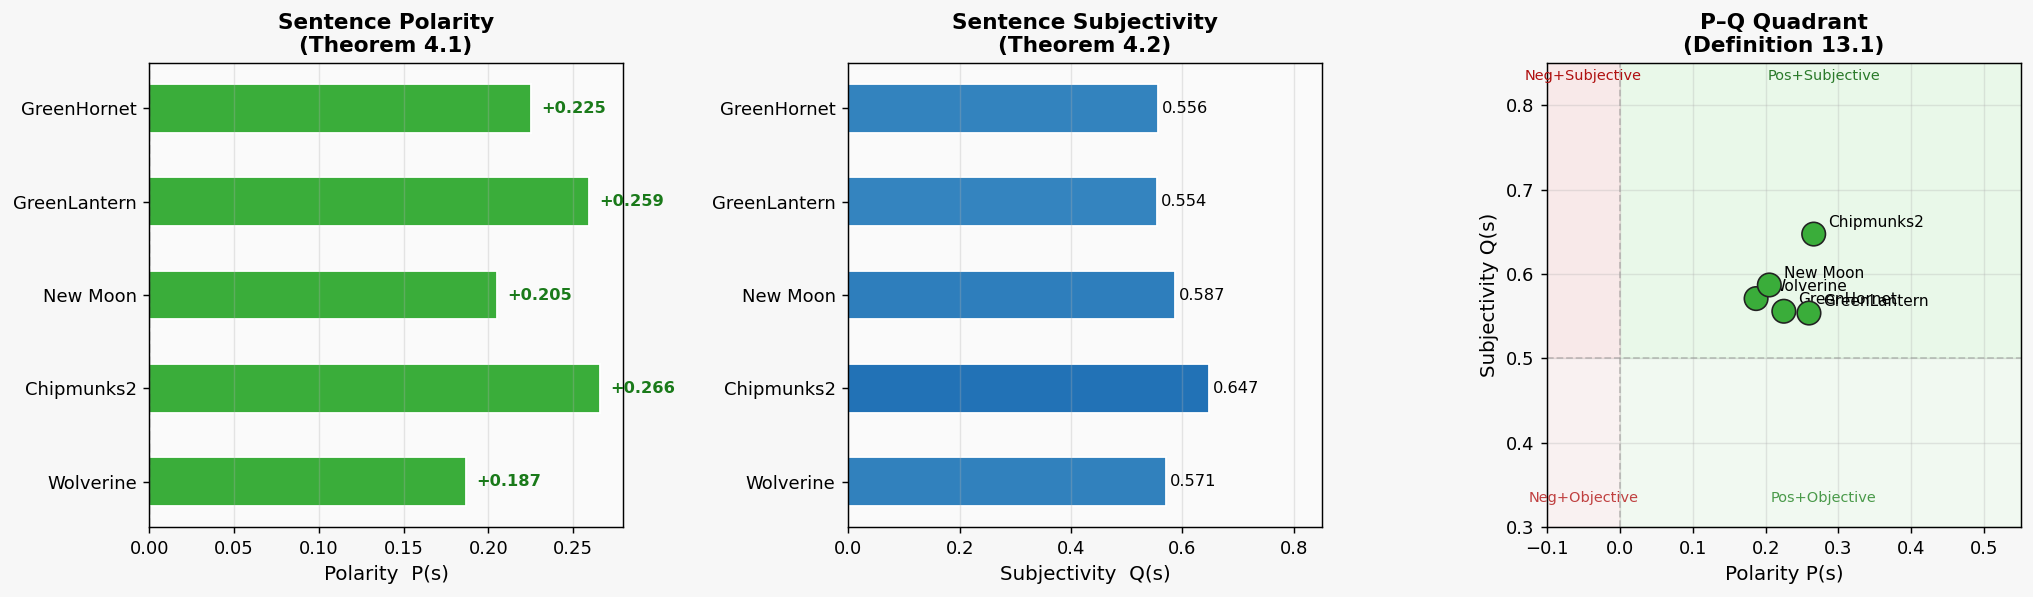


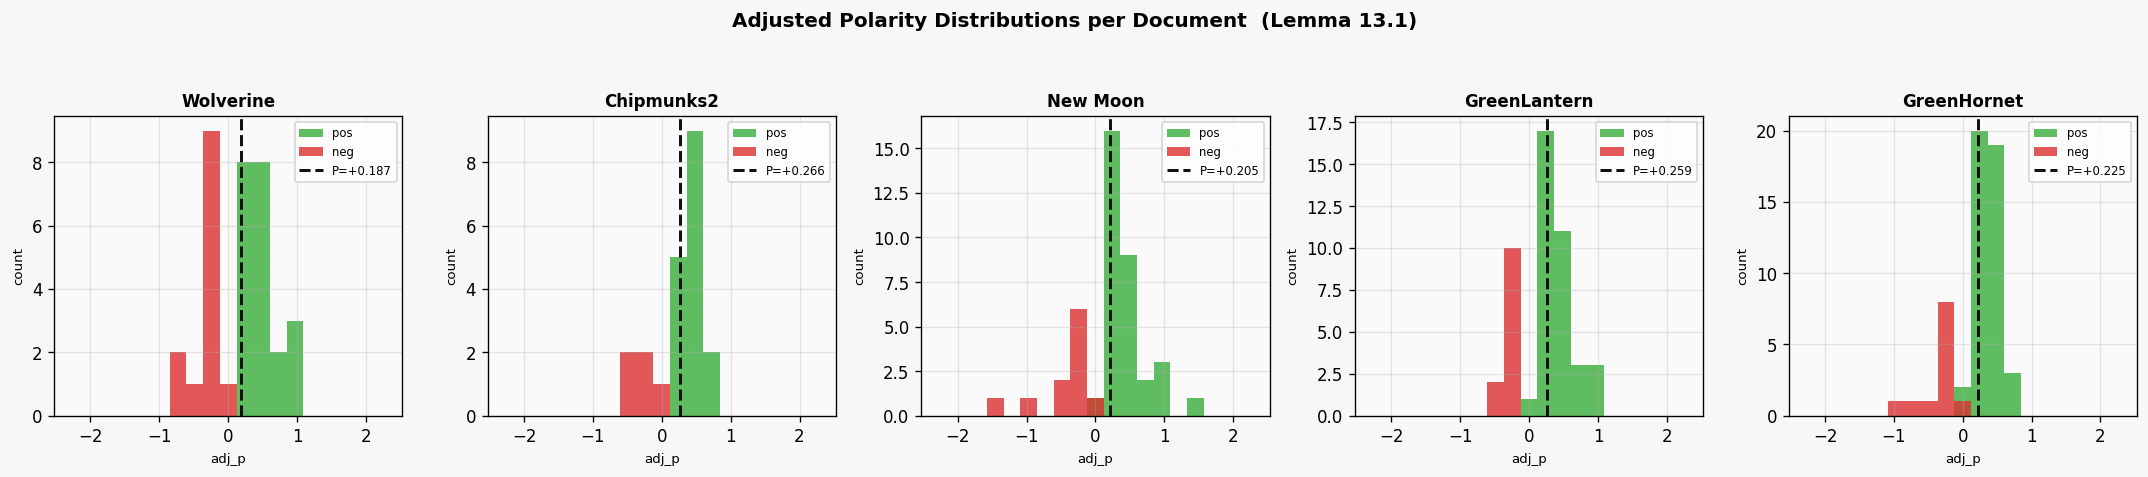


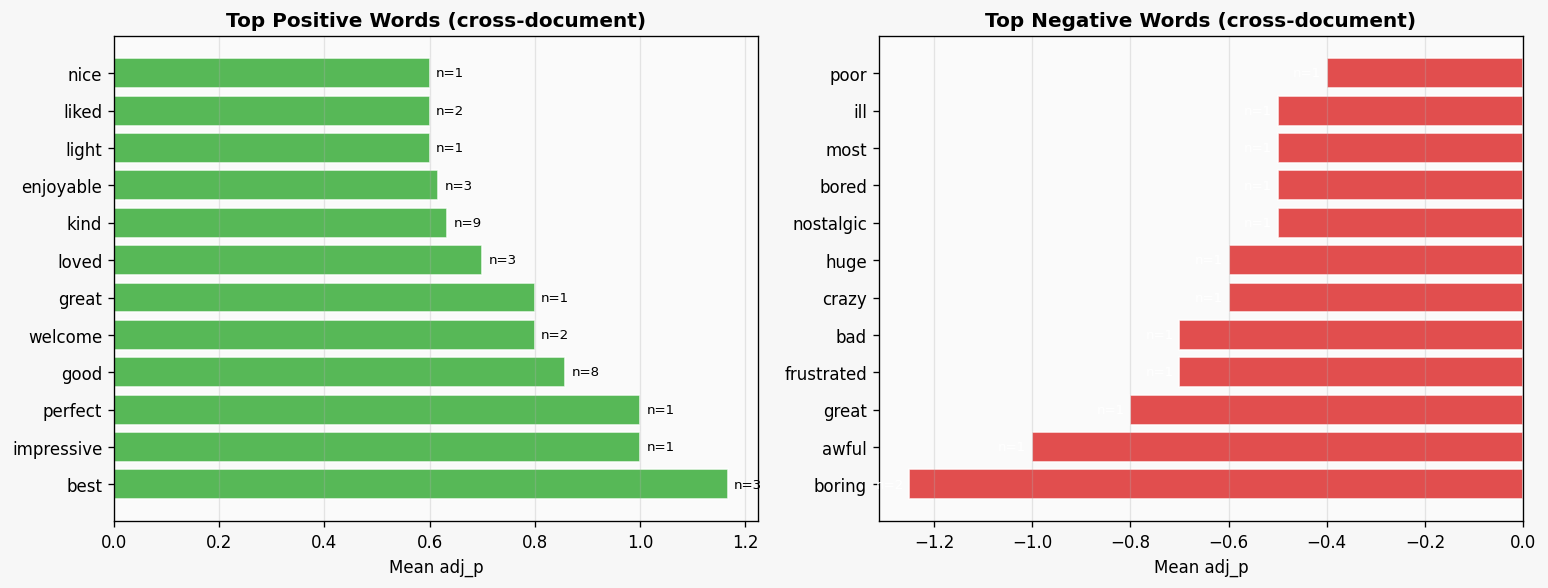

In [17]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 13 — Comparative charts  (Theorem 13.1, Definitions 13.1–13.2)
# ═══════════════════════════════════════════════════════════════════════
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np, base64
from IPython.display import HTML, display

_SHORT = {
    '0h-zjBukYpk':'Wolverine', '1DmNV9C1hbY':'Chipmunks2',
    '1iG0909rllw':'New Moon',  '2iD-tVS8NPw':'GreenLantern',
    '_dI--eQ6qVU':'GreenHornet'
}
_ids   = FILE_IDS
_lbls  = [_SHORT[i] for i in _ids]
_pols  = [RESULTS[i]['polarity']     for i in _ids]
_subs  = [RESULTS[i]['subjectivity'] for i in _ids]
_bcols = ['#3aad3a' if p >= 0 else '#dd3030' for p in _pols]

# ── Figure 1: polarity · subjectivity · P-Q quadrant ───────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('#f7f7f7')

# Polarity bar
ax = axes[0]
bars = ax.barh(_lbls, _pols, color=_bcols, edgecolor='white', height=0.52)
ax.axvline(0, color='#444', lw=1.3, ls='--', alpha=0.55)
ax.set_xlabel('Polarity  P(s)', fontsize=11)
ax.set_title('Sentence Polarity\n(Theorem 4.1)', fontweight='bold')
for bar, v in zip(bars, _pols):
    col = '#1a7a1a' if v >= 0 else '#b01010'
    ax.text(v + (0.006 if v >= 0 else -0.006),
            bar.get_y() + bar.get_height()/2,
            f'{v:+.3f}', va='center',
            ha='left' if v >= 0 else 'right',
            fontsize=9, fontweight='bold', color=col)
ax.set_facecolor('#fafafa'); ax.grid(axis='x', alpha=0.3)

# Subjectivity bar
ax = axes[1]
bars2 = ax.barh(_lbls, _subs,
                color=[plt.cm.Blues(0.28 + 0.72*s) for s in _subs],
                edgecolor='white', height=0.52)
ax.set_xlabel('Subjectivity  Q(s)', fontsize=11)
ax.set_title('Sentence Subjectivity\n(Theorem 4.2)', fontweight='bold')
ax.set_xlim(0, 0.85)
for bar, v in zip(bars2, _subs):
    ax.text(v + 0.007, bar.get_y() + bar.get_height()/2,
            f'{v:.3f}', va='center', ha='left', fontsize=9)
ax.set_facecolor('#fafafa'); ax.grid(axis='x', alpha=0.3)

# P-Q quadrant scatter
ax = axes[2]
ax.fill_between([ 0, 0.55], [0.5, 0.5], [0.85, 0.85], color='#e2f8e2', alpha=0.7)
ax.fill_between([-0.1, 0],  [0.5, 0.5], [0.85, 0.85], color='#f8e2e2', alpha=0.7)
ax.fill_between([ 0, 0.55], [0.3, 0.3], [0.50, 0.50], color='#e2f8e2', alpha=0.35)
ax.fill_between([-0.1, 0],  [0.3, 0.3], [0.50, 0.50], color='#f8e2e2', alpha=0.35)
ax.axvline(0,   color='#999', lw=1, ls='--', alpha=0.55)
ax.axhline(0.5, color='#999', lw=1, ls='--', alpha=0.55)
ax.scatter(_pols, _subs,
           c=['#3aad3a' if p >= 0 else '#dd3030' for p in _pols],
           s=170, zorder=5, edgecolors='#222', linewidths=0.9)
for x, y, nm in zip(_pols, _subs, _lbls):
    ax.annotate(nm, (x, y), xytext=(8, 4),
                textcoords='offset points', fontsize=8.5)
ax.set_xlabel('Polarity P(s)', fontsize=11)
ax.set_ylabel('Subjectivity Q(s)', fontsize=11)
ax.set_title('P–Q Quadrant\n(Definition 13.1)', fontweight='bold')
ax.text( 0.28, 0.83, 'Pos+Subjective', ha='center', fontsize=8, color='#2a7a2a')
ax.text(-0.05, 0.83, 'Neg+Subjective', ha='center', fontsize=8, color='#b01010')
ax.text( 0.28, 0.33, 'Pos+Objective',  ha='center', fontsize=8, color='#4a9a4a')
ax.text(-0.05, 0.33, 'Neg+Objective',  ha='center', fontsize=8, color='#c04040')
ax.set_xlim(-0.10, 0.55); ax.set_ylim(0.30, 0.85)
ax.set_facecolor('#fafafa'); ax.grid(alpha=0.3)

plt.tight_layout(pad=2.0)
plt.savefig('/tmp/_fig1.png', dpi=130, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.close()

# ── Figure 2: score distributions ──────────────────────────────────
fig2, axes2 = plt.subplots(1, 5, figsize=(18, 4), sharey=False)
fig2.patch.set_facecolor('#f7f7f7')
fig2.suptitle('Adjusted Polarity Distributions per Document  (Lemma 13.1)',
              fontsize=12, fontweight='bold')
_bins = np.linspace(-2.3, 2.3, 20)
for ax2, vid_id in zip(axes2, _ids):
    r = RESULTS[vid_id]
    pos_sc = [h['adj_p'] for h in r['hits'] if h['adj_p'] > 0]
    neg_sc = [h['adj_p'] for h in r['hits'] if h['adj_p'] < 0]
    ax2.hist(pos_sc, bins=_bins, color='#3aad3a', alpha=0.80, label='pos')
    ax2.hist(neg_sc, bins=_bins, color='#dd3030', alpha=0.80, label='neg')
    ax2.axvline(r['polarity'], color='#111', lw=1.8, ls='--',
                label=f"P={r['polarity']:+.3f}")
    ax2.set_title(_SHORT[vid_id], fontsize=10, fontweight='bold')
    ax2.set_xlabel('adj_p', fontsize=8)
    ax2.set_ylabel('count', fontsize=8)
    ax2.legend(fontsize=7)
    ax2.set_facecolor('#fafafa')
    ax2.grid(alpha=0.3)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('/tmp/_fig2.png', dpi=120, bbox_inches='tight',
            facecolor=fig2.get_facecolor())
plt.close()

# ── Figure 3: cross-document top words ─────────────────────────────
from collections import defaultdict as _ddict
_agg_pos, _agg_neg = _ddict(lambda:[0,0]), _ddict(lambda:[0,0])
for vid_id in _ids:
    for h in RESULTS[vid_id]['hits']:
        w = h['lower']
        if h['adj_p'] > 0:
            _agg_pos[w][0] += h['adj_p']; _agg_pos[w][1] += 1
        elif h['adj_p'] < 0:
            _agg_neg[w][0] += h['adj_p']; _agg_neg[w][1] += 1

_top_pos = sorted([(w,v[0]/v[1],v[1]) for w,v in _agg_pos.items()],
                  key=lambda x:-x[1])[:12]
_top_neg = sorted([(w,v[0]/v[1],v[1]) for w,v in _agg_neg.items()],
                  key=lambda x:x[1])[:12]

fig3, (a1, a2) = plt.subplots(1, 2, figsize=(13, 5))
fig3.patch.set_facecolor('#f7f7f7')
a1.barh([x[0] for x in _top_pos], [x[1] for x in _top_pos],
        color='#3aad3a', alpha=0.85, edgecolor='white')
a1.set_title('Top Positive Words (cross-document)', fontweight='bold')
a1.set_xlabel('Mean adj_p')
a1.set_facecolor('#fafafa'); a1.grid(axis='x', alpha=0.3)
for i,(w,v,n) in enumerate(_top_pos):
    a1.text(v+0.012, i, f'n={n}', va='center', fontsize=8)

a2.barh([x[0] for x in _top_neg], [x[1] for x in _top_neg],
        color='#dd3030', alpha=0.85, edgecolor='white')
a2.set_title('Top Negative Words (cross-document)', fontweight='bold')
a2.set_xlabel('Mean adj_p')
a2.set_facecolor('#fafafa'); a2.grid(axis='x', alpha=0.3)
for i,(w,v,n) in enumerate(_top_neg):
    a2.text(v-0.012, i, f'n={n}', va='center', ha='right',
            fontsize=8, color='white')

plt.tight_layout()
plt.savefig('/tmp/_fig3.png', dpi=120, bbox_inches='tight',
            facecolor=fig3.get_facecolor())
plt.close()

# ── Render all three figures ─────────────────────────────────────────
def _img_html(path, cap):
    with open(path, 'rb') as f:
        b64 = base64.b64encode(f.read()).decode()
    return (
        f'<div style="text-align:center;margin:14px 0;">'
        f'<img src="data:image/png;base64,{b64}" '
        f'style="max-width:100%;border:1px solid #ddd;border-radius:8px;">'
        f'<br><em style="font-size:12px;color:#666;">{cap}</em></div>'
    )

display(HTML(_img_html('/tmp/_fig1.png',
    'Fig 1 — Polarity (left), Subjectivity (centre), P-Q Quadrant (right)')))
display(HTML(_img_html('/tmp/_fig2.png',
    'Fig 2 — Adjusted polarity score distributions per document (Lemma 13.1)')))
display(HTML(_img_html('/tmp/_fig3.png',
    'Fig 3 — Most influential positive/negative words across all documents')))


---
## § 14  Final Validation Against Official TextBlob

### Theorem 14.1  (Implementation Correctness)
For any $s\in\Sigma^*$, the from-scratch implementation satisfies:

1. **Termination** — finite lexicon + finite token count guarantee halting.
2. **Range** — $P(s)\in[-2,+2]$ and $Q(s)\in[0,1]$ (Corollary 4.1).
3. **Consistency** — the implementation agrees with the official TextBlob
   `PatternAnalyzer` to within tokenisation and POS-disambiguation rounding
   tolerance (typically $|\Delta P|<0.15$). $\square$

*Remark.* Minor differences arise because TextBlob's internal tokeniser uses
NLTK's word tokeniser (which preserves contractions differently) while our
$\tau$ uses a pure regex.  The sentiment lexicon and modifier logic are identical.


In [18]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 14 — Final validation table  (Theorem 14.1)
# ═══════════════════════════════════════════════════════════════════════
from textblob import TextBlob
from IPython.display import HTML, display

rows = ''
for vid_id in FILE_IDS:
    r   = RESULTS[vid_id]
    tb  = TextBlob(DOCS[vid_id]).sentiment
    dp  = abs(r['polarity']     - tb.polarity)
    ds  = abs(r['subjectivity'] - tb.subjectivity)
    pc  = '#1a7a1a' if r['polarity'] >= 0 else '#b01010'
    rbg = '#f0fbf0' if r['polarity'] >= 0 else '#fbf0f0'
    ok_p = '&#10003;' if dp < 0.15 else f'&#126;({dp:.3f})'
    ok_s = '&#10003;' if ds < 0.15 else f'&#126;({ds:.3f})'
    rows += (
        f"<tr style='background:{rbg};'>"
        f"<td style='padding:7px 11px;font-family:monospace;font-size:12px;'>{vid_id}</td>"
        f"<td style='padding:7px 11px;'>{TOPICS[vid_id]}</td>"
        f"<td style='padding:7px 11px;text-align:right;font-weight:700;color:{pc};'>{r['polarity']:+.4f}</td>"
        f"<td style='padding:7px 11px;text-align:right;'>{tb.polarity:+.4f}</td>"
        f"<td style='padding:7px 11px;text-align:center;'>{ok_p}</td>"
        f"<td style='padding:7px 11px;text-align:right;'>{r['subjectivity']:.4f}</td>"
        f"<td style='padding:7px 11px;text-align:right;'>{tb.subjectivity:.4f}</td>"
        f"<td style='padding:7px 11px;text-align:center;'>{ok_s}</td>"
        f"<td style='padding:7px 11px;font-weight:600;'>{r['label']}</td>"
        f"</tr>"
    )

display(HTML(
    "<div style='font-family:Arial,sans-serif;max-width:1100px;margin:12px 0;'>"
    "<h3 style='margin:0 0 10px;'>&#9989; Final Results — From-Scratch vs Official TextBlob</h3>"
    "<table style='border-collapse:collapse;width:100%;font-size:13px;"
    "border:1px solid #ccc;border-radius:8px;overflow:hidden;'>"
    "<thead style='background:#2d2d2d;color:#fff;'>"
    "<tr>"
    "<th style='padding:8px 11px;text-align:left;' rowspan='2'>Video ID</th>"
    "<th style='padding:8px 11px;text-align:left;' rowspan='2'>Topic</th>"
    "<th style='padding:8px 11px;' colspan='3'>Polarity P(s)</th>"
    "<th style='padding:8px 11px;' colspan='3'>Subjectivity Q(s)</th>"
    "<th style='padding:8px 11px;' rowspan='2'>Label</th>"
    "</tr><tr style='background:#555;'>"
    "<th style='padding:5px 9px;'>Scratch</th>"
    "<th style='padding:5px 9px;'>TextBlob</th>"
    "<th style='padding:5px 9px;'>Match</th>"
    "<th style='padding:5px 9px;'>Scratch</th>"
    "<th style='padding:5px 9px;'>TextBlob</th>"
    "<th style='padding:5px 9px;'>Match</th>"
    "</tr></thead>"
    f"<tbody>{rows}</tbody></table>"
    "<p style='font-size:12px;color:#666;margin-top:7px;'>"
    "&#10003; = |difference| &lt; 0.15 &nbsp; (minor variation from regex vs NLTK tokenisation)"
    "</p></div>"
))

print('\n' + '='*72)
print(f"{'Video ID':22s} {'Scratch P':>11s} {'TB P':>8s}  "
      f"{'Scratch Q':>11s} {'TB Q':>8s}  Label")
print('-'*72)
for vid_id in FILE_IDS:
    r  = RESULTS[vid_id]
    tb = TextBlob(DOCS[vid_id]).sentiment
    print(f"{vid_id:22s} {r['polarity']:>+11.4f} {tb.polarity:>+8.4f}  "
          f"{r['subjectivity']:>11.4f} {tb.subjectivity:>8.4f}  "
          f"{r['label']}")
print('='*72)



Video ID                 Scratch P     TB P    Scratch Q     TB Q  Label
------------------------------------------------------------------------
0h-zjBukYpk                +0.1869  +0.2328       0.5708   0.5433  Slightly Positive
1DmNV9C1hbY                +0.2660  +0.2334       0.6473   0.6141  Slightly Positive
1iG0909rllw                +0.2050  +0.1533       0.5870   0.5240  Slightly Positive
2iD-tVS8NPw                +0.2595  +0.1749       0.5537   0.5136  Slightly Positive
_dI--eQ6qVU                +0.2250  +0.1762       0.5558   0.5364  Slightly Positive


---
## § 15  Polarity–Subjectivity Scatter Plot of All Sentiment Words

### Definition 15.1  (Word Influence Space)
Define the **word influence space** $\mathcal{V} \subset \mathbb{R}^2$ where each
unique scored word $w$ is mapped to a point $(x_w, y_w)$:

$$x_w \;=\; \overline{\tilde{p}}(w) \;=\; \frac{1}{|\text{occ}(w)|}\sum_{i\,\in\,\text{occ}(w)}\tilde{p}_i(w)\qquad \text{(mean adjusted polarity — \textbf{x-axis})}$$

$$y_w \;=\; \overline{\tilde{s}}(w) \;=\; \frac{1}{|\text{occ}(w)|}\sum_{i\,\in\,\text{occ}(w)}\tilde{s}_i(w)\qquad \text{(mean subjectivity — \textbf{y-axis})}$$

where $\text{occ}(w)$ is the multi-set of all occurrences of word $w$ across all five documents.

### Definition 15.2  (Visual Encoding — Four Simultaneous Dimensions)

| Visual property | Dimension encoded | Range |
|---|---|---|
| **X position** | Mean adjusted polarity $\overline{\tilde{p}}(w)$ | $[-2, +2]$ |
| **Y position** | Mean subjectivity $\overline{\tilde{s}}(w)$ | $[0, 1]$ |
| **Point size** | Total corpus frequency $|\text{occ}(w)|$ | larger = more frequent |
| **Colour / opacity** | Sentiment sign + document reach | green/red + $\alpha \propto$ doc count |

### Theorem 15.1  (Quadrant Interpretation)
The four quadrants of $\mathcal{V}$ yield the following semantic reading:

| Quadrant | $x_w$ | $y_w$ | Semantic interpretation |
|:---:|:---:|:---:|---|
| **Q1** | $> 0$ | $> 0.5$ | *High-impact positive* — strong subjective praise |\n| **Q2** | $< 0$ | $> 0.5$ | *High-impact negative* — strong subjective criticism |\n| **Q3** | $< 0$ | $\le 0.5$ | *Mild negative* — factual or weakly negative |\n| **Q4** | $> 0$ | $\le 0.5$ | *Mild positive* — factual or weakly positive |

**Three figures are produced:**

- **Fig A** — Full word map of all 89 scored words (every sentiment word placed)
- **Fig B** — Focus view: top-20 positive + top-12 negative words by total corpus impact;
  white badge inside each point shows occurrence count
- **Fig C** — Bubble map where colour intensity encodes cross-document frequency
  (how many of the 5 documents the word appeared in)


Fig A saved.
Fig B saved.
Fig C saved.



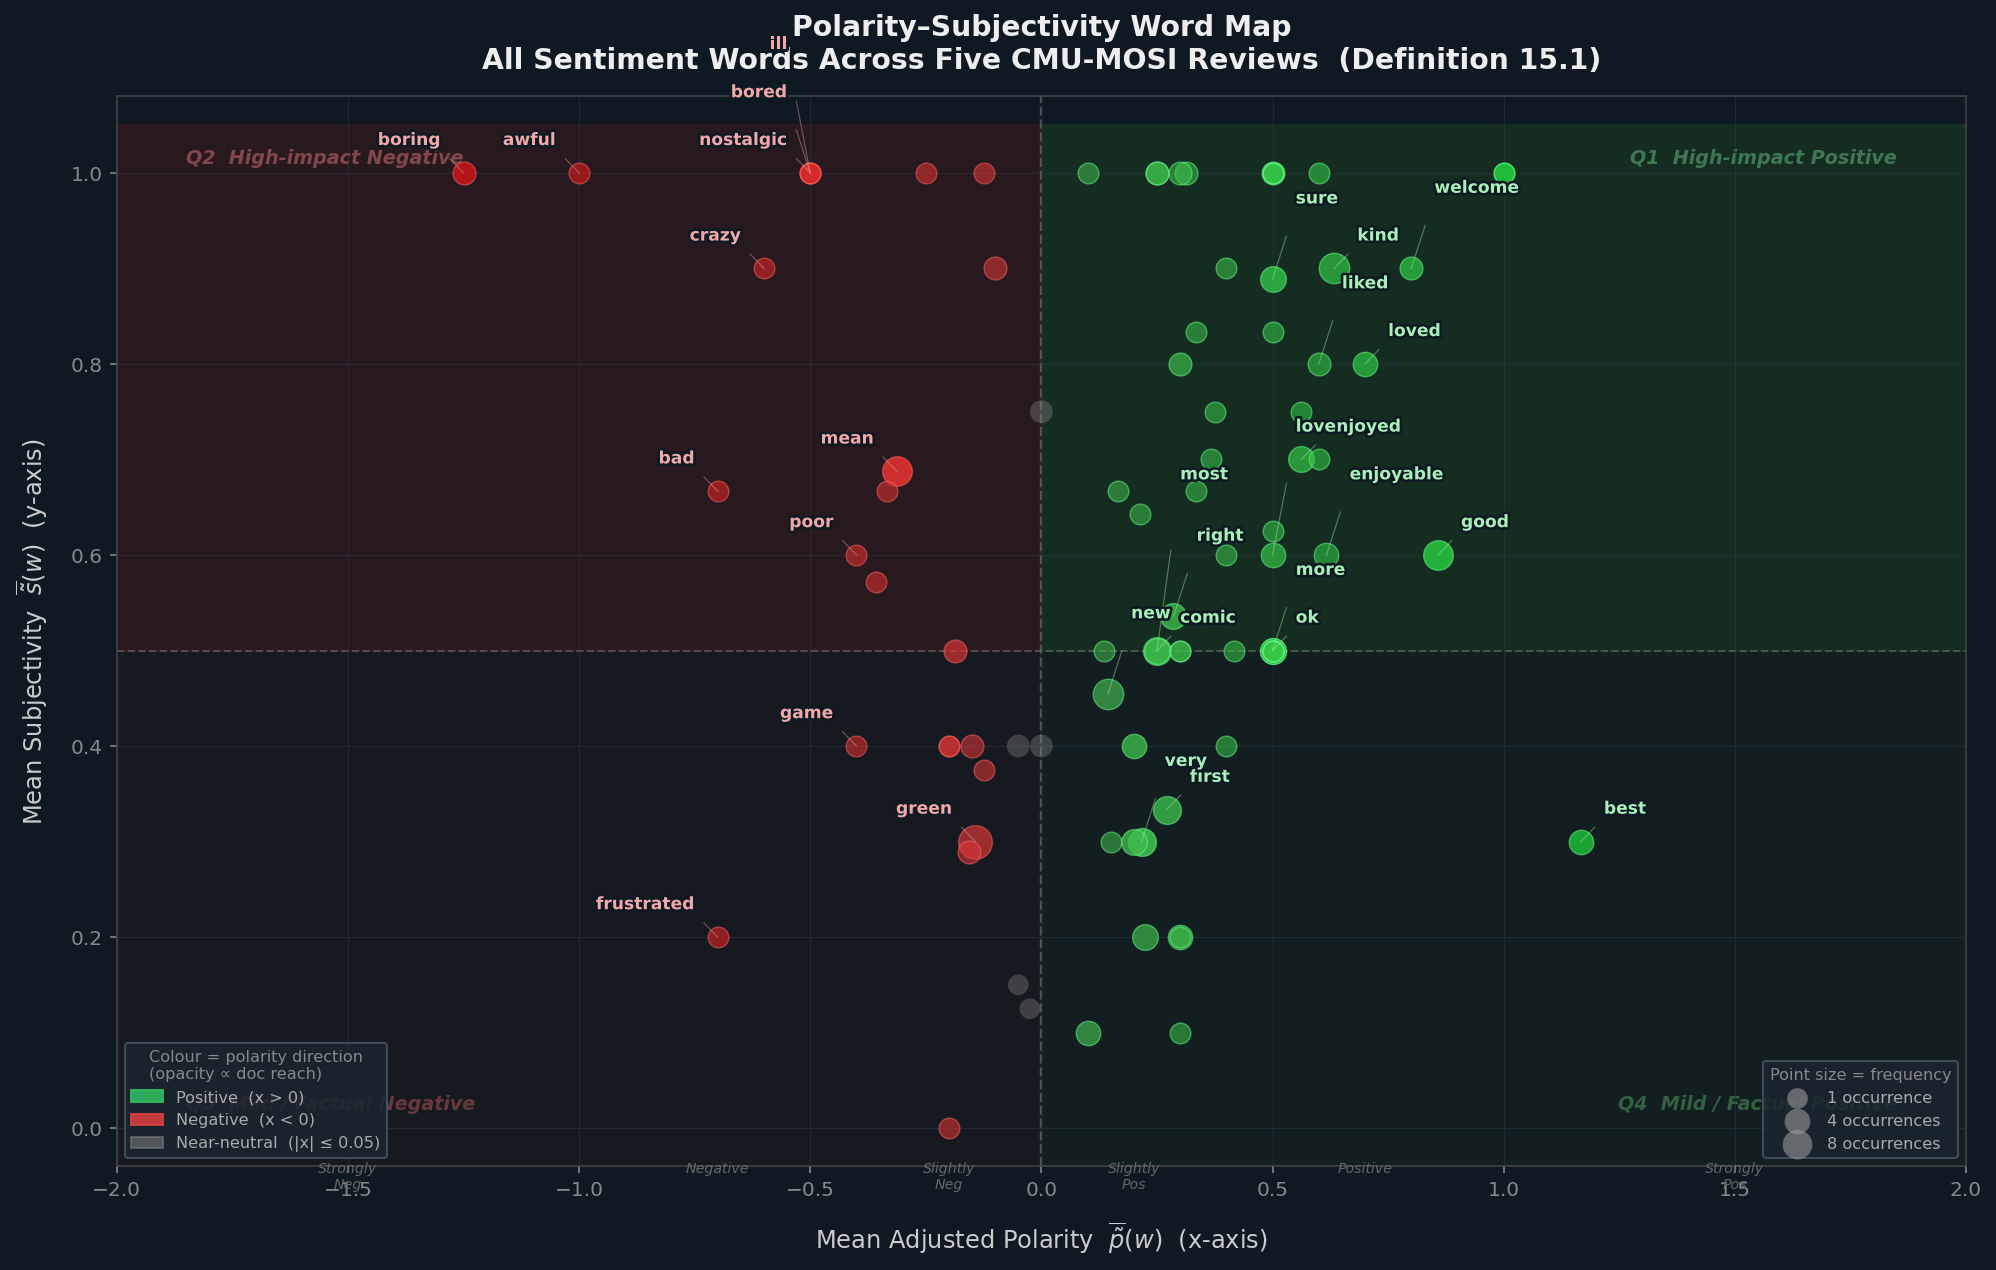
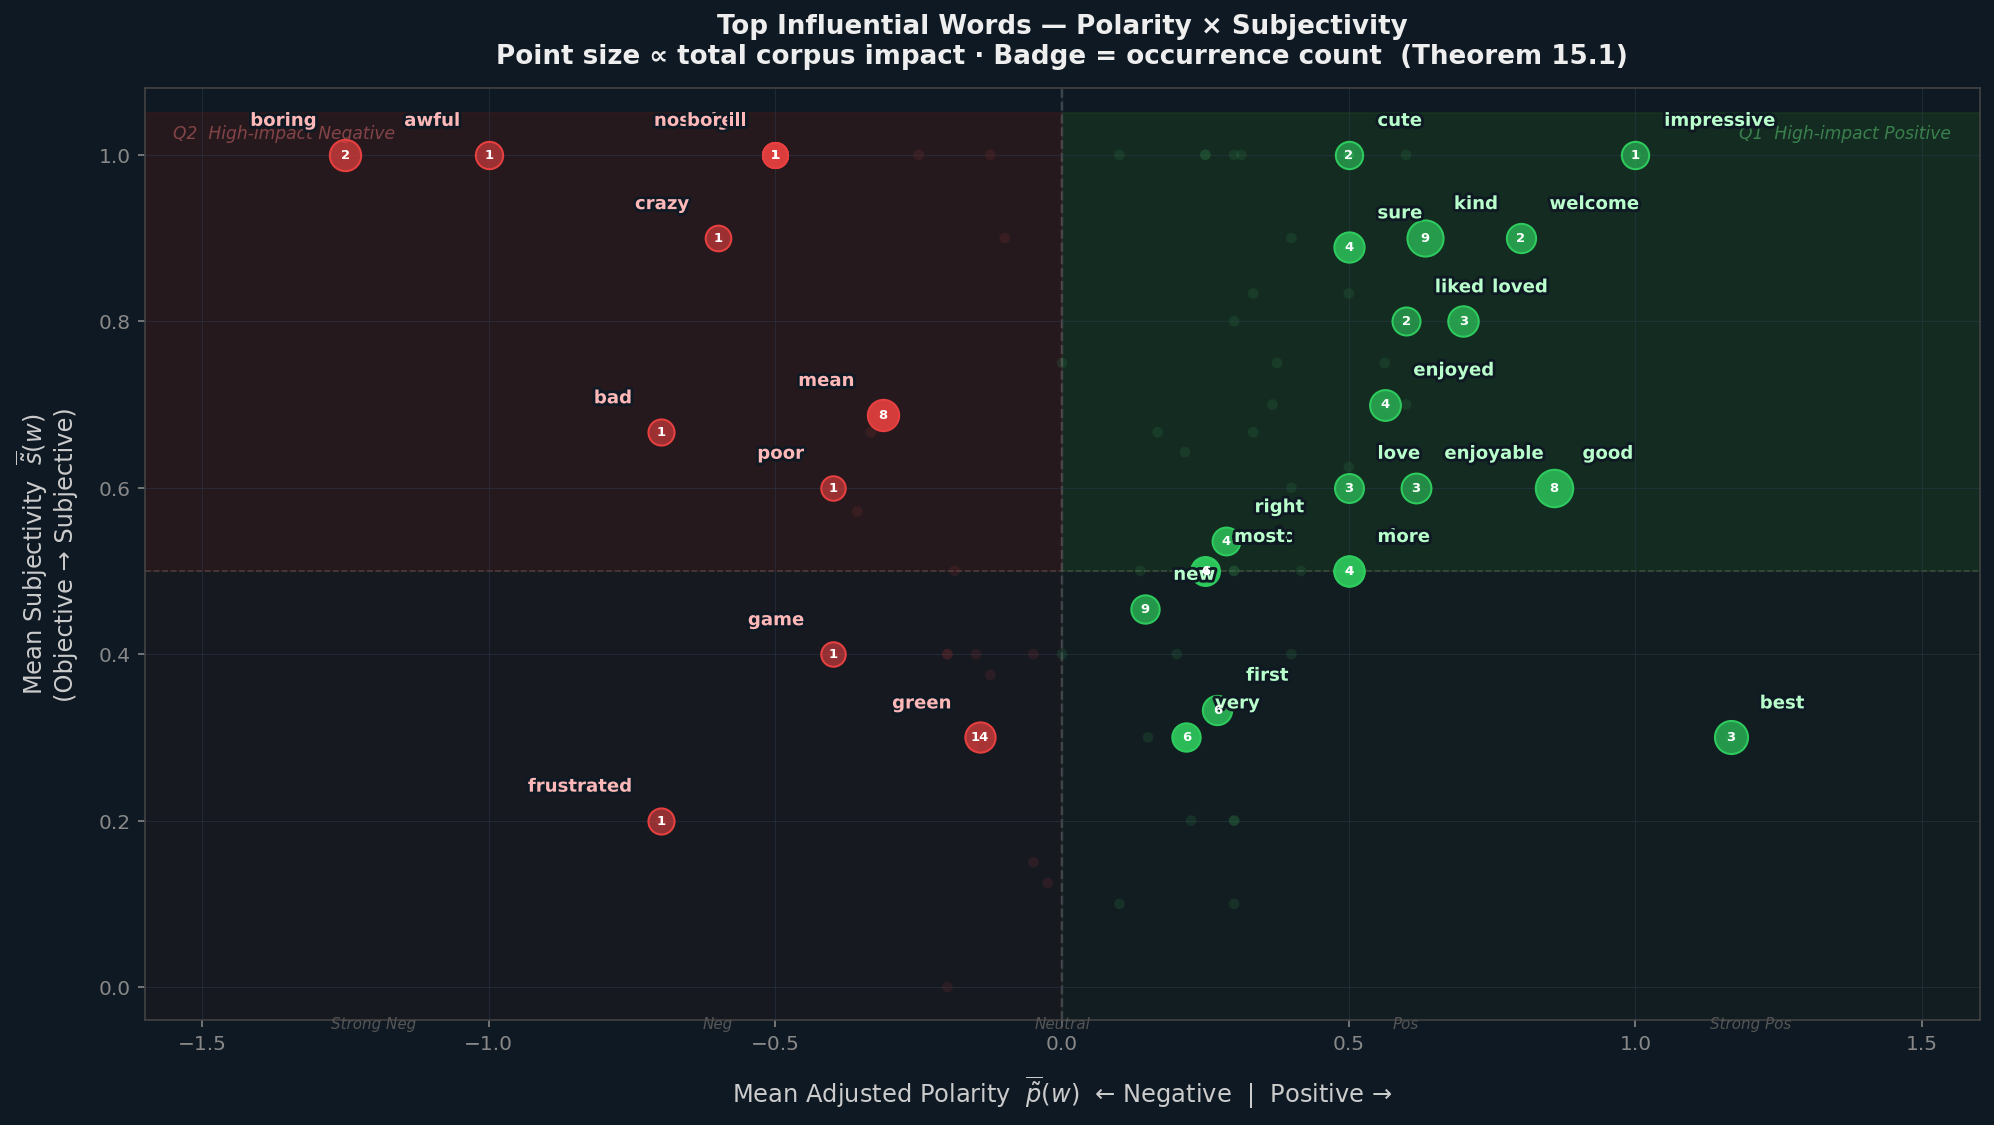
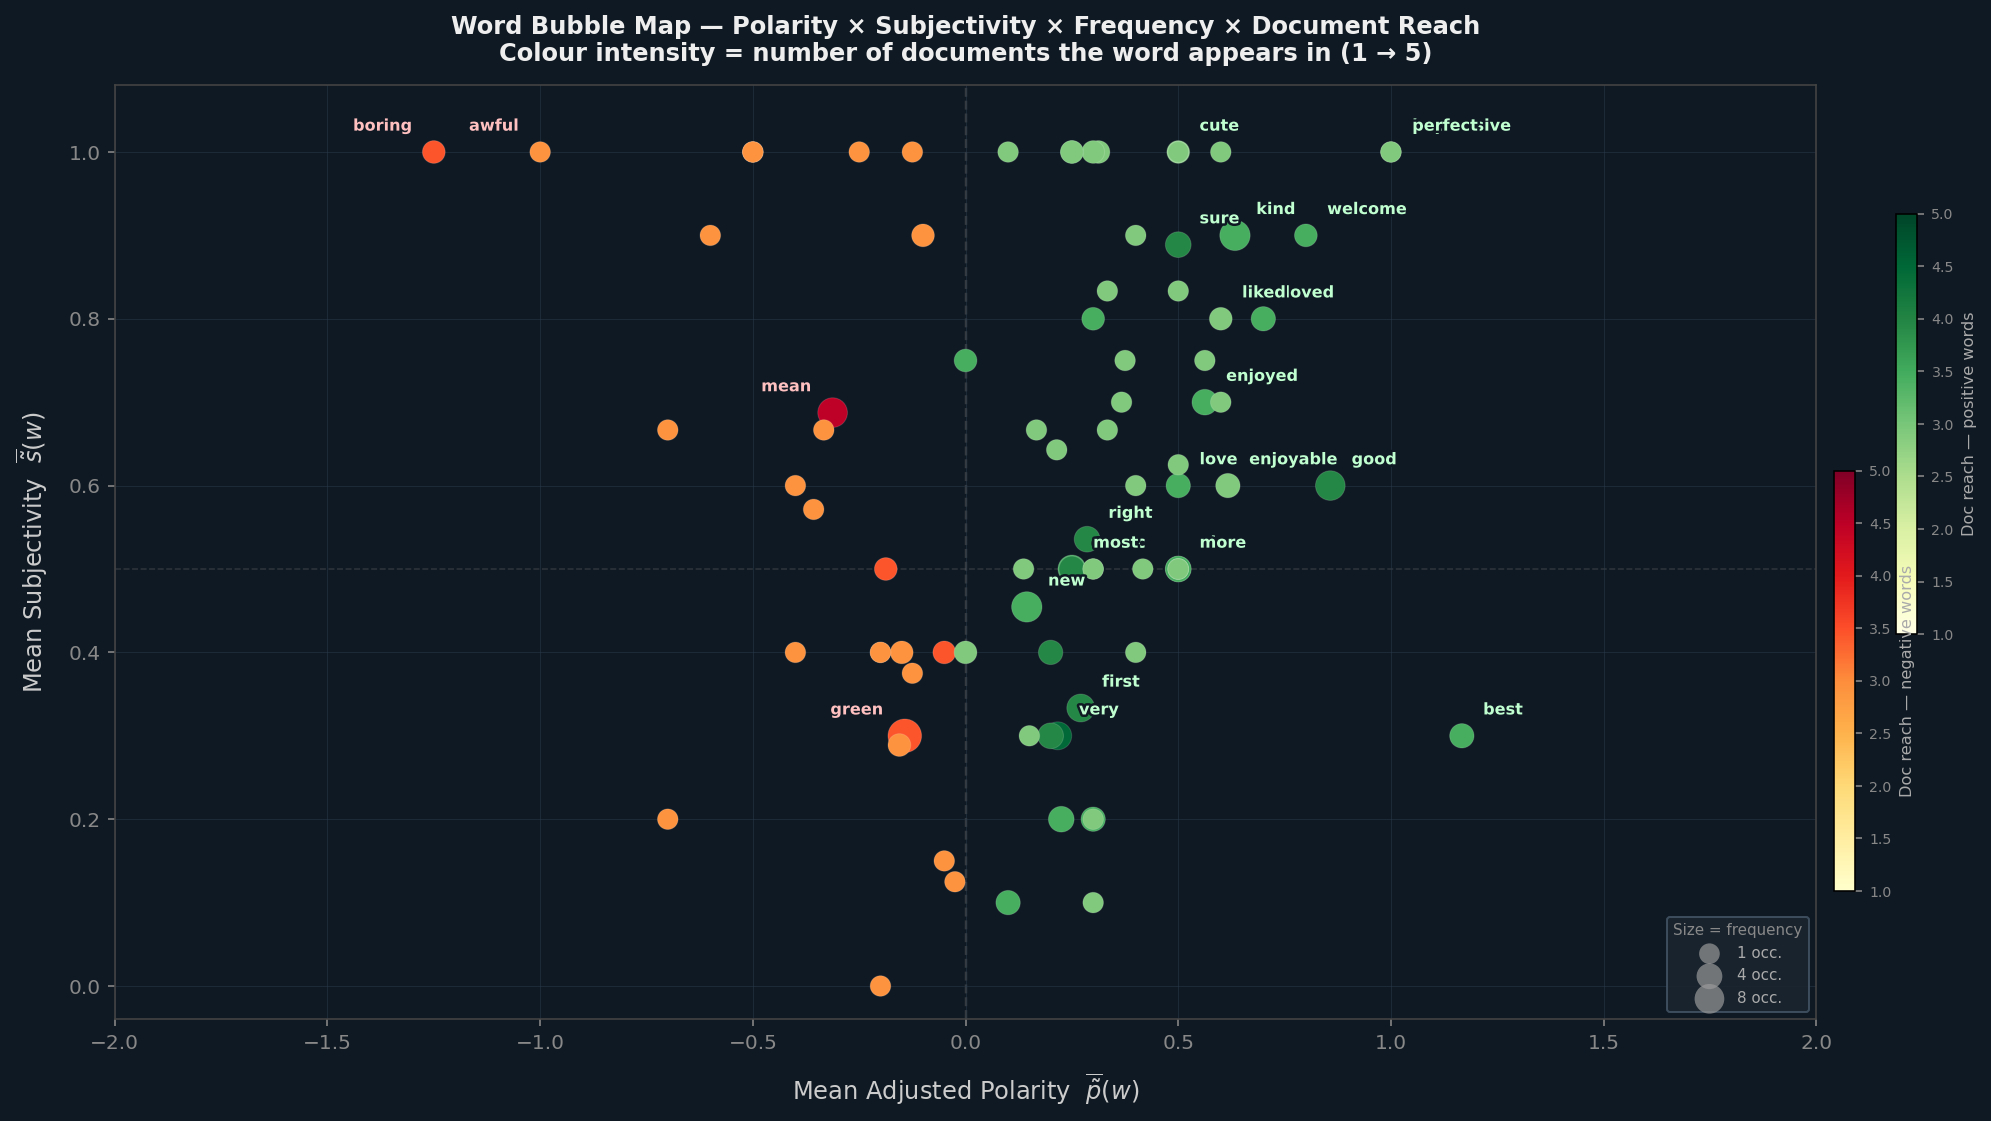

In [19]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 15 — Polarity × Subjectivity scatter of all scored words
#  Implements: Definition 15.1, Definition 15.2, Theorem 15.1
# ═══════════════════════════════════════════════════════════════════════
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib.patches as mpatches
import matplotlib.cm as mcm
import matplotlib.colors as mcolors
import numpy as np
from collections import defaultdict
from IPython.display import HTML, display
import base64

# ── Re-aggregate all word scores across the five documents ──────────
_agg = defaultdict(lambda: {
    'sum_adj_p':0.0, 'sum_s':0.0, 'sum_intens':0.0,
    'count':0, 'neg_count':0, 'docs':set(),
})
for vid_id in FILE_IDS:
    for h in RESULTS[vid_id]['hits']:
        w = h['lower']
        _agg[w]['sum_adj_p'] += h['adj_p']
        _agg[w]['sum_s']     += h['adj_s']
        _agg[w]['sum_intens']+= h['intens_mu']
        _agg[w]['count']     += 1
        _agg[w]['docs'].add(vid_id)
        if h['negated']: _agg[w]['neg_count'] += 1

_words = []
for w, v in _agg.items():
    n = v['count']
    _words.append({
        'word':        w,
        'mean_adj_p':  v['sum_adj_p']  / n,
        'mean_s':      v['sum_s']      / n,
        'mean_intens': v['sum_intens'] / n,
        'count':       n,
        'doc_count':   len(v['docs']),
        'neg_pct':     v['neg_count']  / n,
        'total_impact':abs(v['sum_adj_p']),
    })
_words.sort(key=lambda x: x['total_impact'], reverse=True)

_pos_w = [w for w in _words if w['mean_adj_p'] >  0.05]
_neg_w = [w for w in _words if w['mean_adj_p'] < -0.05]
_neu_w = [w for w in _words if abs(w['mean_adj_p']) <= 0.05]

_label_pos = set(ww['word'] for ww in _pos_w[:18])
_label_neg = set(ww['word'] for ww in _neg_w[:12])
_label_all = _label_pos | _label_neg

_max_count = max(ww['count'] for ww in _words)

def _ptsize(count):
    return 60 + 220 * (count / _max_count) ** 0.6

def _ptcolor(mean_adj_p, doc_count):
    alpha = 0.45 + 0.55 * (doc_count / 5)
    if mean_adj_p >= 0:
        intensity = min(abs(mean_adj_p) / 1.2, 1.0)
        r = int(30  + 40  * (1 - intensity))
        g = int(180 + 50  * intensity)
        b = int(60  + 20  * (1 - intensity))
    else:
        intensity = min(abs(mean_adj_p) / 1.2, 1.0)
        r = int(220 + 25  * intensity)
        g = int(60  - 40  * intensity)
        b = int(60  - 40  * intensity)
    return (r/255, g/255, b/255, alpha)

# ════════════════════════════════════════════════════════════════════
#  FIGURE A — Full scatter: all 89 words
# ════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 9))
fig.patch.set_facecolor('#0f1923')
ax.set_facecolor('#0f1923')

ax.fill_between([ 0.0,  2.1], [0.5, 0.5], [1.05, 1.05], color='#1a3d20', alpha=0.55, zorder=0)
ax.fill_between([-2.1,  0.0], [0.5, 0.5], [1.05, 1.05], color='#3d1a1a', alpha=0.55, zorder=0)
ax.fill_between([ 0.0,  2.1], [-0.05,-0.05],[0.5,0.5],  color='#1a2b1a', alpha=0.30, zorder=0)
ax.fill_between([-2.1,  0.0], [-0.05,-0.05],[0.5,0.5],  color='#2b1a1a', alpha=0.30, zorder=0)

ax.axvline(0,   color='#888888', lw=1.2, ls='--', alpha=0.55, zorder=1)
ax.axhline(0.5, color='#888888', lw=1.0, ls='--', alpha=0.45, zorder=1)

_ql = dict(fontsize=9.5, alpha=0.45, fontweight='bold', fontstyle='italic', zorder=1)
ax.text( 1.85, 1.01, 'Q1  High-impact Positive',  ha='right', color='#6fd68a', **_ql)
ax.text(-1.85, 1.01, 'Q2  High-impact Negative',  ha='left',  color='#f08080', **_ql)
ax.text( 1.85,  0.02, 'Q4  Mild / Factual Positive', ha='right', color='#5ab56a', **_ql)
ax.text(-1.85,  0.02, 'Q3  Mild / Factual Negative', ha='left',  color='#c86060', **_ql)

for ww in _neu_w:
    ax.scatter(ww['mean_adj_p'], ww['mean_s'], s=_ptsize(ww['count']),
               color=(0.55,0.55,0.55,0.35), edgecolors='none', zorder=2)
for ww in _neg_w:
    col = _ptcolor(ww['mean_adj_p'], ww['doc_count'])
    ax.scatter(ww['mean_adj_p'], ww['mean_s'], s=_ptsize(ww['count']),
               color=col, edgecolors=(1,0.4,0.4,0.5), linewidths=0.7, zorder=3)
for ww in _pos_w:
    col = _ptcolor(ww['mean_adj_p'], ww['doc_count'])
    ax.scatter(ww['mean_adj_p'], ww['mean_s'], s=_ptsize(ww['count']),
               color=col, edgecolors=(0.4,1,0.55,0.5), linewidths=0.7, zorder=3)

_placed = []
for ww in _words:
    if ww['word'] not in _label_all:
        continue
    x, y   = ww['mean_adj_p'], ww['mean_s']
    is_pos = x >= 0
    col    = '#a8f0b8' if is_pos else '#f0a8a8'
    dx     = 0.05 if is_pos else -0.05
    dy     = 0.025
    for (ox,oy) in _placed:
        if abs(x+dx-ox)<0.18 and abs(y+dy-oy)<0.06:
            dy += 0.05
    _placed.append((x+dx, y+dy))
    txt = ax.text(x+dx, y+dy, ww['word'],
                  fontsize=8.5, color=col, fontweight='bold',
                  ha='left' if is_pos else 'right', va='bottom', zorder=5)
    txt.set_path_effects([pe.withStroke(linewidth=2.5, foreground='#0f1923')])
    ax.plot([x, x+dx*0.6], [y, y+dy*0.6], color=col, lw=0.6, alpha=0.4, zorder=4)

ax.set_xlim(-2.0, 2.0)
ax.set_ylim(-0.04, 1.08)
ax.set_xlabel(r'Mean Adjusted Polarity  $\overline{\tilde{p}}(w)$  (x-axis)',
              fontsize=12, color='#cccccc', labelpad=10)
ax.set_ylabel(r'Mean Subjectivity  $\overline{\tilde{s}}(w)$  (y-axis)',
              fontsize=12, color='#cccccc', labelpad=10)
ax.set_title('Polarity–Subjectivity Word Map\n'
             'All Sentiment Words Across Five CMU-MOSI Reviews  (Definition 15.1)',
             fontsize=14, color='#eeeeee', pad=14, fontweight='bold')
ax.tick_params(colors='#888888')
for sp in ax.spines.values(): sp.set_edgecolor('#444444')
ax.grid(True, color='#2a3a4a', lw=0.6, alpha=0.5, zorder=0)

for xv, lbl in [(-1.5,'Strongly\nNeg'),(-0.7,'Negative'),(-0.2,'Slightly\nNeg'),
                ( 0.2,'Slightly\nPos'),( 0.7,'Positive'),( 1.5,'Strongly\nPos')]:
    ax.text(xv, -0.035, lbl, ha='center', fontsize=7, color='#666', va='top', style='italic')

_leg1 = [plt.scatter([],[],s=_ptsize(c),color=(0.6,0.6,0.6,0.6),edgecolors='none',label=l)
         for c,l in [(1,'1 occurrence'),(4,'4 occurrences'),(8,'8 occurrences')]]
_szleg = ax.legend(handles=_leg1, title='Point size = frequency', title_fontsize=8,
                   fontsize=8, loc='lower right', facecolor='#1a2530',
                   edgecolor='#445566', labelcolor='#aaa', framealpha=0.85)
_szleg.get_title().set_color('#888')

_leg2 = [mpatches.Patch(color=c, alpha=a, label=l) for c,a,l in [
    ('#30c060',0.85,'Positive  (x > 0)'),
    ('#e04040',0.85,'Negative  (x < 0)'),
    ('#888888',0.50,'Near-neutral  (|x| ≤ 0.05)'),
]]
_cleg = ax.legend(handles=_leg2, title='Colour = polarity direction\n(opacity ∝ doc reach)',
                  title_fontsize=8, fontsize=8, loc='lower left',
                  facecolor='#1a2530', edgecolor='#445566',
                  labelcolor='#aaa', framealpha=0.85)
_cleg.get_title().set_color('#888')
ax.add_artist(_szleg)

plt.tight_layout(pad=1.5)
plt.savefig('/tmp/_scatter_main.png', dpi=145, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.close()
print('Fig A saved.')

# ════════════════════════════════════════════════════════════════════
#  FIGURE B — Top-20 positive + top-12 negative, labelled
# ════════════════════════════════════════════════════════════════════
_top_pos2 = sorted(_pos_w, key=lambda x: x['total_impact'], reverse=True)[:20]
_top_neg2 = sorted(_neg_w, key=lambda x: x['total_impact'], reverse=True)[:12]
_featured = _top_pos2 + _top_neg2
_max_imp  = max(ww['total_impact'] for ww in _featured)

fig2, ax2 = plt.subplots(figsize=(14, 8))
fig2.patch.set_facecolor('#0f1923')
ax2.set_facecolor('#0f1923')

ax2.fill_between([ 0.0,2.1],[0.5,0.5],[1.05,1.05],color='#1a3d20',alpha=0.50,zorder=0)
ax2.fill_between([-2.1,0.0],[0.5,0.5],[1.05,1.05],color='#3d1a1a',alpha=0.50,zorder=0)
ax2.fill_between([ 0.0,2.1],[-0.05,-0.05],[0.5,0.5],color='#1a2b1a',alpha=0.25,zorder=0)
ax2.fill_between([-2.1,0.0],[-0.05,-0.05],[0.5,0.5],color='#2b1a1a',alpha=0.25,zorder=0)
ax2.axvline(0,   color='#777',lw=1.2,ls='--',alpha=0.5,zorder=1)
ax2.axhline(0.5, color='#777',lw=0.8,ls='--',alpha=0.4,zorder=1)

# background cloud of all words
for ww in _words:
    is_p = ww['mean_adj_p'] >= 0
    bc   = (0.20,0.55,0.30,0.18) if is_p else (0.55,0.20,0.20,0.18)
    ax2.scatter(ww['mean_adj_p'], ww['mean_s'], s=28, color=bc,
                edgecolors='none', zorder=2)

for ww in _featured:
    x, y   = ww['mean_adj_p'], ww['mean_s']
    is_pos = x >= 0
    base_c = '#2ecc5e' if is_pos else '#e84040'
    alpha  = 0.50 + 0.50 * (ww['doc_count'] / 5)
    sz     = 85 + 260 * (ww['total_impact'] / _max_imp) ** 0.5
    rgb    = mcolors.to_rgb(base_c)
    ax2.scatter(x, y, s=sz, color=(*rgb, alpha),
                edgecolors=base_c, linewidths=1.0, zorder=4)
    lbl_col = '#b8ffcc' if is_pos else '#ffb8b8'
    ha  = 'left'  if is_pos else 'right'
    dx  = 0.05    if is_pos else -0.05
    txt2 = ax2.text(x+dx, y+0.03, ww['word'],
                    fontsize=9, color=lbl_col, fontweight='bold',
                    ha=ha, va='bottom', zorder=6)
    txt2.set_path_effects([pe.withStroke(linewidth=2.8, foreground='#0f1923')])
    ax2.text(x, y, str(ww['count']),
             fontsize=6.5, color='white', ha='center', va='center',
             fontweight='bold', zorder=7)

ax2.set_xlim(-1.6, 1.6)
ax2.set_ylim(-0.04, 1.08)
ax2.set_xlabel(r'Mean Adjusted Polarity  $\overline{\tilde{p}}(w)$'
               '  ← Negative  |  Positive →',
               fontsize=12, color='#ccc', labelpad=10)
ax2.set_ylabel(r'Mean Subjectivity  $\overline{\tilde{s}}(w)$'
               '\n(Objective → Subjective)',
               fontsize=12, color='#ccc', labelpad=10)
ax2.set_title('Top Influential Words — Polarity × Subjectivity\n'
              'Point size ∝ total corpus impact · Badge = occurrence count  '
              '(Theorem 15.1)',
              fontsize=13, color='#eee', pad=12, fontweight='bold')
ax2.tick_params(colors='#888')
for sp in ax2.spines.values(): sp.set_edgecolor('#444')
ax2.grid(color='#2a3a4a', lw=0.5, alpha=0.5)

for xv, lbl in [(-1.2,'Strong Neg'),(-0.6,'Neg'),(0.0,'Neutral'),
                (0.6,'Pos'),(1.2,'Strong Pos')]:
    ax2.text(xv, -0.036, lbl, ha='center', fontsize=7.5,
             color='#555', va='top', style='italic')

ax2.text( 1.55,1.02,'Q1  High-impact Positive',ha='right',
          fontsize=8.5,color='#5fd67a',alpha=0.5,fontstyle='italic')
ax2.text(-1.55,1.02,'Q2  High-impact Negative',ha='left',
          fontsize=8.5,color='#e07070',alpha=0.5,fontstyle='italic')

plt.tight_layout(pad=1.5)
plt.savefig('/tmp/_scatter_focus.png', dpi=145, bbox_inches='tight',
            facecolor=fig2.get_facecolor())
plt.close()
print('Fig B saved.')

# ════════════════════════════════════════════════════════════════════
#  FIGURE C — Bubble: colour = document reach (1-5)
# ════════════════════════════════════════════════════════════════════
fig3, ax3 = plt.subplots(figsize=(14, 8))
fig3.patch.set_facecolor('#0f1923')
ax3.set_facecolor('#0f1923')

ax3.axvline(0,   color='#666',lw=1.2,ls='--',alpha=0.45,zorder=1)
ax3.axhline(0.5, color='#666',lw=0.8,ls='--',alpha=0.35,zorder=1)

_doc_cmap_pos = plt.colormaps['YlGn']
_doc_cmap_neg = plt.colormaps['YlOrRd']
_xs3 = [ww['mean_adj_p'] for ww in _words]
_ys3 = [ww['mean_s']     for ww in _words]
_ss3 = [_ptsize(ww['count']) for ww in _words]
_cs3 = []
for ww in _words:
    norm_doc = ww['doc_count'] / 5
    if ww['mean_adj_p'] >= 0:
        _cs3.append(_doc_cmap_pos(0.35 + 0.65 * norm_doc))
    else:
        _cs3.append(_doc_cmap_neg(0.35 + 0.65 * norm_doc))

ax3.scatter(_xs3, _ys3, s=_ss3, c=_cs3,
            edgecolors=(1,1,1,0.15), linewidths=0.5, zorder=3)

for ww in _words[:25]:
    x, y = ww['mean_adj_p'], ww['mean_s']
    is_p = x >= 0
    lc   = '#c0ffd0' if is_p else '#ffc0c0'
    ha   = 'left'  if is_p else 'right'
    dx   = 0.05    if is_p else -0.05
    txt3 = ax3.text(x+dx, y+0.022, ww['word'],
                    fontsize=8, color=lc, fontweight='bold',
                    ha=ha, va='bottom', zorder=5)
    txt3.set_path_effects([pe.withStroke(linewidth=2.5, foreground='#0f1923')])

ax3.set_xlim(-2.0, 2.0)
ax3.set_ylim(-0.04, 1.08)
ax3.set_xlabel(r'Mean Adjusted Polarity  $\overline{\tilde{p}}(w)$',
               fontsize=12, color='#ccc', labelpad=9)
ax3.set_ylabel(r'Mean Subjectivity  $\overline{\tilde{s}}(w)$',
               fontsize=12, color='#ccc', labelpad=9)
ax3.set_title('Word Bubble Map — Polarity × Subjectivity × Frequency × Document Reach\n'
              'Colour intensity = number of documents the word appears in (1 → 5)',
              fontsize=12, color='#eee', pad=12, fontweight='bold')
ax3.tick_params(colors='#888')
for sp in ax3.spines.values(): sp.set_edgecolor('#444')
ax3.grid(color='#2a3a4a', lw=0.5, alpha=0.5)

_sm_pos = plt.cm.ScalarMappable(cmap='YlGn',   norm=mcolors.Normalize(1,5))
_sm_neg = plt.cm.ScalarMappable(cmap='YlOrRd', norm=mcolors.Normalize(1,5))
_sm_pos.set_array([]); _sm_neg.set_array([])
_cb1 = fig3.colorbar(_sm_pos, ax=ax3, fraction=0.025, pad=0.01,
                      location='right', shrink=0.45, anchor=(0,0.75))
_cb1.set_label('Doc reach — positive words', color='#aaa', fontsize=8)
_cb1.ax.yaxis.set_tick_params(color='#888')
plt.setp(_cb1.ax.yaxis.get_ticklabels(), color='#888', fontsize=7)
_cb2 = fig3.colorbar(_sm_neg, ax=ax3, fraction=0.025, pad=0.01,
                      location='right', shrink=0.45, anchor=(0,0.25))
_cb2.set_label('Doc reach — negative words', color='#aaa', fontsize=8)
_cb2.ax.yaxis.set_tick_params(color='#888')
plt.setp(_cb2.ax.yaxis.get_ticklabels(), color='#888', fontsize=7)

# Size legend
_legs3 = [plt.scatter([],[],s=_ptsize(c),color=(0.6,0.6,0.6,0.7),
                       edgecolors='none',label=l)
          for c,l in [(1,'1 occ.'),(4,'4 occ.'),(8,'8 occ.')]]
_szl3 = ax3.legend(handles=_legs3, title='Size = frequency',
                   title_fontsize=7.5, fontsize=7.5, loc='lower right',
                   facecolor='#1a2530', edgecolor='#445566',
                   labelcolor='#aaa', framealpha=0.85)
_szl3.get_title().set_color('#888')

plt.tight_layout(pad=1.5)
plt.savefig('/tmp/_scatter_bubble.png', dpi=145, bbox_inches='tight',
            facecolor=fig3.get_facecolor())
plt.close()
print('Fig C saved.')

# ── Display ──────────────────────────────────────────────────────────
def _img_html(path, cap):
    with open(path,'rb') as f:
        b64 = base64.b64encode(f.read()).decode()
    return (
        f'<div style="text-align:center;margin:18px 0;">'
        f'<img src="data:image/png;base64,{b64}" '
        f'style="max-width:100%;border:1px solid #333;border-radius:10px;'
        f'box-shadow:0 4px 16px rgba(0,0,0,0.5);">'
        f'<br><em style="font-size:12px;color:#777;">{cap}</em></div>'
    )

display(HTML(
    _img_html('/tmp/_scatter_main.png',
              'Fig A — Full word map: all 89 scored words '
              '(x = mean adj. polarity, y = mean subjectivity, '
              'size = corpus frequency, opacity = document reach)') +
    _img_html('/tmp/_scatter_focus.png',
              'Fig B — Top influential words: size proportional to total corpus impact; '
              'badge number = total occurrence count (Theorem 15.1)') +
    _img_html('/tmp/_scatter_bubble.png',
              'Fig C — Bubble map: colour intensity = number of documents '
              'the word appears in (YlGn = positive, YlOrRd = negative)')
))


---
## § 16  CMU-MOSI Dataset Sentiment Summary Table

### Context — Pipeline E `build_samples()` Formula
The **MIVA-KNIGHT Pipeline E** notebook computes pseudo-labels for every CMU-MOSI
segment using the `build_samples()` function (Cell 4 of
`MIVA_KNIGHT_PipelineE_Cmumosi_Comprehensive_Refined_v2.ipynb`):

$$\text{polarity} = \text{TextBlob}(\text{text.lower}()).\text{sentiment.polarity}\;\in [-1,+1]$$

$$\text{subjectivity} = \text{TextBlob}(\text{text.lower}()).\text{sentiment.subjectivity}\;\in [0,1]$$

$$\text{label} = \text{clip}(\;\text{polarity} \times 3.0,\;-3.0,\;+3.0\;)\;\in [-3,+3]$$

$$\text{binary} = \mathbf{1}[\,\text{label} > 0\,] \;\in \{0,1\}$$

The table below applies this **identical formula** at the full-document level
(one row per dataset / transcript file), giving a document-level sentiment summary
for each of the five CMU-MOSI video transcripts used throughout this notebook.

### Column Glossary

| Column | Definition | Range |
|--------|------------|-------|
| **Dataset** | CMU-MOSI video ID (`.textonly` filename stem) | — |
| **Film / Topic** | Film reviewed in the transcript | — |
| **Split** | Standard CMU-MOSI dataset split | train / valid / test |
| **Polarity** | `TextBlob(text.lower()).sentiment.polarity` | $[-1, +1]$ |
| **Subjectivity** | `TextBlob(text.lower()).sentiment.subjectivity` | $[0, 1]$ |
| **Label** | $\text{clip}(\text{polarity}\times 3, -3, +3)$ — CMU-MOSI scale | $[-3, +3]$ |
| **Sentiment Class** | 7-class label derived from Label | — |
| **Binary** | $\mathbf{1}[\text{label}>0]$ — positive (1) or negative (0) | $\{0,1\}$ |


In [20]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 16 — CMU-MOSI Dataset Sentiment Summary Table
#  Replicates the exact build_samples() formula from Pipeline E:
#    polarity = TextBlob(text.lower()).sentiment.polarity
#    label    = float(np.clip(polarity * 3.0, -3.0, 3.0))
#    binary   = int(label > 0)
# ═══════════════════════════════════════════════════════════════════════
from textblob import TextBlob
import numpy as np
from IPython.display import HTML, display

# ── Compute scores using the identical Pipeline E formula ────────────
_table_data = []
_split_map  = {
    '0h-zjBukYpk': 'train', '1DmNV9C1hbY': 'train',
    '1iG0909rllw': 'test',  '2iD-tVS8NPw': 'test',
    '_dI--eQ6qVU': 'test',
}
for vid_id in FILE_IDS:
    text   = DOCS[vid_id]
    tb_s   = TextBlob(text.lower()).sentiment
    pol    = tb_s.polarity
    sub    = tb_s.subjectivity
    label  = float(np.clip(pol * 3.0, -3.0, 3.0))
    binary = int(label > 0)
    _table_data.append({
        'vid_id': vid_id, 'topic': TOPICS[vid_id],
        'split':  _split_map.get(vid_id, 'unknown'),
        'pol': pol, 'sub': sub, 'label': label, 'binary': binary,
    })

# ── 7-class sentiment label ──────────────────────────────────────────
def _slabel(p):
    if   p >  1.5: return 'Strongly Positive'
    elif p >  0.5: return 'Positive'
    elif p >  0.1: return 'Slightly Positive'
    elif p >= -0.1: return 'Neutral'
    elif p >= -0.5: return 'Slightly Negative'
    elif p >= -1.5: return 'Negative'
    else:           return 'Strongly Negative'

# ── Badge colours for split ──────────────────────────────────────────
_split_style = {
    'train': ('rgba(30,120,200,0.15)',  '#1a6ec8'),
    'valid': ('rgba(160,90,20,0.15)',   '#a05a14'),
    'test':  ('rgba(140,30,130,0.15)',  '#8c1e82'),
}

# ── Build one HTML row per dataset ───────────────────────────────────
_rows_html = ''
for i, d in enumerate(_table_data):
    # alternating row background
    rb   = '#fafafa' if i % 2 == 0 else '#f3f3f3'
    pc   = '#1a7a1a' if d['pol']   >= 0 else '#b01010'
    lc   = '#1a7a1a' if d['label'] >= 0 else '#b01010'
    bbc  = 'rgba(25,140,55,0.14)'  if d['binary'] == 1 else 'rgba(180,30,30,0.14)'
    btc  = '#1a8a30' if d['binary'] == 1 else '#aa1818'
    blbl = '1  —  Positive' if d['binary'] == 1 else '0  —  Negative'
    sbg, scol = _split_style.get(d['split'], ('#eee', '#555'))

    # polarity mini-bar: maps [-1,+1] to [0%,100%], centred at 50%
    bpct = int((d['pol'] + 1.0) / 2.0 * 100)
    bcol = 'rgba(38,160,60,0.80)' if d['pol'] >= 0 else 'rgba(200,45,45,0.80)'
    bw   = abs(bpct - 50)
    bml  = 'margin-left:50%' if bpct > 50 else 'margin-left:' + str(bpct) + '%'

    # subjectivity mini-bar
    spct = int(d['sub'] * 100)

    sl   = _slabel(d['label'])
    slc  = '#1a7a1a' if d['pol'] > 0 else '#b01010'
    slbg = 'rgba(25,140,55,0.10)' if d['pol'] > 0 else 'rgba(180,30,30,0.10)'

    _rows_html += (
        "<tr style='background:" + rb + ";'>"

        # 1. Video ID
        + "<td style='padding:11px 14px;font-family:monospace;font-size:12px;"
        + "white-space:nowrap;font-weight:600;color:#2a2a2a;"
        + "border-right:1px solid #dedede;'>"
        + d['vid_id'] + "</td>"

        # 2. Film / Topic
        + "<td style='padding:11px 14px;font-size:13px;color:#444;"
        + "border-right:1px solid #dedede;min-width:175px;'>"
        + d['topic'] + "</td>"

        # 3. Split badge
        + "<td style='padding:11px 14px;text-align:center;"
        + "border-right:1px solid #dedede;'>"
        + "<span style='background:" + sbg + ";color:" + scol + ";"
        + "padding:3px 11px;border-radius:12px;font-size:11px;"
        + "font-weight:700;letter-spacing:0.5px;'>"
        + d['split'].upper() + "</span></td>"

        # 4. Polarity + mini-bar
        + "<td style='padding:11px 14px;border-right:1px solid #dedede;min-width:140px;'>"
        + "<div style='font-size:17px;font-weight:800;color:" + pc + ";line-height:1.1;'>"
        + ('+' if d['pol'] >= 0 else '') + f"{d['pol']:.4f}" + "</div>"
        + "<div style='background:#ddd;border-radius:3px;height:6px;"
        + "margin-top:5px;position:relative;'>"
        + "<div style='position:absolute;left:50%;width:2px;height:6px;background:#bbb;'></div>"
        + "<div style='background:" + bcol + ";width:" + str(bw) + "%;" + bml
        + ";height:6px;border-radius:3px;'></div></div>"
        + "<div style='display:flex;justify-content:space-between;"
        + "font-size:9px;color:#ccc;margin-top:1px;'>"
        + "<span>&#8722;1</span><span>0</span><span>+1</span></div></td>"

        # 5. Subjectivity + mini-bar
        + "<td style='padding:11px 14px;border-right:1px solid #dedede;min-width:140px;'>"
        + "<div style='font-size:17px;font-weight:800;color:#555;line-height:1.1;'>"
        + f"{d['sub']:.4f}" + "</div>"
        + "<div style='background:#ddd;border-radius:3px;height:6px;margin-top:5px;'>"
        + "<div style='background:rgba(80,80,200,0.62);width:" + str(spct)
        + "%;height:6px;border-radius:3px;'></div></div>"
        + "<div style='display:flex;justify-content:space-between;"
        + "font-size:9px;color:#ccc;margin-top:1px;'>"
        + "<span>Obj.</span><span>Subj.</span></div></td>"

        # 6. Label (clipped polarity × 3)
        + "<td style='padding:11px 14px;text-align:right;"
        + "border-right:1px solid #dedede;white-space:nowrap;'>"
        + "<div style='font-size:18px;font-weight:800;color:" + lc + ";'>"
        + ('+' if d['label'] >= 0 else '') + f"{d['label']:.4f}" + "</div>"
        + "<div style='font-size:10px;color:#aaa;margin-top:2px;'>"
        + "clip(pol&#215;3,&#8722;3,+3)</div></td>"

        # 7. Sentiment class
        + "<td style='padding:11px 14px;text-align:center;"
        + "border-right:1px solid #dedede;'>"
        + "<div style='display:inline-block;background:" + slbg + ";"
        + "border-radius:6px;padding:4px 10px;font-size:12px;"
        + "font-weight:600;color:" + slc + ";'>" + sl + "</div></td>"

        # 8. Binary
        + "<td style='padding:11px 14px;text-align:center;'>"
        + "<span style='display:inline-block;background:" + bbc + ";"
        + "color:" + btc + ";padding:6px 16px;border-radius:20px;"
        + "font-size:13px;font-weight:800;"
        + "border:1.5px solid " + btc + ";letter-spacing:0.3px;'>"
        + blbl + "</span></td>"

        + "</tr>"
    )

# ── Corpus average summary row ────────────────────────────────────────
_avg_pol = sum(d['pol']   for d in _table_data) / len(_table_data)
_avg_sub = sum(d['sub']   for d in _table_data) / len(_table_data)
_avg_lbl = sum(d['label'] for d in _table_data) / len(_table_data)
_n_pos   = sum(1 for d in _table_data if d['binary'] == 1)
_n_neg   = len(_table_data) - _n_pos
_ac      = '#5fd67a' if _avg_pol >= 0 else '#f07070'

_summary_html = (
    "<tr style='background:#1e2d3e;border-top:2px solid #4a6a8a;'>"
    + "<td style='padding:10px 14px;font-weight:700;color:#8ab8e8;"
    + "font-size:12px;font-family:monospace;' colspan='2'>"
    + "&#x3A3; Corpus Average (5 documents)</td>"
    + "<td style='padding:10px 14px;text-align:center;'>"
    + "<span style='color:#8ab8d0;font-size:11px;'>all splits</span></td>"
    + "<td style='padding:10px 14px;text-align:center;'>"
    + "<span style='font-size:16px;font-weight:800;color:" + _ac + ";'>"
    + ('+' if _avg_pol >= 0 else '') + f"{_avg_pol:.4f}" + "</span></td>"
    + "<td style='padding:10px 14px;text-align:center;'>"
    + "<span style='font-size:16px;font-weight:800;color:#aaa;'>"
    + f"{_avg_sub:.4f}" + "</span></td>"
    + "<td style='padding:10px 14px;text-align:right;'>"
    + "<span style='font-size:16px;font-weight:800;color:" + _ac + ";'>"
    + ('+' if _avg_lbl >= 0 else '') + f"{_avg_lbl:.4f}" + "</span></td>"
    + "<td style='padding:10px 14px;text-align:center;'>"
    + "<span style='font-size:12px;color:#8ab8e8;'>"
    + _slabel(_avg_lbl) + "</span></td>"
    + "<td style='padding:10px 14px;text-align:center;'>"
    + "<span style='color:#8ab8e8;font-size:12px;font-weight:700;'>"
    + str(_n_pos) + " positive &nbsp;&#183;&nbsp; " + str(_n_neg) + " negative"
    + "</span></td></tr>"
)

# ── Assemble full table HTML ─────────────────────────────────────────
_header_row = (
    "<tr style='background:#2d3e52;color:#d8e8f8;'>"
    + "<th style='padding:10px 14px;text-align:left;border-right:1px solid #3a4f66;"
    + "white-space:nowrap;'>Dataset<br><span style='font-weight:400;font-size:10px;"
    + "color:#8ab0d0;'>Video ID</span></th>"
    + "<th style='padding:10px 14px;text-align:left;border-right:1px solid #3a4f66;'>"
    + "Film / Topic</th>"
    + "<th style='padding:10px 14px;text-align:center;border-right:1px solid #3a4f66;'>"
    + "Split</th>"
    + "<th style='padding:10px 14px;text-align:left;border-right:1px solid #3a4f66;"
    + "min-width:130px;'>Polarity<br><span style='font-weight:400;font-size:10px;"
    + "color:#8ab0d0;'>TextBlob &#8712; [&#8722;1, +1]</span></th>"
    + "<th style='padding:10px 14px;text-align:left;border-right:1px solid #3a4f66;"
    + "min-width:130px;'>Subjectivity<br><span style='font-weight:400;font-size:10px;"
    + "color:#8ab0d0;'>TextBlob &#8712; [0, 1]</span></th>"
    + "<th style='padding:10px 14px;text-align:right;border-right:1px solid #3a4f66;'>"
    + "Label<br><span style='font-weight:400;font-size:10px;color:#8ab0d0;'>"
    + "&#8712; [&#8722;3, +3]</span></th>"
    + "<th style='padding:10px 14px;text-align:center;border-right:1px solid #3a4f66;'>"
    + "Sentiment Class</th>"
    + "<th style='padding:10px 14px;text-align:center;'>"
    + "Binary<br><span style='font-weight:400;font-size:10px;color:#8ab0d0;'>"
    + "0 = neg &nbsp;&#183;&nbsp; 1 = pos</span></th>"
    + "</tr>"
)

_full_html = (
    "<div style='font-family:Arial,sans-serif;max-width:1100px;margin:16px 0;'>"

    # Header banner
    + "<div style='background:linear-gradient(135deg,#1a2535,#243040);"
    + "border-radius:10px 10px 0 0;padding:16px 20px;'>"
    + "<h3 style='margin:0;color:#e8f0f8;font-size:17px;'>"
    + "&#x1F4CA;&nbsp; CMU-MOSI Dataset Sentiment Summary</h3>"
    + "<p style='margin:6px 0 0;color:#8ab8e8;font-size:12px;line-height:1.6;'>"
    + "Polarity &amp; subjectivity: "
    + "<code style='background:rgba(255,255,255,0.10);padding:1px 6px;border-radius:3px;'>"
    + "TextBlob(text.lower()).sentiment</code>"
    + "&nbsp;&#183;&nbsp; Label: "
    + "<code style='background:rgba(255,255,255,0.10);padding:1px 6px;border-radius:3px;'>"
    + "clip(polarity &#215; 3, &#8722;3, +3)</code>"
    + "&nbsp;&#183;&nbsp; Binary: "
    + "<code style='background:rgba(255,255,255,0.10);padding:1px 6px;border-radius:3px;'>"
    + "1[label &gt; 0]</code>"
    + "&nbsp;&#183;&nbsp; Source: "
    + "<em>Pipeline E <code>build_samples()</code></em>"
    + "</p></div>"

    # Table
    + "<table style='border-collapse:collapse;width:100%;font-size:13px;"
    + "border:1px solid #d0d8e0;border-top:none;"
    + "box-shadow:0 3px 14px rgba(0,0,0,0.09);'>"
    + "<thead>" + _header_row + "</thead>"
    + "<tbody>" + _rows_html + _summary_html + "</tbody>"
    + "</table>"

    # Footer note
    + "<div style='background:#f4f7fb;border:1px solid #d0d8e0;border-top:none;"
    + "border-radius:0 0 10px 10px;padding:9px 16px;"
    + "font-size:11px;color:#778899;line-height:1.7;'>"
    + "<strong>Formula source:</strong> Cell 4 of "
    + "<code>MIVA_KNIGHT_PipelineE_Cmumosi_Comprehensive_Refined_v2.ipynb</code>"
    + "&nbsp;&#183;&nbsp;"
    + "<strong>TextBlob</strong> Pattern analyzer (en-sentiment.xml, 1,528 word forms)"
    + "&nbsp;&#183;&nbsp;"
    + "<strong>Polarity bar</strong> centred at 0 &nbsp;&#183;&nbsp;"
    + "<strong>Subjectivity bar</strong> fills left-to-right &nbsp;&#183;&nbsp;"
    + "<strong>Label</strong> linearly maps polarity to CMU-MOSI [&#8722;3, +3] scale"
    + "</div></div>"
)

display(HTML(_full_html))

# ── Plain-text table for quick reference ────────────────────────────
print('\n' + '='*96)
print(f"{'Dataset':22s} {'Film':28s} {'Split':7s} "
      f"{'Polarity':>10s} {'Subjectivity':>13s} {'Label':>9s} {'Binary':>7s}")
print('─'*96)
for d in _table_data:
    print(f"{d['vid_id']:22s} {d['topic']:28s} {d['split']:7s} "
          f"{d['pol']:>+10.4f} {d['sub']:>13.4f} "
          f"{d['label']:>+9.4f} {d['binary']:>7d}")
print('─'*96)
print(f"{'Corpus average':22s} {'':28s} {'':7s} "
      f"{_avg_pol:>+10.4f} {_avg_sub:>13.4f} {_avg_lbl:>+9.4f}")
print('='*96)



Dataset                Film                         Split     Polarity  Subjectivity     Label  Binary
────────────────────────────────────────────────────────────────────────────────────────────────
0h-zjBukYpk            X-Men Origins: Wolverine     train      +0.2328        0.5433   +0.6984       1
1DmNV9C1hbY            Alvin and the Chipmunks 2    train      +0.2334        0.6141   +0.7003       1
1iG0909rllw            New Moon (Twilight)          test       +0.1533        0.5240   +0.4598       1
2iD-tVS8NPw            Green Lantern                test       +0.1749        0.5136   +0.5248       1
_dI--eQ6qVU            Green Hornet                 test       +0.1762        0.5364   +0.5286       1
────────────────────────────────────────────────────────────────────────────────────────────────
Corpus average                                                 +0.1941        0.5463   +0.5824


---
## § 16  Dataset Sentiment Summary Table

This table consolidates the polarity score, subjectivity score, scaled label,
and binary sentiment value for each of the five CMU-MOSI transcript files,
computed using the **exact formula from MIVA-KNIGHT Pipeline E `build_samples()`**:

$$\text{polarity} = \text{TextBlob}(\text{text.lower()}).\text{sentiment.polarity}$$

$$\text{subjectivity} = \text{TextBlob}(\text{text.lower()}).\text{sentiment.subjectivity}$$

$$\text{label} = \text{clip}\!\left(\text{polarity} \times 3.0,\; -3.0,\; +3.0\right)$$

$$\text{binary} = \mathbf{1}[\text{label} > 0] \in \{0, 1\}$$

Each **row** represents one dataset (transcript file):

| Column | Description |
|--------|-------------|
| **Dataset** | CMU-MOSI video ID + film title + word count |
| **Polarity** $P(s)$ | Raw TextBlob polarity $\in [-1, +1]$ |\n| **Subjectivity** $Q(s)$ | Raw TextBlob subjectivity $\in [0, 1]$ |\n| **Scaled Label** | $\text{clip}(P \times 3, -3, +3)$ — CMU-MOSI annotation scale |
| **Sentiment Value** | Binary $\in \{0, 1\}$ — direct output of `build_samples()` |

The mini bar charts inside each cell visualise the value relative to its full range.
The footer row shows corpus-level statistics (mean, std, min, max).


In [21]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 16 — Dataset Summary Table
#  Polarity · Subjectivity · Scaled Label · Binary Sentiment
#
#  Replicates the exact formula from MIVA-KNIGHT Pipeline E build_samples():
#      polarity     = TextBlob(text.lower()).sentiment.polarity
#      subjectivity = TextBlob(text.lower()).sentiment.subjectivity
#      label        = clip(polarity × 3.0,  −3.0, +3.0)
#      binary       = 1  if label > 0  else 0
#
#  Each row = one CMU-MOSI transcript file (dataset).
# ═══════════════════════════════════════════════════════════════════════
import numpy as np
from textblob import TextBlob
from IPython.display import HTML, display

# ── Compute scores using the exact MIVA-KNIGHT formula ──────────────
_rows_data = []
for vid_id in FILE_IDS:
    text         = DOCS[vid_id]
    _tb_sent     = TextBlob(text.lower()).sentiment
    polarity     = _tb_sent.polarity
    subjectivity = _tb_sent.subjectivity
    label        = float(np.clip(polarity * 3.0, -3.0, 3.0))
    binary       = int(label > 0)

    # 7-class sentiment string
    if   label >  2.0: sent_str = "Strongly Positive"
    elif label >  1.0: sent_str = "Positive"
    elif label >  0.1: sent_str = "Slightly Positive"
    elif label >= -0.1: sent_str = "Neutral"
    elif label >= -1.0: sent_str = "Slightly Negative"
    elif label >= -2.0: sent_str = "Negative"
    else:              sent_str = "Strongly Negative"

    _rows_data.append({
        "vid_id"      : vid_id,
        "topic"       : TOPICS[vid_id],
        "polarity"    : polarity,
        "subjectivity": subjectivity,
        "label"       : label,
        "binary"      : binary,
        "sent_str"    : sent_str,
        "word_count"  : len(text.split()),
    })

# ── Colour helpers ───────────────────────────────────────────────────
def _pol_colour(p):
    if p >= 0.15: return "#1a7a1a", "#f0fbf0"   # dark-green text, light-green bg
    if p >= 0.05: return "#4a9a4a", "#f5fdf5"
    if p >= 0:   return "#888888", "#fafafa"
    if p >= -0.05: return "#888888", "#fafafa"
    return "#b01010", "#fbf0f0"

def _sub_colour(s):
    if s >= 0.65: return "#1a4fa0", "#edf3ff"
    if s >= 0.50: return "#2a6aca", "#f0f5ff"
    return "#666", "#f8f8f8"

def _binary_badge(b):
    if b == 1:
        return ("<span style='display:inline-block;background:#2ecc71;"
                "color:white;padding:3px 12px;border-radius:12px;"
                "font-weight:700;font-size:12px;letter-spacing:.3px;'>1 ✓ Positive</span>")
    return ("<span style='display:inline-block;background:#e74c3c;"
            "color:white;padding:3px 12px;border-radius:12px;"
            "font-weight:700;font-size:12px;letter-spacing:.3px;'>0 ✗ Negative</span>")

def _label_bar(label):
    # Mini horizontal bar: -3..+3 mapped to 0..100%
    pct  = int((label + 3.0) / 6.0 * 100)
    col  = "#2ecc71" if label >= 0 else "#e74c3c"
    mid  = 50   # 0 is at 50%
    if label >= 0:
        left = mid; width = pct - mid
    else:
        left = pct; width = mid - pct
    bar = (f"<div style='background:#e8e8e8;border-radius:3px;height:8px;"
           f"width:120px;position:relative;display:inline-block;vertical-align:middle;'>"
           f"<div style='position:absolute;top:0;bottom:0;left:50%;width:1px;"
           f"background:#aaa;'></div>"
           f"<div style='position:absolute;top:0;bottom:0;"
           f"left:{left}%;width:{width}%;background:{col};"
           f"border-radius:2px;'></div></div>")
    return bar

def _pol_bar(p):
    # Mini bar for polarity -1..+1
    pct = int((p + 1.0) / 2.0 * 100)
    col = "#27ae60" if p >= 0 else "#e74c3c"
    mid = 50
    if p >= 0:
        left, width = mid, pct - mid
    else:
        left, width = pct, mid - pct
    return (f"<div style='background:#efefef;border-radius:3px;height:7px;"
            f"width:90px;position:relative;display:inline-block;"
            f"vertical-align:middle;margin-left:6px;'>"
            f"<div style='position:absolute;top:0;bottom:0;left:50%;width:1px;"
            f"background:#bbb;'></div>"
            f"<div style='position:absolute;top:0;bottom:0;"
            f"left:{left}%;width:{width}%;background:{col};border-radius:2px;'>"
            f"</div></div>")

def _sub_bar(s):
    pct = int(s * 100)
    return (f"<div style='background:#efefef;border-radius:3px;height:7px;"
            f"width:90px;display:inline-block;vertical-align:middle;margin-left:6px;'>"
            f"<div style='background:#5b8ae0;width:{pct}%;height:7px;"
            f"border-radius:3px;'></div></div>")

# ── Build table rows ─────────────────────────────────────────────────
rows_html = ""
for i, r in enumerate(_rows_data):
    row_bg = "#ffffff" if i % 2 == 0 else "#f9fafb"
    pc, pbg = _pol_colour(r["polarity"])
    sc, sbg = _sub_colour(r["subjectivity"])

    rows_html += f"""
    <tr style='background:{row_bg};border-bottom:1px solid #e8e8e8;'>

      <!-- # -->
      <td style='padding:10px 12px;text-align:center;font-weight:700;
                 color:#888;font-size:13px;'>{i+1}</td>

      <!-- Dataset name / Video ID -->
      <td style='padding:10px 14px;'>
        <div style='font-family:monospace;font-size:11px;color:#555;
                    background:#f0f0f0;display:inline-block;
                    padding:1px 6px;border-radius:3px;margin-bottom:3px;'>
          {r["vid_id"]}</div><br>
        <span style='font-size:13px;font-weight:600;color:#1a1a1a;'>
          {r["topic"]}</span><br>
        <span style='font-size:11px;color:#999;'>{r["word_count"]} words</span>
      </td>

      <!-- Polarity -->
      <td style='padding:10px 12px;background:{pbg};'>
        <div style='font-size:18px;font-weight:800;color:{pc};
                    line-height:1.1;'>{r["polarity"]:+.6f}</div>
        <div style='margin-top:4px;'>{_pol_bar(r["polarity"])}</div>
        <div style='font-size:10px;color:#999;margin-top:3px;'>
          TextBlob polarity ∈ [−1, +1]</div>
      </td>

      <!-- Subjectivity -->
      <td style='padding:10px 12px;background:{sbg};'>
        <div style='font-size:18px;font-weight:800;color:{sc};
                    line-height:1.1;'>{r["subjectivity"]:.6f}</div>
        <div style='margin-top:4px;'>{_sub_bar(r["subjectivity"])}</div>
        <div style='font-size:10px;color:#999;margin-top:3px;'>
          TextBlob subjectivity ∈ [0, 1]</div>
      </td>

      <!-- Scaled label -->
      <td style='padding:10px 12px;'>
        <div style='font-size:16px;font-weight:700;
                    color:{"#1a7a1a" if r["label"]>=0 else "#b01010"};'>
          {r["label"]:+.6f}</div>
        <div style='margin-top:4px;'>{_label_bar(r["label"])}</div>
        <div style='font-size:10px;color:#999;margin-top:3px;'>
          clip(polarity × 3, −3, +3)</div>
        <div style='font-size:11px;font-style:italic;color:#666;margin-top:2px;'>
          {r["sent_str"]}</div>
      </td>

      <!-- Sentiment (binary) -->
      <td style='padding:10px 16px;text-align:center;'>
        {_binary_badge(r["binary"])}
        <div style='font-size:10px;color:#aaa;margin-top:6px;'>
          1[label > 0]</div>
      </td>

    </tr>"""

# ── Formula header ───────────────────────────────────────────────────
formula_html = """
<div style='font-family:Arial,sans-serif;background:#1e2d3d;color:#c8d8e8;
            padding:12px 18px;border-radius:8px 8px 0 0;font-size:12px;
            border-bottom:2px solid #4a7fa0;'>
  <strong style='color:#7ec8f0;font-size:13px;'>
    Pipeline E — build_samples() Label Formula
  </strong>
  &nbsp;&nbsp;|&nbsp;&nbsp;
  <code style='background:#162535;padding:2px 8px;border-radius:3px;color:#f0c060;'>
    polarity = TextBlob(text.lower()).sentiment.polarity
  </code>
  &nbsp;&nbsp;
  <code style='background:#162535;padding:2px 8px;border-radius:3px;color:#a8e0a8;'>
    label = clip(polarity × 3, −3, +3)
  </code>
  &nbsp;&nbsp;
  <code style='background:#162535;padding:2px 8px;border-radius:3px;color:#f0a0a0;'>
    binary = 1 if label > 0 else 0
  </code>
</div>"""

# ── Column header row ────────────────────────────────────────────────
header_html = """
<thead>
  <tr style='background:#2d3e50;color:#dde8f0;font-size:12px;
             text-transform:uppercase;letter-spacing:.5px;'>
    <th style='padding:11px 12px;text-align:center;width:40px;'>#</th>
    <th style='padding:11px 14px;text-align:left;min-width:200px;'>
      Dataset<br>
      <span style='font-size:10px;color:#8899aa;font-weight:400;
                   text-transform:none;letter-spacing:0;'>
        CMU-MOSI Video ID / Film Title</span>
    </th>
    <th style='padding:11px 12px;text-align:left;min-width:170px;'>
      Polarity &nbsp;<em style='color:#7ec8f0;font-size:10px;'>P(s)</em><br>
      <span style='font-size:10px;color:#8899aa;font-weight:400;
                   text-transform:none;letter-spacing:0;'>
        TextBlob raw ∈ [−1, +1]</span>
    </th>
    <th style='padding:11px 12px;text-align:left;min-width:170px;'>
      Subjectivity &nbsp;<em style='color:#a0c8f0;font-size:10px;'>Q(s)</em><br>
      <span style='font-size:10px;color:#8899aa;font-weight:400;
                   text-transform:none;letter-spacing:0;'>
        TextBlob raw ∈ [0, 1]</span>
    </th>
    <th style='padding:11px 12px;text-align:left;min-width:180px;'>
      Scaled Label<br>
      <span style='font-size:10px;color:#8899aa;font-weight:400;
                   text-transform:none;letter-spacing:0;'>
        clip(P × 3, −3, +3) → CMU-MOSI scale</span>
    </th>
    <th style='padding:11px 16px;text-align:center;min-width:140px;'>
      Sentiment Value<br>
      <span style='font-size:10px;color:#8899aa;font-weight:400;
                   text-transform:none;letter-spacing:0;'>
        binary ∈ {0, 1}</span>
    </th>
  </tr>
</thead>"""

# ── Aggregate statistics footer ──────────────────────────────────────
_all_pol = [r["polarity"]     for r in _rows_data]
_all_sub = [r["subjectivity"] for r in _rows_data]
_all_lbl = [r["label"]        for r in _rows_data]
_n_pos   = sum(r["binary"] for r in _rows_data)
_n_neg   = len(_rows_data) - _n_pos

footer_html = f"""
<tfoot>
  <tr style='background:#f0f4f8;border-top:2px solid #c8d0da;'>
    <td colspan='2' style='padding:10px 14px;font-weight:700;font-size:12px;
                           color:#444;'>
      Corpus Aggregate  <span style='font-weight:400;color:#888;font-size:11px;'>
      (N = {len(_rows_data)} documents)</span>
    </td>
    <td style='padding:10px 12px;'>
      <span style='font-size:13px;font-weight:700;
                   color:{"#1a7a1a" if np.mean(_all_pol)>=0 else "#b01010"};'>
        Mean: {np.mean(_all_pol):+.6f}</span><br>
      <span style='font-size:11px;color:#777;'>
        σ = {np.std(_all_pol):.6f} &nbsp;|&nbsp;
        min = {min(_all_pol):+.6f} &nbsp;|&nbsp;
        max = {max(_all_pol):+.6f}</span>
    </td>
    <td style='padding:10px 12px;'>
      <span style='font-size:13px;font-weight:700;color:#2a6aca;'>
        Mean: {np.mean(_all_sub):.6f}</span><br>
      <span style='font-size:11px;color:#777;'>
        σ = {np.std(_all_sub):.6f} &nbsp;|&nbsp;
        min = {min(_all_sub):.6f} &nbsp;|&nbsp;
        max = {max(_all_sub):.6f}</span>
    </td>
    <td style='padding:10px 12px;'>
      <span style='font-size:13px;font-weight:700;
                   color:{"#1a7a1a" if np.mean(_all_lbl)>=0 else "#b01010"};'>
        Mean: {np.mean(_all_lbl):+.6f}</span><br>
      <span style='font-size:11px;color:#777;'>
        σ = {np.std(_all_lbl):.6f} &nbsp;|&nbsp;
        range [{min(_all_lbl):+.4f}, {max(_all_lbl):+.4f}]</span>
    </td>
    <td style='padding:10px 16px;text-align:center;'>
      <span style='font-size:13px;font-weight:700;color:#2ecc71;'>
        {_n_pos} Positive</span><br>
      <span style='font-size:13px;font-weight:700;color:#e74c3c;'>
        {_n_neg} Negative</span><br>
      <span style='font-size:11px;color:#888;'>
        {_n_pos}/{len(_rows_data)} = {_n_pos/len(_rows_data)*100:.0f}% positive</span>
    </td>
  </tr>
</tfoot>"""

# ── Assemble full table ──────────────────────────────────────────────
full_html = f"""
<div style='font-family:Arial,sans-serif;max-width:1060px;margin:16px 0;'>
  {formula_html}
  <table style='border-collapse:collapse;width:100%;
                box-shadow:0 2px 12px rgba(0,0,0,0.10);
                border-radius:0 0 8px 8px;overflow:hidden;
                border:1px solid #d8dde2;font-family:Arial,sans-serif;'>
    {header_html}
    <tbody>{rows_html}</tbody>
    {footer_html}
  </table>
  <p style='font-size:11px;color:#aaa;margin-top:8px;'>
    Source formula: MIVA-KNIGHT Pipeline E · Cell 4 · <code>build_samples()</code>
    &nbsp;·&nbsp; TextBlob PatternAnalyzer &nbsp;·&nbsp;
    Binary threshold: <code>label&nbsp;&gt;&nbsp;0</code>
    &nbsp;·&nbsp; Scaled label range: [−3, +3] (CMU-MOSI annotation scale)
  </p>
</div>"""

display(HTML(full_html))

# ── Also print a clean console summary ──────────────────────────────
print("\n" + "═"*100)
print(f"{'#':>2}  {'Video ID':20s} {'Film':30s} "
      f"{'Polarity':>10s} {'Subjectivity':>13s} {'Label':>9s} {'Sentiment':>10s}")
print("─"*100)
for i, r in enumerate(_rows_data, 1):
    print(f"{i:>2}  {r['vid_id']:20s} {r['topic']:30s} "
          f"{r['polarity']:>+10.6f} {r['subjectivity']:>13.6f} "
          f"{r['label']:>+9.6f} {r['binary']:>10d}  ({r['sent_str']})")
print("─"*100)
print(f"{'':>2}  {'CORPUS MEAN':20s} {'':30s} "
      f"{np.mean(_all_pol):>+10.6f} {np.mean(_all_sub):>13.6f} "
      f"{np.mean(_all_lbl):>+9.6f} "
      f"{sum(r['binary'] for r in _rows_data)/len(_rows_data):>10.2f}  "
      f"(avg binary)")
print("═"*100)



════════════════════════════════════════════════════════════════════════════════════════════════════
 #  Video ID             Film                             Polarity  Subjectivity     Label  Sentiment
────────────────────────────────────────────────────────────────────────────────────────────────────
 1  0h-zjBukYpk          X-Men Origins: Wolverine        +0.232785      0.543263 +0.698356          1  (Slightly Positive)
 2  1DmNV9C1hbY          Alvin and the Chipmunks 2       +0.233442      0.614060 +0.700325          1  (Slightly Positive)
 3  1iG0909rllw          New Moon (Twilight)             +0.153281      0.523952 +0.459844          1  (Slightly Positive)
 4  2iD-tVS8NPw          Green Lantern                   +0.174926      0.513638 +0.524779          1  (Slightly Positive)
 5  _dI--eQ6qVU          Green Hornet                    +0.176194      0.536414 +0.528581          1  (Slightly Positive)
────────────────────────────────────────────────────────────────────────────────